# GT Lane 정의를 공식 구현 기준으로 다시 세우기

미리 `legacy / strict / relaxed` 같은 정책을 정해두고 비교하는 대신, 목표를 작게 잡는다.

1. 공식 CLRKDNet이 학습에서 기대하는 GT Lane 형식을 먼저 눈으로 이해한다.
2. 우리 카메라 좌표계에서 `cut_height`, `sample_y`, `.lines.txt`가 무엇을 뜻하는지 확인한다.
3. 확인한 결과를 바탕으로 정책 후보를 셀 단위로 늘려간다.

한 번에 데이터셋을 만드는 노트북이 아니라, GT Lane 정책을 결정하기 위한 실험 노트북이다.

## 이번 노트북에서 아직 하지 않을 것

아직 HSV 범위, component 조건, polyfit degree, reject rule을 확정하지 않는다.

그 값들은 모두 GT 정책의 일부이고, 값이 조금만 바뀌어도 학습 데이터의 의미가 바뀐다. 그래서 먼저 공식 모델이 원하는 GT 좌표계를 확인한 뒤, 다음 단계에서 하나씩 결정한다.

In [10]:
from pathlib import Path
import json
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization")
EXP_ROOT = PROJECT_ROOT / "10_experiments" / "12_clrkdnet_supervised_rebuild"
ASSET_ROOT = PROJECT_ROOT / "20_shared_assets" / "dataset" / "lane"
RAW_ROOT = ASSET_ROOT / "raw"
HOLDOUT_ROOT = ASSET_ROOT / "holdout"
REVIEW_ROOT = EXP_ROOT / "review_outputs" / "02_label_policy_rebuild"
REVIEW_ROOT.mkdir(parents=True, exist_ok=True)

# 우리 Pi 카메라 원본 프레임 기준. 00 노트북에서 공식 CULane geometry와 비교했고,
# 이전 실험들에서도 이 값을 기준으로 CLRKDNet input을 만들었다.
RAW_W, RAW_H = 1296, 972
CUT_HEIGHT = 445
MODEL_W, MODEL_H = 800, 320
SAMPLE_Y = list(range(RAW_H - 1, CUT_HEIGHT - 1, -20))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_ROOT:', RAW_ROOT)
print('HOLDOUT_ROOT:', HOLDOUT_ROOT)
print('REVIEW_ROOT:', REVIEW_ROOT)
print('project geometry:', dict(raw=(RAW_W, RAW_H), cut_height=CUT_HEIGHT, model=(MODEL_W, MODEL_H), sample_y_count=len(SAMPLE_Y)))
print('sample_y head/tail:', SAMPLE_Y[:5], '...', SAMPLE_Y[-5:])

PROJECT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization
RAW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\raw
HOLDOUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\lane\holdout
REVIEW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild
project geometry: {'raw': (1296, 972), 'cut_height': 445, 'model': (800, 320), 'sample_y_count': 27}
sample_y head/tail: [971, 951, 931, 911, 891] ... [531, 511, 491, 471, 451]


## Checkpoint 1: 공식 GT Lane의 좌표계

CLRKDNet은 차선을 `x=f(y)` 형태로 본다. 즉, 여러 개의 고정된 `y` 행마다 그 차선의 `x` 위치가 어디인지 예측한다.

- `cut_height=445`: 원본 이미지 위쪽 445px은 학습 입력에서 잘라낸다.
- `sample_y`: 잘라내기 전 원본 이미지 좌표계에서, 차선을 샘플링할 y 위치들이다.
- `.lines.txt`: 한 이미지의 GT 차선 좌표를 저장하는 파일이다. 한 줄이 한 차선이고, 그 줄에는 `x1 y1 x2 y2 ...` 형태의 원본 좌표들이 들어간다.

중요한 점은, **GT는 마스크 그 자체가 아니라 lane polyline 좌표**라는 것이다. 마스크는 그 좌표를 만들기 위한 중간 결과이거나, segmentation loss를 위한 보조 라벨이다.

In [11]:
def image_files(root: Path):
    exts = {'.jpg', '.jpeg', '.png'}
    if not root.exists():
        return []
    return sorted([p for p in root.rglob('*') if p.suffix.lower() in exts])

rows = []
for split_name, root in [('raw', RAW_ROOT), ('holdout', HOLDOUT_ROOT)]:
    for p in image_files(root):
        rel = p.relative_to(root)
        group = rel.parts[0] if rel.parts else '(root)'
        rows.append({
            'split': split_name,
            'group': group,
            'path': str(p),
            'rel': str(rel),
        })

df = pd.DataFrame(rows)
print('total images:', len(df))
if len(df):
    display(df.groupby(['split', 'group']).size().reset_index(name='count'))
    display(df.head(10))

total images: 11839


,split,group,count
0,holdout,background_field1,415
1,holdout,background_field2,319
2,raw,field1,4015
3,raw,field2,5360
4,raw,field3,1730


,split,group,path,rel
0,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160157_lane_...
1,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
2,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
3,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
4,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
5,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
6,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160158_lane_...
7,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160159_lane_...
8,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160159_lane_...
9,raw,field1,~\02_Projects\University\26-1_Em...,field1\lane\intersection\20260430_160159_lane_...


## Checkpoint 2: 지금 보는 이미지는 정책 결정용 샘플이다

아래 셀은 전체 데이터셋을 만들지 않는다. 각 field에서 대표 이미지를 조금 뽑아, 원본 프레임 위에 `cut_height`와 `sample_y`를 그려본다.

여기서 확인할 것은 “노란선이 어느 y 범위에 걸쳐 보이는가”, “가로선/정지선/교차로 선이 공식 lane 표현에 맞는가”, “field별 카메라 위치가 비슷한가”이다.

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\geometry_field1.jpg


<Figure size 1400x1000 with 0 Axes>

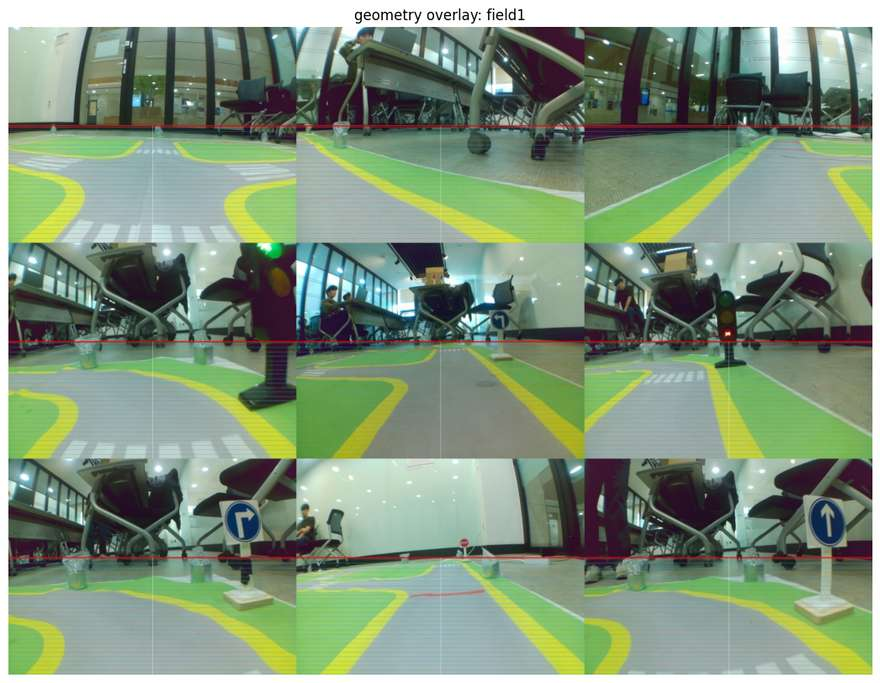

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\geometry_field2.jpg


<Figure size 1400x1000 with 0 Axes>

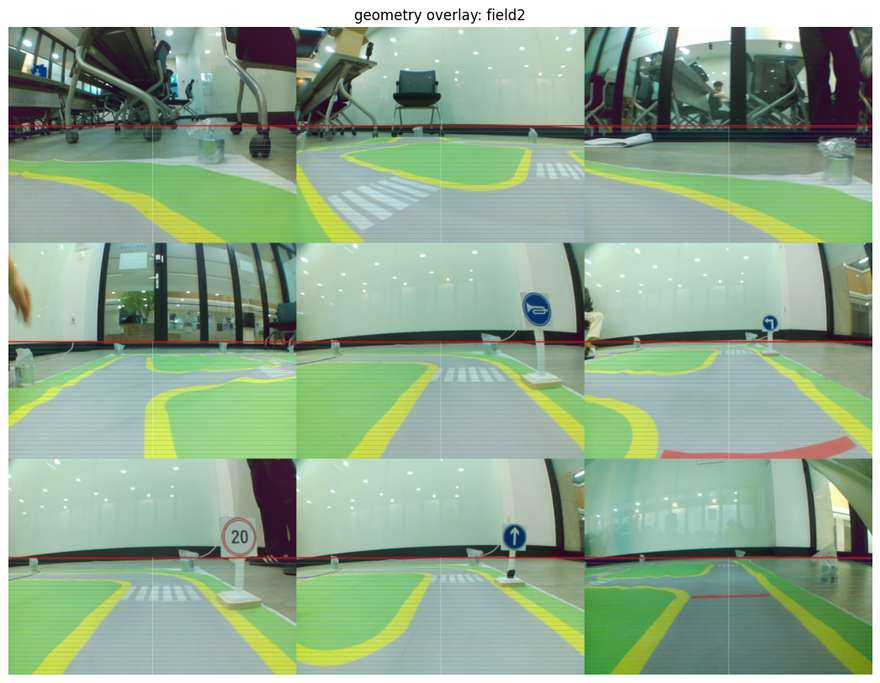

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\geometry_field3.jpg


<Figure size 1400x1000 with 0 Axes>

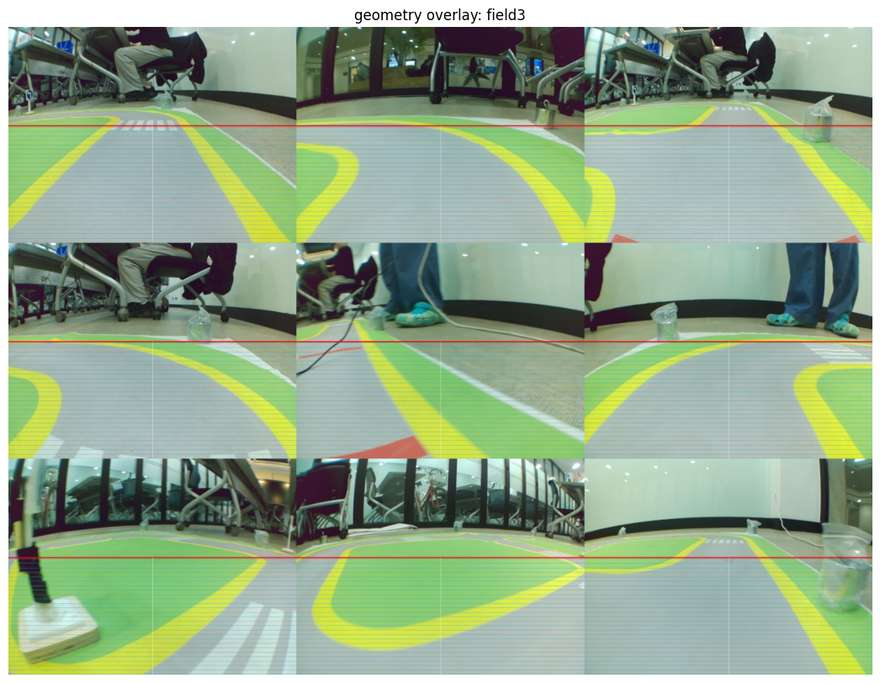

In [12]:
def load_bgr(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise RuntimeError(f'failed to read: {path}')
    return img

def draw_geometry_overlay(bgr: np.ndarray):
    out = bgr.copy()
    h, w = out.shape[:2]
    # crop boundary
    cv2.line(out, (0, CUT_HEIGHT), (w - 1, CUT_HEIGHT), (0, 0, 255), 3)
    # sample_y rows
    for y in SAMPLE_Y:
        if 0 <= y < h:
            cv2.line(out, (0, y), (w - 1, y), (255, 180, 0), 1)
    # center guide
    cv2.line(out, (w // 2, CUT_HEIGHT), (w // 2, h - 1), (255, 255, 255), 1)
    return out

def make_contact_sheet(paths, title, max_cols=3, thumb_w=420):
    if not paths:
        print(f'no paths for {title}')
        return None
    thumbs = []
    labels = []
    for p in paths:
        bgr = load_bgr(Path(p))
        over = draw_geometry_overlay(bgr)
        scale = thumb_w / over.shape[1]
        thumb = cv2.resize(over, (thumb_w, int(over.shape[0] * scale)), interpolation=cv2.INTER_AREA)
        thumbs.append(thumb)
        labels.append(Path(p).name[:42])
    rows = []
    for i in range(0, len(thumbs), max_cols):
        row = thumbs[i:i + max_cols]
        max_h = max(t.shape[0] for t in row)
        padded = []
        for t in row:
            if t.shape[0] < max_h:
                pad = np.zeros((max_h - t.shape[0], t.shape[1], 3), dtype=np.uint8)
                t = np.vstack([t, pad])
            padded.append(t)
        rows.append(np.hstack(padded))
    sheet = np.vstack(rows)
    out_path = REVIEW_ROOT / f'{title}.jpg'
    cv2.imwrite(str(out_path), sheet)
    print('saved:', out_path)
    return out_path

rng = random.Random(12)
selected = []
for group in ['field1', 'field2', 'field3']:
    gdf = df[(df['split'] == 'raw') & (df['group'] == group)]
    paths = gdf['path'].tolist()
    if len(paths) > 0:
        # 시간순 데이터의 한쪽 구간에만 치우치지 않도록 균등 샘플링
        idxs = np.linspace(0, len(paths) - 1, num=min(9, len(paths)), dtype=int)
        selected.extend([(group, paths[i]) for i in idxs])

for group in ['field1', 'field2', 'field3']:
    paths = [p for g, p in selected if g == group]
    out = make_contact_sheet(paths, f'geometry_{group}', max_cols=3)
    if out:
        display(plt.figure(figsize=(14, 10)))
        img = cv2.cvtColor(cv2.imread(str(out)), cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'geometry overlay: {group}')
        plt.show()

## 여기서 멈추고 확인할 것

위 출력 이미지를 보고 다음을 먼저 판단한다.

1. `cut_height=445` 아래에 실제 주행에 필요한 노란 차선이 충분히 들어오는가?
2. `sample_y` 행들이 노란 차선이 보이는 영역을 잘 지나가는가?
3. field1, field2, field3의 카메라 구도 차이가 학습/평가 split을 나눌 때 문제가 될 정도인가?
4. 가로선, 정지선, 교차로 선처럼 `x=f(y)` lane 표현에 맞지 않는 객체가 얼마나 자주 보이는가?

이 4개를 먼저 확인한 뒤에, 다음 셀에서 “노란 픽셀을 어떻게 뽑을지”를 결정한다. 아직 HSV 값은 정하지 않았다.

## GT Lane 정책 결정 목차

아래부터는 비어 있는 실험 목차로 둔다. 각 주제마다 코드셀을 하나씩 추가하고, 결과를 본 뒤 값을 확정한다.

가장 중요한 구분은 이것이다.

- **공식 구현이 이미 정한 것**: CLRKDNet/CULane 학습 형식, crop, resize, `.lines.txt`, mask 파일, `get_lanes()` 후처리 순서.
- **우리가 정해야 하는 것**: raw 이미지에서 노란 차선을 어떻게 pseudo-GT lane 좌표로 만들 것인가.

공식은 사람이 만든 CULane 라벨을 읽을 뿐, HSV 마스크를 만들지 않는다. 그래서 여기서 정하는 정책은 공식 모델을 바꾸는 게 아니라, **우리 raw 데이터를 공식 CULane 형식으로 변환하는 전처리 정책**이다.

## 1. 고정할 공식 계약: 좌표계, ROI, 입력 분포

먼저 공식에 맞춰 거의 고정해야 하는 값이다.

| 항목 | 공식 CULane | 우리 맵에서 쓸 값 | 결정 상태 |
|---|---:|---:|---|
| 원본 이미지 크기 | `1640x590` | `1296x972` | 고정 |
| 모델 입력 크기 | `800x320` | `800x320` | 고정 |
| 상단 crop | `cut_height=270` | `cut_height=445` | 고정 후보 |
| 학습 ROI | `y >= cut_height` 전체 | `y >= 445` 전체 | 고정 후보 |
| lane 표현 | `x=f(y)` | 동일 | 고정 |
| 학습 입력 | BGR float32 `/255` | 동일해야 함 | 반드시 검증 |
| 출력 후처리 | confidence → LineIoU NMS → top-k | 동일하게 재현 | 반드시 검증 |

여기서 가장 위험한 실수는 학습과 추론의 입력 분포가 달라지는 것이다. 이전 정리에서 지적된 것처럼, 학습 dataloader는 이미 `/255`를 수행한다. 따라서 export, ONNX, Pi runtime도 같은 BGR `[0,1]` 입력을 써야 한다.

## 2. 데이터 사용 정책: train, val, holdout을 어떻게 나눌 것인가

정해야 할 질문이다.

- field1, field2, field3 중 무엇을 train에 넣을 것인가?
- field3은 최근 수집 데이터라 test/val로 남길 것인가, 일부 train에 섞을 것인가?
- background 순회 데이터는 학습에 넣지 않고 holdout replay 평가로 남길 것인가?
- split을 파일명 정렬로 자르면 scene이 쏠리지 않는가?

공식 CULane은 이미 train/val/test split이 정해져 있다. 우리는 직접 만든 데이터이므로 split 정책도 모델 성능 해석에 큰 영향을 준다. 특히 이전 실험에서는 split이 정렬 순서에 의존해 scene 쏠림 가능성이 있었다. 이번에는 가능한 한 scene/field 분포를 의식해서 나눠야 한다.

## 3. 노란선 마스크 추출 정책: 무엇을 lane 후보 픽셀로 볼 것인가

여기부터는 공식에 없는 우리 전처리 정책이다.

정해야 할 값과 관찰 항목은 다음과 같다.

| 주제 | 정해야 할 것 | 결과에서 봐야 할 것 |
|---|---|---|
| ROI | `y >= cut_height`만 쓸지, 추가 하단/좌우 제한을 둘지 | 표지판/배경 노이즈가 들어오는지 |
| 색상 공간 | HSV를 유지할지, 다른 색상 공간도 볼지 | 조명 변화에도 노란선이 분리되는지 |
| HSV 범위 | H/S/V 하한과 상한 | 노란선 누락 vs 노이즈 포함 균형 |
| morphology | kernel 크기, open/close 여부 | 끊긴 선이 이어지는지, 다른 물체와 붙는지 |
| 밝기/그림자 | V, S 조건을 얼마나 완화할지 | 어두운 구간과 밝은 구간 모두 잡히는지 |

이 단계의 출력은 아직 GT가 아니다. 단지 “노란선 후보 마스크”다.

### 3-1. HSV 체계에서 노란색은 어디인가

먼저 실제 맵 이미지와 무관하게, OpenCV HSV 체계에서 노란색이 어느 H 값 근처에 놓이는지 확인한다.

주의할 점은 OpenCV의 Hue 범위가 일반적인 0~360도가 아니라 `0~179`라는 점이다. 그래서 일반적으로 노란색은 대략 `H=20~40` 근처에 놓인다. 다만 실제 이미지에서는 조명, 카메라 white balance, 바닥 반사 때문에 S/V가 크게 흔들릴 수 있으므로, 이 셀은 “기준 감각”을 잡기 위한 것이다.


,name,R,G,B,OpenCV_H,S,V
0,pure_yellow_rgb_255_255_0,255,255,0,30,255,255
1,gold_rgb_255_215_0,255,215,0,25,255,255
2,orange_yellow_rgb_255_180_0,255,180,0,21,255,255
3,dark_yellow_rgb_160_140_0,160,140,0,26,255,160
4,pale_yellow_rgb_255_255_120,255,255,120,30,135,255
5,yellow_green_rgb_200_220_0,200,220,0,33,255,220
6,orange_rgb_255_140_0,255,140,0,16,255,255
7,red_rgb_255_0_0,255,0,0,0,255,255
8,green_rgb_0_180_0,0,180,0,60,255,180
9,gray_rgb_120_120_120,120,120,120,0,0,120


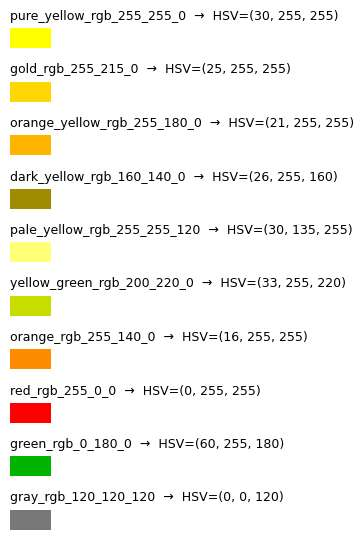

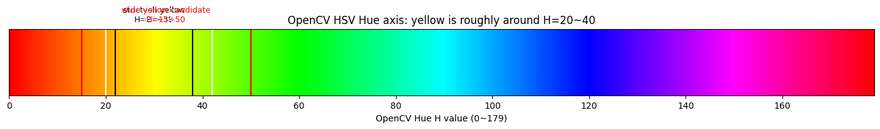

해석: 순수 노란색은 보통 H=30 근처에 놓인다.
하지만 실제 맵 차선은 조명/카메라/반사 때문에 H뿐 아니라 S,V도 흔들리므로, 다음 단계에서 실제 raw ROI 픽셀 분포를 확인해야 한다.


In [13]:
# OpenCV HSV 기준에서 대표 노란색들이 어떤 H/S/V 값을 갖는지 확인한다.
# RGB 색상표를 직접 만들고, cv2.cvtColor로 HSV로 변환한다.

reference_rgb = {
    'pure_yellow_rgb_255_255_0': (255, 255, 0),
    'gold_rgb_255_215_0': (255, 215, 0),
    'orange_yellow_rgb_255_180_0': (255, 180, 0),
    'dark_yellow_rgb_160_140_0': (160, 140, 0),
    'pale_yellow_rgb_255_255_120': (255, 255, 120),
    'yellow_green_rgb_200_220_0': (200, 220, 0),
    'orange_rgb_255_140_0': (255, 140, 0),
    'red_rgb_255_0_0': (255, 0, 0),
    'green_rgb_0_180_0': (0, 180, 0),
    'gray_rgb_120_120_120': (120, 120, 120),
}

rows = []
swatch_h = 60
swatches = []
for name, rgb in reference_rgb.items():
    rgb_arr = np.array([[rgb]], dtype=np.uint8)
    hsv = cv2.cvtColor(rgb_arr, cv2.COLOR_RGB2HSV)[0, 0]
    rows.append({
        'name': name,
        'R': rgb[0], 'G': rgb[1], 'B': rgb[2],
        'OpenCV_H': int(hsv[0]), 'S': int(hsv[1]), 'V': int(hsv[2]),
    })
    swatch = np.full((swatch_h, 120, 3), rgb, dtype=np.uint8)
    swatches.append(swatch)

hsv_ref_df = pd.DataFrame(rows)
display(hsv_ref_df)

# 대표 색상 swatch 표시
fig, axes = plt.subplots(len(swatches), 1, figsize=(10, 0.55 * len(swatches)))
if len(swatches) == 1:
    axes = [axes]
for ax, swatch, row in zip(axes, swatches, rows):
    ax.imshow(swatch)
    ax.set_axis_off()
    ax.set_title(f"{row['name']}  →  HSV=({row['OpenCV_H']}, {row['S']}, {row['V']})", loc='left', fontsize=9)
plt.tight_layout()
plt.show()

# OpenCV Hue 축 전체를 색으로 표시한다. H는 0~179, S/V는 최대값으로 고정한다.
h_values = np.arange(180, dtype=np.uint8)
hsv_strip = np.zeros((40, 180, 3), dtype=np.uint8)
hsv_strip[:, :, 0] = h_values[None, :]
hsv_strip[:, :, 1] = 255
hsv_strip[:, :, 2] = 255
rgb_strip = cv2.cvtColor(hsv_strip, cv2.COLOR_HSV2RGB)

fig, ax = plt.subplots(figsize=(14, 2.2))
ax.imshow(rgb_strip, extent=[0, 179, 0, 1], aspect='auto')
ax.set_yticks([])
ax.set_xlabel('OpenCV Hue H value (0~179)')
ax.set_title('OpenCV HSV Hue axis: yellow is roughly around H=20~40')

# 엄격/중간/넓은 노란색 후보 범위를 시각적으로 표시한다.
ranges = [
    ('strict-ish yellow', 22, 38, 'black'),
    ('medium yellow', 20, 42, 'white'),
    ('wide yellow candidate', 15, 50, 'red'),
]
for label, h0, h1, color in ranges:
    ax.axvline(h0, color=color, linewidth=1.5)
    ax.axvline(h1, color=color, linewidth=1.5)
    ax.text((h0 + h1) / 2, 1.08, f'{label}\nH={h0}~{h1}', ha='center', va='bottom', color=color, fontsize=9)

plt.tight_layout()
plt.show()

print('해석: 순수 노란색은 보통 H=30 근처에 놓인다.')
print('하지만 실제 맵 차선은 조명/카메라/반사 때문에 H뿐 아니라 S,V도 흔들리므로, 다음 단계에서 실제 raw ROI 픽셀 분포를 확인해야 한다.')

### 3-2. 같은 노란 Hue에서 S와 V가 바뀌면 어떻게 보이는가

이제 Hue를 노란색 중심값 근처로 고정하고, Saturation과 Value가 바뀔 때 색이 어떻게 달라지는지 본다.

- `S`는 색의 진함이다. 낮으면 회색/흰색에 가까워져서 노란선인지 애매해진다.
- `V`는 밝기다. 낮으면 어두운 노란색 또는 거의 검은색이 된다.

조명 꺼진 데이터까지 살리려면 `V` 하한을 너무 높이면 안 되고, 흐릿한 노란선까지 살리려면 `S` 하한도 너무 높이면 안 된다. 반대로 너무 낮추면 회색 바닥이나 조명 노이즈가 들어올 수 있다.


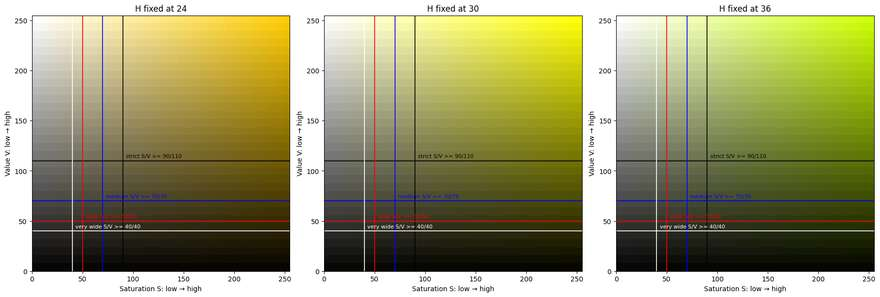

,name,H_min,H_max,S_min,V_min,meaning
0,strict-ish previous,22,38,90,110,밝고 선명한 노란선 중심. 어두운 데이터 누락 위험.
1,medium candidate,20,42,70,70,조명 변화 일부 대응. 노이즈는 아직 제한.
2,wide candidate,18,45,50,50,노란선 recall 우선. component 단계에서 노이즈 제거 필요.
3,very wide candidate,15,50,40,40,어두운/흐린 노란선까지 최대한 포함. 노이즈 위험 큼.


해석: H가 노란 범위여도 S가 낮으면 회색/흰색에 가까워지고, V가 낮으면 거의 검게 보인다.
따라서 노란색 threshold는 H 범위만으로 정하지 않고 S_min, V_min을 같이 정해야 한다.
우리 맵은 색 종류가 단순하므로 wide candidate에서 출발하고, 실제 raw ROI overlay로 노이즈 수준을 확인하는 전략이 합리적이다.


In [14]:
# Hue를 노란색 중심 근처로 고정한 뒤 S/V 평면을 시각화한다.
# OpenCV HSV: H=0~179, S=0~255, V=0~255

YELLOW_H_VALUES = [24, 30, 36]
S_VALUES = np.arange(0, 256, 8, dtype=np.uint8)
V_VALUES = np.arange(255, -1, -8, dtype=np.uint8)  # 위쪽이 밝게 보이도록 역순

fig, axes = plt.subplots(1, len(YELLOW_H_VALUES), figsize=(18, 6), constrained_layout=True)
if len(YELLOW_H_VALUES) == 1:
    axes = [axes]

for ax, h in zip(axes, YELLOW_H_VALUES):
    hsv_grid = np.zeros((len(V_VALUES), len(S_VALUES), 3), dtype=np.uint8)
    hsv_grid[:, :, 0] = h
    hsv_grid[:, :, 1] = S_VALUES[None, :]
    hsv_grid[:, :, 2] = V_VALUES[:, None]
    rgb_grid = cv2.cvtColor(hsv_grid, cv2.COLOR_HSV2RGB)

    ax.imshow(rgb_grid, extent=[0, 255, 0, 255], aspect='auto')
    ax.set_title(f'H fixed at {h}')
    ax.set_xlabel('Saturation S: low → high')
    ax.set_ylabel('Value V: low → high')

    # 후보 S/V 하한선 예시. 이 선의 오른쪽 위가 threshold 통과 영역이다.
    candidate_lines = [
        ('strict S/V >= 90/110', 90, 110, 'black'),
        ('medium S/V >= 70/70', 70, 70, 'blue'),
        ('wide S/V >= 50/50', 50, 50, 'red'),
        ('very wide S/V >= 40/40', 40, 40, 'white'),
    ]
    for label, s_min, v_min, color in candidate_lines:
        ax.axvline(s_min, color=color, linewidth=1.2)
        ax.axhline(v_min, color=color, linewidth=1.2)
        ax.text(s_min + 3, v_min + 3, label, color=color, fontsize=8,
                bbox=dict(facecolor='none', edgecolor='none', alpha=0.0))

plt.show()

# 몇 가지 HSV threshold 후보를 표로 정리한다.
threshold_candidates = pd.DataFrame([
    {
        'name': 'strict-ish previous',
        'H_min': 22, 'H_max': 38,
        'S_min': 90, 'V_min': 110,
        'meaning': '밝고 선명한 노란선 중심. 어두운 데이터 누락 위험.'
    },
    {
        'name': 'medium candidate',
        'H_min': 20, 'H_max': 42,
        'S_min': 70, 'V_min': 70,
        'meaning': '조명 변화 일부 대응. 노이즈는 아직 제한.'
    },
    {
        'name': 'wide candidate',
        'H_min': 18, 'H_max': 45,
        'S_min': 50, 'V_min': 50,
        'meaning': '노란선 recall 우선. component 단계에서 노이즈 제거 필요.'
    },
    {
        'name': 'very wide candidate',
        'H_min': 15, 'H_max': 50,
        'S_min': 40, 'V_min': 40,
        'meaning': '어두운/흐린 노란선까지 최대한 포함. 노이즈 위험 큼.'
    },
])
display(threshold_candidates)

print('해석: H가 노란 범위여도 S가 낮으면 회색/흰색에 가까워지고, V가 낮으면 거의 검게 보인다.')
print('따라서 노란색 threshold는 H 범위만으로 정하지 않고 S_min, V_min을 같이 정해야 한다.')
print('우리 맵은 색 종류가 단순하므로 wide candidate에서 출발하고, 실제 raw ROI overlay로 노이즈 수준을 확인하는 전략이 합리적이다.')

### 3-3. 노란색 HSV 후보 범위 기록

앞의 두 셀을 기준으로, 실제 raw 이미지에 적용해볼 HSV 후보를 명시해둔다.

아직 최종 정책이 아니다. 여기서는 “노란색으로 볼 수 있는 범위가 어느 정도인가”를 후보로 세워두고, 다음 셀에서 실제 `y >= cut_height` ROI 픽셀 분포와 overlay를 보며 좁히거나 유지한다.

현재 전략은 노란선을 놓치지 않는 쪽을 우선한다. 즉 HSV 단계에서는 약간 넓게 잡고, 이후 component/polyline 단계에서 lane답지 않은 노이즈를 제거하는 방향이다.


In [15]:
# OpenCV HSV 기준 후보 범위.
# lower = [H_min, S_min, V_min], upper = [H_max, 255, 255]
# H: 0~179, S/V: 0~255

HSV_CANDIDATES = {
    'very_wide_yellow': {
        'lower': np.array([15, 40, 40], dtype=np.uint8),
        'upper': np.array([50, 255, 255], dtype=np.uint8),
        'role': '가장 러프한 노란색 후보. 조명 꺼진 데이터까지 최대한 살리지만 노이즈 위험이 큼.',
    },
    'wide_yellow': {
        'lower': np.array([18, 50, 50], dtype=np.uint8),
        'upper': np.array([45, 255, 255], dtype=np.uint8),
        'role': '실제 마스크 출발 후보. 노란선 recall을 우선하면서도 너무 넓지는 않음.',
    },
    'medium_yellow': {
        'lower': np.array([20, 70, 70], dtype=np.uint8),
        'upper': np.array([42, 255, 255], dtype=np.uint8),
        'role': '조금 더 안정적인 후보. 밝은/보통 조명에서 노이즈를 줄이는 쪽.',
    },
    'strict_yellow': {
        'lower': np.array([22, 90, 110], dtype=np.uint8),
        'upper': np.array([38, 255, 255], dtype=np.uint8),
        'role': '밝고 선명한 노란선 중심. 어두운 데이터 누락 위험이 있음.',
    },
}

candidate_rows = []
for name, cfg in HSV_CANDIDATES.items():
    lower = cfg['lower'].tolist()
    upper = cfg['upper'].tolist()
    candidate_rows.append({
        'name': name,
        'H_min': lower[0],
        'H_max': upper[0],
        'S_min': lower[1],
        'V_min': lower[2],
        'lower': lower,
        'upper': upper,
        'role': cfg['role'],
    })

hsv_candidate_df = pd.DataFrame(candidate_rows)
display(hsv_candidate_df)

candidate_json_path = REVIEW_ROOT / 'hsv_candidate_ranges.json'
serializable = {
    name: {
        'lower': cfg['lower'].tolist(),
        'upper': cfg['upper'].tolist(),
        'role': cfg['role'],
    }
    for name, cfg in HSV_CANDIDATES.items()
}
candidate_json_path.write_text(json.dumps(serializable, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', candidate_json_path)

print('다음 단계: raw 이미지의 ROI(y >= cut_height)에서 후보 픽셀 분포를 보고, 이 후보들이 실제 노란 차선을 얼마나 잘 포함하는지 확인한다.')

,name,H_min,H_max,S_min,V_min,lower,upper,role
0,very_wide_yellow,15,50,40,40,"[15, 40, 40]","[50, 255, 255]",가장 러프한 노란색 후보. 조명 꺼진 데이터까지 최대한 살리지만 노이즈 위험이 큼.
1,wide_yellow,18,45,50,50,"[18, 50, 50]","[45, 255, 255]",실제 마스크 출발 후보. 노란선 recall을 우선하면서도 너무 넓지는 않음.
2,medium_yellow,20,42,70,70,"[20, 70, 70]","[42, 255, 255]",조금 더 안정적인 후보. 밝은/보통 조명에서 노이즈를 줄이는 쪽.
3,strict_yellow,22,38,90,110,"[22, 90, 110]","[38, 255, 255]",밝고 선명한 노란선 중심. 어두운 데이터 누락 위험이 있음.


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\hsv_candidate_ranges.json
다음 단계: raw 이미지의 ROI(y >= cut_height)에서 후보 픽셀 분포를 보고, 이 후보들이 실제 노란 차선을 얼마나 잘 포함하는지 확인한다.


### 3-4. 실제 raw ROI에서 HSV 분포 확인

이제 실제 field1/2/3 raw 이미지의 `y >= cut_height` 영역만 대상으로 HSV 분포를 본다.

전체 raw 픽셀을 모두 모으면 수십억 픽셀이 되므로, 여기서는 **모든 이미지에서 일정 수의 픽셀을 샘플링**한다. 즉 이미지 분포는 전체를 훑되, 픽셀은 통계적으로 샘플링하는 방식이다.

확인할 것은 세 가지다.

1. ROI 전체 픽셀의 H/S/V 분포
2. 아주 넓은 노란 후보(`very_wide_yellow`) 안에 들어온 픽셀의 H/S/V 분포
3. 각 HSV 후보가 field별로 얼마나 많은 픽셀을 잡는지

이 결과로 바로 최종 threshold를 확정하지는 않는다. 다음 overlay 셀에서 실제 이미지 위에 마스크를 얹어본 뒤 결정한다.


raw image count: 11105
pixels per image sample: 2500
processed 1000/11105
processed 2000/11105
processed 3000/11105
processed 4000/11105
processed 5000/11105
processed 6000/11105
processed 7000/11105
processed 8000/11105
processed 9000/11105
processed 10000/11105
processed 11000/11105
processed 11105/11105
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\raw_roi_hsv_image_stats.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\raw_roi_hsv_all_pixel_samples.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\raw_roi_hsv_very_wide_yellow_samples.csv
all hsv samples: 360000
very wide yellow hsv samples: 360000


very_wide_yellow_sample_ratio                 wide_yellow_sample_ratio  \
                                mean  median     max                     mean   
group                                                                           
field1                        0.3612  0.3960  0.6676                   0.2106   
field2                        0.2989  0.2932  0.6512                   0.1604   
field3                        0.3435  0.3432  0.8268                   0.1801   

                       medium_yellow_sample_ratio                  \
        median     max                       mean  median     max   
group                                                               
field1  0.2172  0.3836                     0.1349  0.1368  0.2364   
field2  0.1612  0.3608                     0.1131  0.1172  0.2320   
field3  0.1762  0.5784                     0.1352  0.1376  0.2836   

       strict_yellow_sample_ratio                 roi_v_median                \
                             mean  median     max         mean median    max   
group                                                                          
field1                     0.1069  0.1112  0.2004     164.8509  172.0  207.0   
field2                     0.0965  0.1012  0.1852     175.9114  181.5  253.0   
field3                     0.1278  0.1304  0.2684     190.9292  190.0  211.0   

       roi_s_median                
               mean median    max  
group                              
field1      55.6817   54.0  159.0  
field2      53.6299   52.0  130.0  
field3      33.7939   23.0  122.0

,v_p05,v_p25,v_p50,v_p75,v_p95
group,,,,,
field1,87.0,162.00,172.0,183.00,194.0
field2,146.0,163.38,181.5,186.12,197.0
field3,181.0,187.12,190.0,194.00,202.0


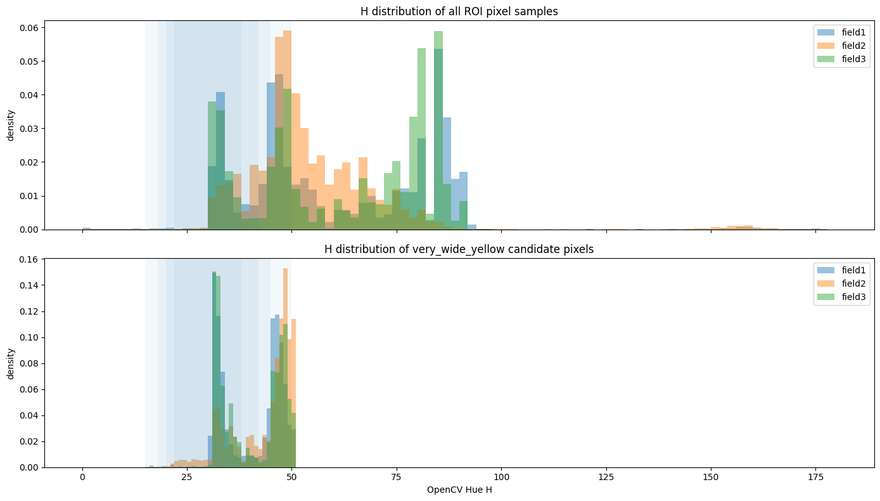

S                                  V                            
        0.05   0.10   0.25   0.50   0.75   0.05   0.10   0.25   0.50   0.75
group                                                                      
field1  68.0  104.0  119.0  139.0  173.0  147.0  184.0  193.0  207.0  217.0
field2  44.0   49.0   63.0  116.0  131.0   89.0  109.0  145.0  188.0  194.0
field3  45.0   49.0  108.0  121.0  166.0  161.0  166.0  197.0  206.0  218.0

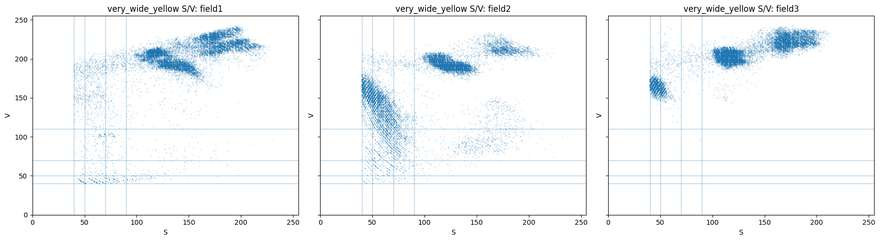

Interpretation points:
- If candidate ratio is too low, yellow lane pixels may be missed.
- If candidate ratio is too high, floor/noise pixels may be included.
- Check whether H is concentrated around 20~40 and how low S/V gets in darker frames.
- Next cell will validate these candidates with image overlays.


In [17]:
# 실제 raw 이미지 ROI(y >= CUT_HEIGHT)의 HSV 분포를 샘플링한다.
# 모든 이미지를 훑되, 각 이미지에서 일정 수의 픽셀만 뽑아 분포를 본다.

RNG = np.random.default_rng(1202)
PIXELS_PER_IMAGE = 2500
MAX_YELLOW_SAMPLES_PER_GROUP = 120_000
MAX_ALL_SAMPLES_PER_GROUP = 120_000

raw_df = df[df['split'] == 'raw'].copy().reset_index(drop=True)
print('raw image count:', len(raw_df))
print('pixels per image sample:', PIXELS_PER_IMAGE)

image_stats = []
all_pixel_samples = []
yellow_pixel_samples = []
all_counts_by_group = Counter()
yellow_counts_by_group = Counter()

for row_idx, row in raw_df.iterrows():
    path = Path(row['path'])
    group = row['group']
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        continue
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    flat = hsv.reshape(-1, 3)

    n = min(PIXELS_PER_IMAGE, len(flat))
    idx = RNG.choice(len(flat), size=n, replace=False)
    sampled = flat[idx]

    stat = {
        'group': group,
        'rel': row['rel'],
        'path': row['path'],
        'roi_v_mean': float(sampled[:, 2].mean()),
        'roi_v_median': float(np.median(sampled[:, 2])),
        'roi_s_mean': float(sampled[:, 1].mean()),
        'roi_s_median': float(np.median(sampled[:, 1])),
    }

    # 후보 threshold별 픽셀 비율. 여기서는 sampled pixel 기준이다.
    for name, cfg in HSV_CANDIDATES.items():
        lo = cfg['lower']
        hi = cfg['upper']
        mask = (
            (sampled[:, 0] >= lo[0]) & (sampled[:, 0] <= hi[0]) &
            (sampled[:, 1] >= lo[1]) & (sampled[:, 1] <= hi[1]) &
            (sampled[:, 2] >= lo[2]) & (sampled[:, 2] <= hi[2])
        )
        stat[f'{name}_sample_ratio'] = float(mask.mean())

    image_stats.append(stat)

    # 전체 ROI HSV 분포 샘플 저장. group별 상한을 둔다.
    remaining_all = MAX_ALL_SAMPLES_PER_GROUP - all_counts_by_group[group]
    if remaining_all > 0:
        take_n = min(remaining_all, len(sampled))
        take = sampled[:take_n]
        all_pixel_samples.append(pd.DataFrame({
            'group': group,
            'H': take[:, 0].astype(int),
            'S': take[:, 1].astype(int),
            'V': take[:, 2].astype(int),
        }))
        all_counts_by_group[group] += take_n

    # 매우 넓은 노란 후보에 들어온 픽셀만 따로 저장.
    broad = HSV_CANDIDATES['very_wide_yellow']
    lo = broad['lower']
    hi = broad['upper']
    yellow_mask = (
        (sampled[:, 0] >= lo[0]) & (sampled[:, 0] <= hi[0]) &
        (sampled[:, 1] >= lo[1]) & (sampled[:, 1] <= hi[1]) &
        (sampled[:, 2] >= lo[2]) & (sampled[:, 2] <= hi[2])
    )
    yellow_sampled = sampled[yellow_mask]
    remaining_yellow = MAX_YELLOW_SAMPLES_PER_GROUP - yellow_counts_by_group[group]
    if remaining_yellow > 0 and len(yellow_sampled) > 0:
        take_n = min(remaining_yellow, len(yellow_sampled))
        take = yellow_sampled[:take_n]
        yellow_pixel_samples.append(pd.DataFrame({
            'group': group,
            'H': take[:, 0].astype(int),
            'S': take[:, 1].astype(int),
            'V': take[:, 2].astype(int),
        }))
        yellow_counts_by_group[group] += take_n

    if (row_idx + 1) % 1000 == 0 or (row_idx + 1) == len(raw_df):
        print(f'processed {row_idx + 1}/{len(raw_df)}')

image_stats_df = pd.DataFrame(image_stats)
all_hsv_df = pd.concat(all_pixel_samples, ignore_index=True) if all_pixel_samples else pd.DataFrame(columns=['group', 'H', 'S', 'V'])
yellow_hsv_df = pd.concat(yellow_pixel_samples, ignore_index=True) if yellow_pixel_samples else pd.DataFrame(columns=['group', 'H', 'S', 'V'])

stats_path = REVIEW_ROOT / 'raw_roi_hsv_image_stats.csv'
all_path = REVIEW_ROOT / 'raw_roi_hsv_all_pixel_samples.csv'
yellow_path = REVIEW_ROOT / 'raw_roi_hsv_very_wide_yellow_samples.csv'
image_stats_df.to_csv(stats_path, index=False, encoding='utf-8-sig')
all_hsv_df.to_csv(all_path, index=False, encoding='utf-8-sig')
yellow_hsv_df.to_csv(yellow_path, index=False, encoding='utf-8-sig')

print('saved:', stats_path)
print('saved:', all_path)
print('saved:', yellow_path)
print('all hsv samples:', len(all_hsv_df))
print('very wide yellow hsv samples:', len(yellow_hsv_df))

display(image_stats_df.groupby('group')[[
    'very_wide_yellow_sample_ratio',
    'wide_yellow_sample_ratio',
    'medium_yellow_sample_ratio',
    'strict_yellow_sample_ratio',
    'roi_v_median',
    'roi_s_median',
]].agg(['mean', 'median', 'max']).round(4))

# 밝기 분위수로 어두운/보통/밝은 프레임 후보를 확인한다.
brightness_summary = image_stats_df.groupby('group')['roi_v_median'].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).unstack()
brightness_summary.columns = ['v_p05', 'v_p25', 'v_p50', 'v_p75', 'v_p95']
display(brightness_summary.round(2))

# H 분포: 전체 ROI 샘플과 very_wide_yellow 후보 샘플 비교.
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for group in sorted(all_hsv_df['group'].unique()):
    subset = all_hsv_df[all_hsv_df['group'] == group]
    axes[0].hist(subset['H'], bins=np.arange(0, 181, 2), alpha=0.45, label=group, density=True)
axes[0].set_title('H distribution of all ROI pixel samples')
axes[0].set_ylabel('density')
axes[0].legend()

for group in sorted(yellow_hsv_df['group'].unique()):
    subset = yellow_hsv_df[yellow_hsv_df['group'] == group]
    axes[1].hist(subset['H'], bins=np.arange(0, 181, 1), alpha=0.45, label=group, density=True)
axes[1].set_title('H distribution of very_wide_yellow candidate pixels')
axes[1].set_xlabel('OpenCV Hue H')
axes[1].set_ylabel('density')
axes[1].legend()

for ax in axes:
    for name, cfg in HSV_CANDIDATES.items():
        lo = cfg['lower'][0]
        hi = cfg['upper'][0]
        ax.axvspan(lo, hi, alpha=0.05)
plt.tight_layout()
plt.show()

# very_wide_yellow 후보 픽셀에서 S/V 분포를 본다.
if len(yellow_hsv_df) > 0:
    sv_quantiles = yellow_hsv_df.groupby('group')[['S', 'V']].quantile([0.05, 0.1, 0.25, 0.5, 0.75]).unstack()
    display(sv_quantiles.round(1))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
    groups = sorted(yellow_hsv_df['group'].unique())[:3]
    for ax, group in zip(axes, groups):
        subset = yellow_hsv_df[yellow_hsv_df['group'] == group]
        if len(subset) > 20000:
            subset = subset.sample(20000, random_state=1202)
        ax.scatter(subset['S'], subset['V'], s=1, alpha=0.12)
        ax.set_title(f'very_wide_yellow S/V: {group}')
        ax.set_xlabel('S')
        ax.set_ylabel('V')
        for name, cfg in HSV_CANDIDATES.items():
            s_min = int(cfg['lower'][1])
            v_min = int(cfg['lower'][2])
            ax.axvline(s_min, linewidth=1, alpha=0.35)
            ax.axhline(v_min, linewidth=1, alpha=0.35)
        ax.set_xlim(0, 255)
        ax.set_ylim(0, 255)
    plt.tight_layout()
    plt.show()

print('Interpretation points:')
print('- If candidate ratio is too low, yellow lane pixels may be missed.')
print('- If candidate ratio is too high, floor/noise pixels may be included.')
print('- Check whether H is concentrated around 20~40 and how low S/V gets in darker frames.')
print('- Next cell will validate these candidates with image overlays.')

### 3-5. HSV 후보별 실제 ROI mask overlay 확인: local fitting용 precision 후보까지 비교

이제 숫자 분포가 아니라 실제 이미지를 본다.

처음에는 `strict / medium / wide / very_wide` 정도만 봤지만, 4번 local fitting 실험에서 중요한 사실이 드러났다. component 기반으로 직선을 연장하는 방식에서는 작은 배경 노이즈도 긴 라벨선으로 이어질 수 있으므로, HSV 단계에서 precision을 더 높이는 후보가 필요하다.

따라서 이 셀은 기존 후보에 더해 `very_strict_local_yellow` 주변의 여러 후보를 같이 본다.

확인할 질문은 다음이다.

1. `medium_yellow`는 local fitting용으로 너무 많은 배경 component를 남기는가?
2. `very_strict_local_yellow = H[24,36], S>=120, V>=110`는 실제 가까운 노란선을 충분히 살리는가?
3. `V` 하한을 90~100으로 낮추면 어두운 데이터가 살아나면서 노이즈는 여전히 억제되는가?
4. `H` 범위를 `[22,38]`로 조금 넓힌 strict 후보가 `[24,36]`보다 안정적인가?
5. field1/2/3와 문제 샘플에서 같은 후보가 일관되게 동작하는가?

아직 morphology나 component filter는 적용하지 않는다. 이 셀은 순수 HSV threshold만 비교한다. 다만 이번 비교는 “노란선 recall”만이 아니라, **local fitting에서 잘못된 component를 줄일 수 있는 precision**을 같이 본다.


,candidate,H_min,H_max,S_min,V_min,role
0,medium_yellow,20,42,70,70,조금 더 안정적인 후보. 밝은/보통 조명에서 노이즈를 줄이는 쪽.
1,medium_high_sv,20,42,100,90,"medium hue 유지, S/V만 올려 배경 component를 줄이는 후보."
2,hue_strict_s80_v80,22,38,80,80,Hue를 strict하게 줄이고 S/V는 비교적 완화한 후보.
3,strict_yellow,22,38,90,110,밝고 선명한 노란선 중심. 어두운 데이터 누락 위험이 있음.
4,strict_s100_v100,22,38,100,100,strict hue + 균형형 S/V. very_strict보다 조금 넓음.
5,strict_s110_v90,22,38,110,90,어두운 노란선을 살리기 위해 V는 낮추고 S를 올린 후보.
6,very_strict_low_v,24,36,120,90,"very_strict hue/S 유지, V만 낮춰 어두운 데이터 보완."
7,very_strict_local_yellow,24,36,120,110,4번 local fitting에서 배경 노이즈를 크게 줄인 후보.
8,ultra_strict_yellow,25,35,140,120,precision 최우선 후보. 실제 lane 누락 위험 확인용.


selected overlay samples: 22


,group,sample_tag,rel,roi_v_median,roi_s_median
0,field1,dark_p10,field1\signs\left\20260430_172423_signs_left_s...,95.0,88.0
1,field1,normal_p50,field1\signs\straight\20260430_174335_signs_st...,172.0,47.0
2,field1,bright_p90,field1\lane\intersection\20260430_160157_lane_...,190.0,47.0
3,field2,dark_p10,field2\06_sign_capture_drive\left\20260501_121...,149.0,66.5
4,field2,normal_p50,field2\06_sign_capture_drive\left\20260501_121...,181.5,46.0
5,field2,bright_p90,field2\01_lane_drive_capture\intersection_left...,194.0,70.0
6,field3,dark_p10,field3\field_drive\000018_mixed_drive_auto_202...,184.0,24.0
7,field3,normal_p50,field3\field_drive\001067_mixed_drive_auto_202...,190.0,22.0
8,field3,bright_p90,field3\field_drive\000054_mixed_drive_auto_202...,199.0,19.0
9,field1,target_20260430_174336_0,field1\signs\straight\20260430_174336_signs_st...,NaN,NaN


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\hsv_candidate_overlays\hsv_candidate_overlay_binary_localfit_field1.jpg


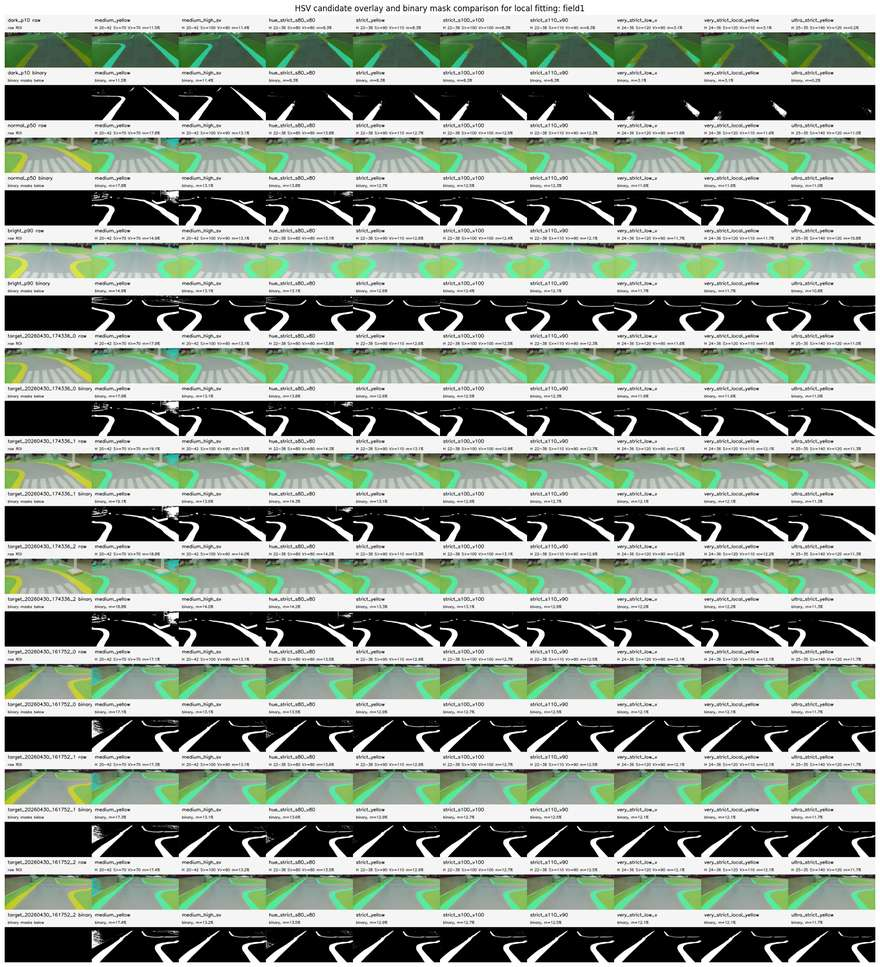

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\hsv_candidate_overlays\hsv_candidate_overlay_binary_localfit_field2.jpg


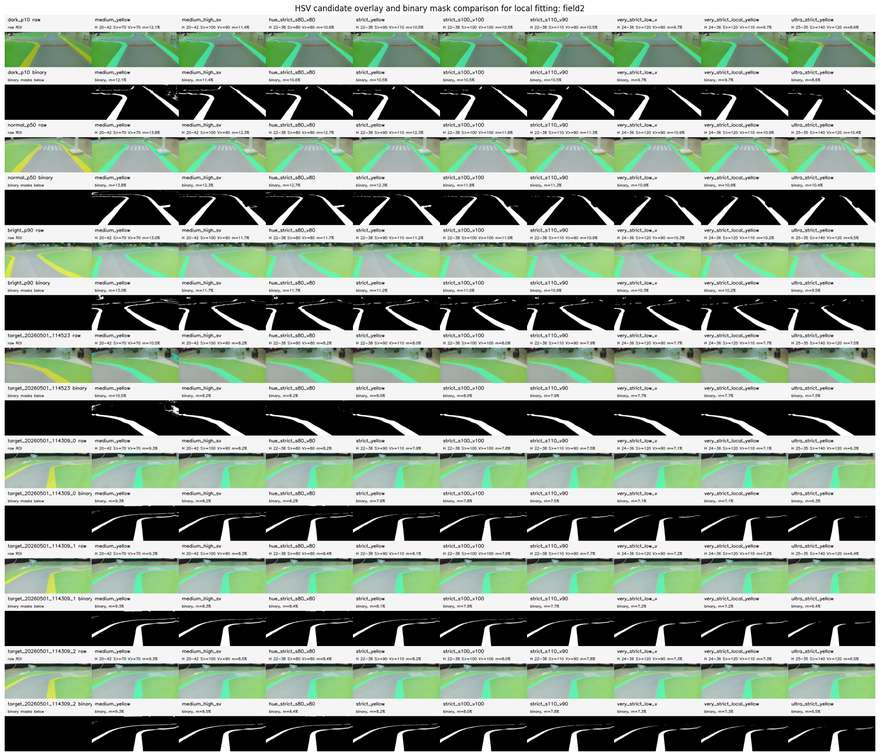

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\hsv_candidate_overlays\hsv_candidate_overlay_binary_localfit_field3.jpg


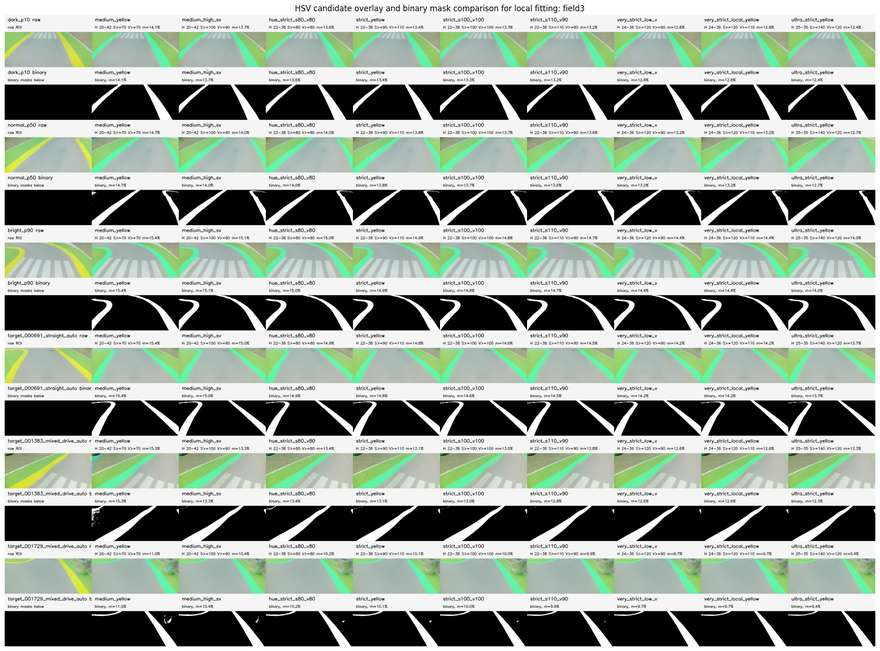

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\hsv_candidate_overlays\hsv_candidate_overlay_binary_localfit_coverage.csv


candidate                              hue_strict_s80_v80  medium_high_sv  \
group  sample_tag                                                           
field1 bright_p90                                  0.1311          0.1312   
       dark_p10                                    0.0832          0.1144   
       normal_p50                                  0.1381          0.1313   
       target_20260430_161752_0                    0.1353          0.1313   
       target_20260430_161752_1                    0.1357          0.1315   
       target_20260430_161752_2                    0.1353          0.1315   
       target_20260430_174336_0                    0.1377          0.1309   
       target_20260430_174336_1                    0.1434          0.1364   
       target_20260430_174336_2                    0.1425          0.1399   
field2 bright_p90                                  0.1167          0.1171   
       dark_p10                                    0.1056          0.1145   
       normal_p50                                  0.1272          0.1233   
       target_20260501_114309_0                    0.0821          0.0824   
       target_20260501_114309_1                    0.0839          0.0833   
       target_20260501_114309_2                    0.0844          0.0848   
       target_20260501_114523                      0.0819          0.0821   
field3 bright_p90                                  0.1496          0.1509   
       dark_p10                                    0.1359          0.1368   
       normal_p50                                  0.1396          0.1403   
       target_000691_straight_auto                 0.1486          0.1502   
       target_001383_mixed_drive_auto              0.1336          0.1328   
       target_001729_mixed_drive_auto              0.1023          0.1042   

candidate                              medium_yellow  strict_s100_v100  \
group  sample_tag                                                        
field1 bright_p90                             0.1491            0.1237   
       dark_p10                               0.1146            0.0832   
       normal_p50                             0.1777            0.1255   
       target_20260430_161752_0               0.1707            0.1266   
       target_20260430_161752_1               0.1732            0.1266   
       target_20260430_161752_2               0.1737            0.1266   
       target_20260430_174336_0               0.1791            0.1248   
       target_20260430_174336_1               0.1909            0.1293   
       target_20260430_174336_2               0.1881            0.1310   
field2 bright_p90                             0.1301            0.1103   
       dark_p10                               0.1214            0.1053   
       normal_p50                             0.1384            0.1178   
       target_20260501_114309_0               0.0933            0.0776   
       target_20260501_114309_1               0.0930            0.0792   
       target_20260501_114309_2               0.0935            0.0805   
       target_20260501_114523                 0.1048            0.0797   
field3 bright_p90                             0.1538            0.1477   
       dark_p10                               0.1413            0.1330   
       normal_p50                             0.1473            0.1371   
       target_000691_straight_auto            0.1536            0.1463   
       target_001383_mixed_drive_auto         0.1529            0.1297   
       target_001729_mixed_drive_auto         0.1098            0.1005   

candidate                              strict_s110_v90  strict_yellow  \
group  sample_tag                                                       
field1 bright_p90                               0.1214         0.1264   
       dark_p10                                 0.0832         0.0832   
       normal_p50                               0.1231         0.1270   
       ta

,H_min,H_max,S_min,V_min,mean_mask_ratio,median_mask_ratio,min_mask_ratio,max_mask_ratio
candidate,,,,,,,,
medium_yellow,20,42,70,70,0.1432,0.1482,0.0930,0.1909
medium_high_sv,20,42,100,90,0.1219,0.1313,0.0821,0.1509
hue_strict_s80_v80,22,38,80,80,0.1215,0.1344,0.0819,0.1496
strict_yellow,22,38,90,110,0.1172,0.1267,0.0795,0.1486
strict_s100_v100,22,38,100,100,0.1155,0.1252,0.0776,0.1477
strict_s110_v90,22,38,110,90,0.1139,0.1229,0.0754,0.1467
very_strict_low_v,24,36,120,90,0.1072,0.1165,0.0311,0.1439
very_strict_local_yellow,24,36,120,110,0.1072,0.1165,0.0311,0.1439
ultra_strict_yellow,25,35,140,120,0.1000,0.1097,0.0022,0.1398


How to read this cell:
- Cyan overlay shows where the HSV candidate selects pixels on top of the original ROI.
- White binary mask shows only the selected pixels, so noise and shape are easier to inspect.
- For local line fitting, prefer the strictest candidate that still keeps nearby lane components continuous.
- If a candidate removes background components while preserving thick nearby yellow lanes, it is better for section 4 than medium_yellow.


In [47]:
# HSV 후보 threshold를 실제 raw ROI에 적용해 overlay + binary mask contact sheet를 만든다.
# 이 단계는 pure HSV threshold만 확인한다. morphology/component/polyline은 아직 적용하지 않는다.
# local fitting 방식에서는 작은 배경 component도 긴 라벨선으로 연장될 수 있으므로,
# medium~very_strict 사이의 후보를 촘촘하게 비교한다.

# 이전 셀을 재실행하지 않아도 동작하도록 저장된 통계 CSV를 fallback으로 읽는다.
if 'image_stats_df' not in globals() or image_stats_df is None or len(image_stats_df) == 0:
    stats_path = REVIEW_ROOT / 'raw_roi_hsv_image_stats.csv'
    image_stats_df = pd.read_csv(stats_path)

OVERLAY_ROOT = REVIEW_ROOT / 'hsv_candidate_overlays'
OVERLAY_ROOT.mkdir(parents=True, exist_ok=True)

# 기존 HSV_CANDIDATES를 건드리지 않고, 3-5 비교용 후보 dict를 따로 만든다.
# 이름 형식: H범위, S하한, V하한이 드러나게 둔다.
COMPARE_HSV_CANDIDATES = {
    'medium_yellow': HSV_CANDIDATES['medium_yellow'],                 # H20-42 S70 V70
    'medium_high_sv': {                                               # H20-42 S100 V90
        'lower': np.array([20, 100, 90], dtype=np.uint8),
        'upper': np.array([42, 255, 255], dtype=np.uint8),
        'role': 'medium hue 유지, S/V만 올려 배경 component를 줄이는 후보.',
    },
    'hue_strict_s80_v80': {                                           # H22-38 S80 V80
        'lower': np.array([22, 80, 80], dtype=np.uint8),
        'upper': np.array([38, 255, 255], dtype=np.uint8),
        'role': 'Hue를 strict하게 줄이고 S/V는 비교적 완화한 후보.',
    },
    'strict_yellow': HSV_CANDIDATES['strict_yellow'],                 # H22-38 S90 V110
    'strict_s100_v100': {                                             # H22-38 S100 V100
        'lower': np.array([22, 100, 100], dtype=np.uint8),
        'upper': np.array([38, 255, 255], dtype=np.uint8),
        'role': 'strict hue + 균형형 S/V. very_strict보다 조금 넓음.',
    },
    'strict_s110_v90': {                                              # H22-38 S110 V90
        'lower': np.array([22, 110, 90], dtype=np.uint8),
        'upper': np.array([38, 255, 255], dtype=np.uint8),
        'role': '어두운 노란선을 살리기 위해 V는 낮추고 S를 올린 후보.',
    },
    'very_strict_low_v': {                                            # H24-36 S120 V90
        'lower': np.array([24, 120, 90], dtype=np.uint8),
        'upper': np.array([36, 255, 255], dtype=np.uint8),
        'role': 'very_strict hue/S 유지, V만 낮춰 어두운 데이터 보완.',
    },
    'very_strict_local_yellow': {                                     # H24-36 S120 V110
        'lower': np.array([24, 120, 110], dtype=np.uint8),
        'upper': np.array([36, 255, 255], dtype=np.uint8),
        'role': '4번 local fitting에서 배경 노이즈를 크게 줄인 후보.',
    },
    'ultra_strict_yellow': {                                          # H25-35 S140 V120
        'lower': np.array([25, 140, 120], dtype=np.uint8),
        'upper': np.array([35, 255, 255], dtype=np.uint8),
        'role': 'precision 최우선 후보. 실제 lane 누락 위험 확인용.',
    },
}

COMPARE_CANDIDATES = list(COMPARE_HSV_CANDIDATES.keys())
OVERLAY_COLOR_BGR = np.array([255, 255, 0], dtype=np.uint8)  # cyan in BGR, easier to distinguish from yellow lane

compare_rows = []
for name, cfg in COMPARE_HSV_CANDIDATES.items():
    lo = cfg['lower'].tolist()
    hi = cfg['upper'].tolist()
    compare_rows.append({
        'candidate': name,
        'H_min': lo[0], 'H_max': hi[0],
        'S_min': lo[1], 'V_min': lo[2],
        'role': cfg.get('role', ''),
    })
compare_df = pd.DataFrame(compare_rows)
display(compare_df)

# field별로 dark / normal / bright 프레임을 고른다.
# roi_v_median 기준으로 10%, 50%, 90%에 가까운 이미지 선택.
selected_rows = []
for group in sorted(image_stats_df['group'].unique()):
    gdf = image_stats_df[image_stats_df['group'] == group].copy()
    if len(gdf) == 0:
        continue
    targets = [
        ('dark_p10', gdf['roi_v_median'].quantile(0.10)),
        ('normal_p50', gdf['roi_v_median'].quantile(0.50)),
        ('bright_p90', gdf['roi_v_median'].quantile(0.90)),
    ]
    used_paths = set()
    for tag, target_v in targets:
        candidates = gdf.assign(_dist=(gdf['roi_v_median'] - target_v).abs()).sort_values('_dist')
        chosen = None
        for _, r in candidates.iterrows():
            if r['path'] not in used_paths:
                chosen = r.copy()
                break
        if chosen is not None:
            chosen['sample_tag'] = tag
            selected_rows.append(chosen)
            used_paths.add(chosen['path'])

# 4번 local fitting에서 중요했던 문제/확인 샘플도 강제로 포함한다.
TARGET_KEYS = [
    '20260430_174336',
    '000691_straight_auto',
    '001383_mixed_drive_auto',
    '20260430_160157',
    '20260430_161752',
    '20260501_114523',
    '20260501_114309',
    '001729_mixed_drive_auto',
]
raw_df_for_targets = df[df['split'] == 'raw'].copy().reset_index(drop=True)
used_rel = set(str(r.get('rel')) for r in selected_rows)
for key in TARGET_KEYS:
    hit = raw_df_for_targets[raw_df_for_targets['rel'].astype(str).str.contains(key, regex=False)]
    if len(hit) == 0:
        continue
    # 같은 key가 여러 장이면 대표 1~3장을 넣는다. 연속 샘플은 너무 많아지지 않게 제한한다.
    for j, (_, r) in enumerate(hit.head(3).iterrows()):
        rel = str(r['rel'])
        if rel in used_rel:
            continue
        rr = r.copy()
        rr['sample_tag'] = f'target_{key}' if len(hit) == 1 else f'target_{key}_{j}'
        selected_rows.append(rr)
        used_rel.add(rel)

selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)
print('selected overlay samples:', len(selected_df))
display(selected_df[['group', 'sample_tag', 'rel'] + [c for c in ['roi_v_median', 'roi_s_median'] if c in selected_df.columns]])


def apply_hsv_mask_to_roi(bgr, candidate_name):
    cfg = COMPARE_HSV_CANDIDATES[candidate_name]
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    ratio = float((mask > 0).mean())
    return mask, ratio


def add_header(panel_bgr, title, subtitle='', thumb_w=240):
    scale = thumb_w / panel_bgr.shape[1]
    thumb_h = int(panel_bgr.shape[0] * scale)
    panel = cv2.resize(panel_bgr, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)

    header_h = 48
    canvas = np.full((thumb_h + header_h, thumb_w, 3), 245, dtype=np.uint8)
    canvas[header_h:, :, :] = panel
    cv2.putText(canvas, title[:40], (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 0, 0), 1, cv2.LINE_AA)
    if subtitle:
        cv2.putText(canvas, subtitle[:52], (8, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (50, 50, 50), 1, cv2.LINE_AA)
    return canvas


def make_raw_panel(bgr, title, thumb_w=240):
    roi = bgr[CUT_HEIGHT:, :, :]
    return add_header(roi, title, 'raw ROI', thumb_w=thumb_w)


def make_overlay_panel(bgr, candidate_name, thumb_w=240):
    roi = bgr[CUT_HEIGHT:, :, :]
    mask, ratio = apply_hsv_mask_to_roi(bgr, candidate_name)
    panel = roi.copy()
    m = mask > 0
    cyan = np.zeros_like(panel)
    cyan[:, :] = OVERLAY_COLOR_BGR
    panel[m] = (panel[m].astype(np.float32) * 0.45 + cyan[m].astype(np.float32) * 0.55).astype(np.uint8)

    lo = COMPARE_HSV_CANDIDATES[candidate_name]['lower'].tolist()
    hi = COMPARE_HSV_CANDIDATES[candidate_name]['upper'].tolist()
    subtitle = f'H {lo[0]}-{hi[0]} S>={lo[1]} V>={lo[2]} m={ratio*100:.1f}%'
    return add_header(panel, f'{candidate_name}', subtitle, thumb_w=thumb_w), mask, ratio


def make_binary_panel(mask, candidate_name, ratio, thumb_w=240):
    binary = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    binary[mask > 0] = (255, 255, 255)
    subtitle = f'binary, m={ratio*100:.1f}%'
    return add_header(binary, f'{candidate_name}', subtitle, thumb_w=thumb_w)


def hstack_same_height(panels):
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        if p.shape[0] < max_h:
            pad = np.full((max_h - p.shape[0], p.shape[1], 3), 245, dtype=np.uint8)
            p = np.vstack([p, pad])
        padded.append(p)
    return np.hstack(padded)


def vstack_same_width(rows):
    max_w = max(r.shape[1] for r in rows)
    padded = []
    for r in rows:
        if r.shape[1] < max_w:
            pad = np.full((r.shape[0], max_w - r.shape[1], 3), 245, dtype=np.uint8)
            r = np.hstack([r, pad])
        padded.append(r)
    return np.vstack(padded)

coverage_rows = []
for group in sorted(selected_df['group'].unique()):
    group_rows = []
    gsel = selected_df[selected_df['group'] == group]
    for _, row in gsel.iterrows():
        path = Path(row['path'])
        bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if bgr is None:
            continue

        # One sample = two rows.
        # Row A: raw + candidate overlays.
        # Row B: blank raw placeholder + candidate binary masks.
        overlay_panels = [make_raw_panel(bgr, f"{row['sample_tag']} raw")]
        binary_panels = [add_header(np.zeros_like(bgr[CUT_HEIGHT:, :, :]), f"{row['sample_tag']} binary", 'binary masks below')]

        for name in COMPARE_CANDIDATES:
            overlay_panel, mask, ratio = make_overlay_panel(bgr, name)
            binary_panel = make_binary_panel(mask, name, ratio)
            coverage_rows.append({
                'group': row['group'],
                'sample_tag': row['sample_tag'],
                'rel': row['rel'],
                'candidate': name,
                'H_min': int(COMPARE_HSV_CANDIDATES[name]['lower'][0]),
                'H_max': int(COMPARE_HSV_CANDIDATES[name]['upper'][0]),
                'S_min': int(COMPARE_HSV_CANDIDATES[name]['lower'][1]),
                'V_min': int(COMPARE_HSV_CANDIDATES[name]['lower'][2]),
                'mask_ratio': ratio,
                'mask_pixels': int((mask > 0).sum()),
                'roi_pixels': int(mask.size),
            })
            overlay_panels.append(overlay_panel)
            binary_panels.append(binary_panel)

        group_rows.append(hstack_same_height(overlay_panels))
        group_rows.append(hstack_same_height(binary_panels))

    if group_rows:
        sheet = vstack_same_width(group_rows)
        out_path = OVERLAY_ROOT / f'hsv_candidate_overlay_binary_localfit_{group}.jpg'
        cv2.imwrite(str(out_path), sheet)
        print('saved:', out_path)

        img_rgb = cv2.cvtColor(sheet, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(24, max(8, len(group_rows) * 1.8)))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f'HSV candidate overlay and binary mask comparison for local fitting: {group}')
        plt.show()

coverage_df = pd.DataFrame(coverage_rows)
coverage_path = OVERLAY_ROOT / 'hsv_candidate_overlay_binary_localfit_coverage.csv'
coverage_df.to_csv(coverage_path, index=False, encoding='utf-8-sig')
print('saved:', coverage_path)

pivot = coverage_df.pivot_table(index=['group', 'sample_tag'], columns='candidate', values='mask_ratio').round(4)
display(pivot)

# 전체 sample 기준 후보별 mask ratio 요약.
summary = coverage_df.groupby('candidate').agg(
    H_min=('H_min', 'first'),
    H_max=('H_max', 'first'),
    S_min=('S_min', 'first'),
    V_min=('V_min', 'first'),
    mean_mask_ratio=('mask_ratio', 'mean'),
    median_mask_ratio=('mask_ratio', 'median'),
    min_mask_ratio=('mask_ratio', 'min'),
    max_mask_ratio=('mask_ratio', 'max'),
).sort_values(['H_min', 'S_min', 'V_min'])
display(summary.round(4))

print('How to read this cell:')
print('- Cyan overlay shows where the HSV candidate selects pixels on top of the original ROI.')
print('- White binary mask shows only the selected pixels, so noise and shape are easier to inspect.')
print('- For local line fitting, prefer the strictest candidate that still keeps nearby lane components continuous.')
print('- If a candidate removes background components while preserving thick nearby yellow lanes, it is better for section 4 than medium_yellow.')


### 3-6. Strict 계열 HSV sweep: 어두운 데이터 방어와 노이즈 억제의 균형 찾기

기존 3-6의 `medium_yellow` 결정은 폐기하고, 여기서는 `strict_yellow` 주변을 더 촘촘하게 흔들어본다.

이번 셀의 목적은 최종 결론을 저장하는 것이 아니라, **어두운 field1 데이터에서도 가까운 lane을 놓치지 않으면서, 일반 데이터에서는 배경 노이즈를 최대한 줄이는 HSV 범위**를 찾는 것이다.

비교 축은 세 가지다.

1. `H range`: 노란색 hue 범위를 얼마나 좁힐지
2. `S_min`: 채도 하한을 얼마나 높여 회색/바닥 노이즈를 줄일지
3. `V_min`: 밝기 하한을 얼마나 낮춰 어두운 노란선을 살릴지

기준점은 기존 `strict_yellow = H[22,38], S>=90, V>=110`이다. 여기서 `S`를 높이면 노이즈는 줄지만 흐릿한 노란선이 빠질 수 있고, `V`를 낮추면 어두운 차선을 살릴 수 있지만 어두운 배경 노이즈가 늘 수 있다.

이 셀은 모든 후보의 mask ratio를 CSV로 저장하고, 후보를 `H range`별 contact sheet로 나눠 저장한다. 눈으로 볼 때는 `field1` 어두운 샘플에서 lane이 끊기는지, 일반 샘플에서 배경 component가 살아나는지를 같이 본다.


strict sweep candidates: 64
strict sweep samples: 21


,group,sample_tag,rel,roi_v_median,roi_s_median
0,field1,field1_dark_0,field1\signs\right\20260430_172645_signs_right...,42.0,88.0
1,field1,field1_dark_1,field1\signs\stop\20260430_173325_signs_stop_s...,53.0,94.0
2,field1,field1_dark_2,field1\signs\stop\20260430_173325_signs_stop_s...,57.0,100.0
3,field1,field1_dark_3,field1\signs\stop\20260430_173322_signs_stop_s...,58.0,102.0
4,field1,target_20260430_174336_0,field1\signs\straight\20260430_174336_signs_st...,NaN,NaN
5,field1,target_20260430_174336_1,field1\signs\straight\20260430_174336_signs_st...,NaN,NaN
6,field3,target_000691_straight_auto,field3\field_drive\000691_straight_auto_202605...,NaN,NaN
7,field3,target_001383_mixed_drive_auto,field3\field_drive\001383_mixed_drive_auto_202...,NaN,NaN
8,field1,target_20260430_160157,field1\lane\intersection\20260430_160157_lane_...,NaN,NaN
9,field1,target_20260430_161752_0,field1\lane\right_curve\20260430_161752_lane_n...,NaN,NaN


saved coverage: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_coverage.csv
saved summary: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_summary.csv
saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_H20_42.jpg
saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_H22_38.jpg


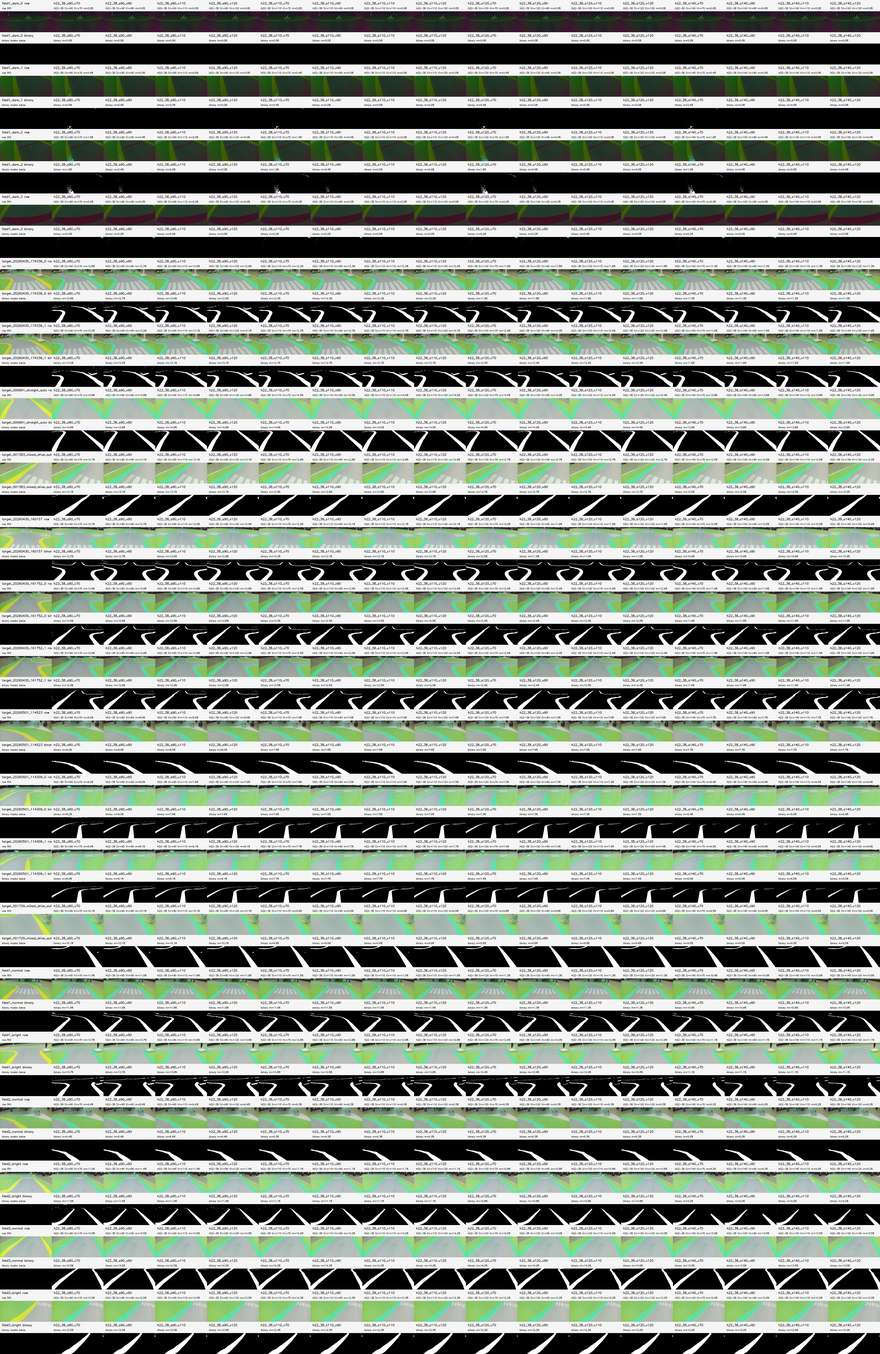

saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_H24_36.jpg


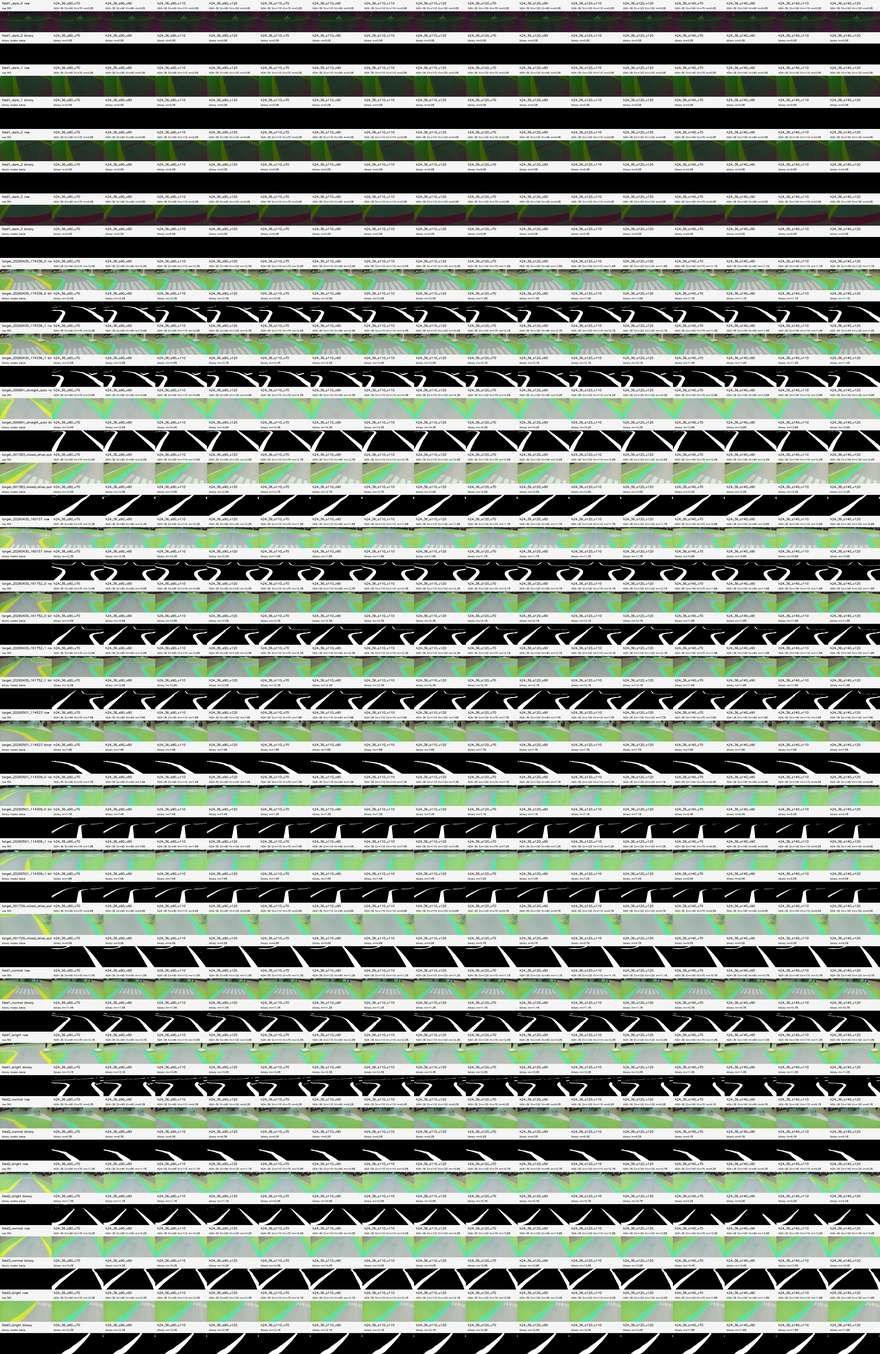

saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_H25_35.jpg
saved pivot: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\strict_hsv_sweep\strict_hsv_sweep_pivot.csv


,mean_mask_ratio,min_mask_ratio,max_mask_ratio
candidate,,,
h22_38_s90_v110,0.0935,0.0,0.1475
h22_38_s110_v90,0.0911,0.0,0.1452
h22_38_s120_v90,0.0895,0.0,0.1439
h24_36_s120_v90,0.0876,0.0,0.1421
h24_36_s120_v110,0.0876,0.0,0.1421
h25_35_s140_v120,0.0827,0.0,0.1371


How to read this sweep:
- Compare H22_38 first: it is the old strict_yellow hue range.
- Lower V_min keeps darker yellow lanes; higher S_min suppresses floor/gray noise.
- Ultra-like h25_35_s140_v120 can look clean but is risky if dark samples lose lane pixels.
- The next step is to run section 4 local fitting with the best-looking candidate, not to save a final decision here.


In [49]:
# 3-6. Strict HSV sweep around strict_yellow.
# 목적: H/S/V를 독립적으로 흔들어보며 어두운 field1 방어력과 일반 데이터 노이즈를 동시에 본다.

from IPython.display import display, Image
from pathlib import Path
import cv2
import numpy as np
import pandas as pd

if 'df' not in globals():
    raise RuntimeError('Run setup cells first so df is available.')
if 'REVIEW_ROOT' not in globals():
    raise RuntimeError('Run previous notebook setup cells first so REVIEW_ROOT is available.')

if 'image_stats_df' not in globals() or image_stats_df is None or len(image_stats_df) == 0:
    stats_path = REVIEW_ROOT / 'raw_roi_hsv_image_stats.csv'
    image_stats_df = pd.read_csv(stats_path)

STRICT_SWEEP_ROOT = REVIEW_ROOT / 'strict_hsv_sweep'
STRICT_SWEEP_ROOT.mkdir(parents=True, exist_ok=True)

# strict_yellow 주변을 촘촘히 흔든다.
# H는 노란색 hue 범위, S는 선명도, V는 밝기 하한이다.
STRICT_H_RANGES = [
    (20, 42),  # strict보다 조금 넓음: 흐릿하거나 색이 밀린 노란선을 더 살림
    (22, 38),  # 기존 strict_yellow hue
    (24, 36),  # very_strict_local_yellow hue
    (25, 35),  # ultra에 가까운 좁은 hue
]
STRICT_S_MINS = [90, 110, 120, 140]
STRICT_V_MINS = [70, 90, 110, 120]

strict_sweep_candidates = {}
for h0, h1 in STRICT_H_RANGES:
    for s_min in STRICT_S_MINS:
        for v_min in STRICT_V_MINS:
            name = f'h{h0}_{h1}_s{s_min}_v{v_min}'
            strict_sweep_candidates[name] = {
                'lower': np.array([h0, s_min, v_min], dtype=np.uint8),
                'upper': np.array([h1, 255, 255], dtype=np.uint8),
                'H_min': h0,
                'H_max': h1,
                'S_min': s_min,
                'V_min': v_min,
            }

print('strict sweep candidates:', len(strict_sweep_candidates))

# ---- sample selection ----
# field1 어두운 샘플은 반드시 포함한다. 그 외에는 field1/2/3에서 대표 샘플을 섞는다.
raw_df_for_targets = df[df['split'] == 'raw'].copy().reset_index(drop=True)
stats = image_stats_df.copy()
stats['roi_v_median'] = stats['roi_v_median'].astype(float)
stats['roi_s_median'] = stats['roi_s_median'].astype(float)

sample_rows = []
used_rel = set()

def add_rows(rows, tag_prefix, limit=None):
    global sample_rows, used_rel
    count = 0
    for _, rr in rows.iterrows():
        rel = str(rr['rel'])
        if rel in used_rel:
            continue
        # stats csv row에 path가 있으므로 notebook df row와 같은 형태로 맞춘다.
        row = rr.copy()
        row['sample_tag'] = f'{tag_prefix}_{count}' if limit is None or limit > 1 else tag_prefix
        sample_rows.append(row)
        used_rel.add(rel)
        count += 1
        if limit is not None and count >= limit:
            break

# 1) field1에서 가장 어두운/채도 낮은 샘플: ultra가 위험한지 확인하는 핵심 샘플.
field1_stats = stats[stats['group'] == 'field1'].copy()
add_rows(field1_stats.sort_values(['roi_v_median', 'roi_s_median']).head(4), 'field1_dark', limit=4)

# 2) 기존에 문제가 되었거나 눈으로 확인하던 target 샘플.
TARGET_KEYS_36 = [
    '20260430_174336',
    '000691_straight_auto',
    '001383_mixed_drive_auto',
    '20260430_160157',
    '20260430_161752',
    '20260501_114523',
    '20260501_114309',
    '001729_mixed_drive_auto',
]
for key in TARGET_KEYS_36:
    hit = raw_df_for_targets[raw_df_for_targets['rel'].astype(str).str.contains(key, regex=False)]
    if len(hit) == 0:
        continue
    for j, (_, r) in enumerate(hit.head(2).iterrows()):
        rel = str(r['rel'])
        if rel in used_rel:
            continue
        rr = r.copy()
        rr['sample_tag'] = f'target_{key}' if len(hit) == 1 else f'target_{key}_{j}'
        sample_rows.append(rr)
        used_rel.add(rel)

# 3) 각 field의 보통/밝은 샘플도 넣는다.
for group in ['field1', 'field2', 'field3']:
    g = stats[stats['group'] == group].copy().sort_values('roi_v_median')
    if len(g) == 0:
        continue
    for q, tag in [(0.50, 'normal'), (0.90, 'bright')]:
        idx = int(round((len(g) - 1) * q))
        add_rows(g.iloc[[idx]], f'{group}_{tag}', limit=1)

sweep_sample_df = pd.DataFrame(sample_rows).reset_index(drop=True)
print('strict sweep samples:', len(sweep_sample_df))
display_cols = [c for c in ['group', 'sample_tag', 'rel', 'roi_v_median', 'roi_s_median'] if c in sweep_sample_df.columns]
display(sweep_sample_df[display_cols])

# ---- visualization helpers ----
OVERLAY_COLOR_BGR_LOCAL = np.array([255, 220, 0], dtype=np.uint8)  # cyan-like BGR for visibility

if 'add_header' not in globals():
    def add_header(panel_bgr, title, subtitle='', thumb_w=220):
        scale = thumb_w / panel_bgr.shape[1]
        thumb_h = int(panel_bgr.shape[0] * scale)
        panel = cv2.resize(panel_bgr, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)
        header_h = 48
        canvas = np.full((thumb_h + header_h, thumb_w, 3), 245, dtype=np.uint8)
        canvas[header_h:, :, :] = panel
        cv2.putText(canvas, title[:42], (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 0, 0), 1, cv2.LINE_AA)
        if subtitle:
            cv2.putText(canvas, subtitle[:56], (8, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (50, 50, 50), 1, cv2.LINE_AA)
        return canvas

if 'hstack_same_height' not in globals():
    def hstack_same_height(panels):
        max_h = max(p.shape[0] for p in panels)
        padded = []
        for panel in panels:
            if panel.shape[0] < max_h:
                pad = np.full((max_h - panel.shape[0], panel.shape[1], 3), 245, dtype=np.uint8)
                panel = np.vstack([panel, pad])
            padded.append(panel)
        return np.hstack(padded)

if 'vstack_same_width' not in globals():
    def vstack_same_width(rows):
        max_w = max(r.shape[1] for r in rows)
        padded = []
        for row in rows:
            if row.shape[1] < max_w:
                pad = np.full((row.shape[0], max_w - row.shape[1], 3), 245, dtype=np.uint8)
                row = np.hstack([row, pad])
            padded.append(row)
        return np.vstack(padded)


def strict_mask_for_candidate(bgr, candidate_name):
    cfg = strict_sweep_candidates[candidate_name]
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, cfg['lower'], cfg['upper'])
    ratio = float((mask > 0).mean())
    return mask, ratio


def raw_panel_for_sweep(bgr, title, thumb_w=220):
    roi = bgr[CUT_HEIGHT:, :, :]
    return add_header(roi, title, 'raw ROI', thumb_w=thumb_w)


def overlay_panel_for_sweep(bgr, candidate_name, thumb_w=220):
    roi = bgr[CUT_HEIGHT:, :, :]
    mask, ratio = strict_mask_for_candidate(bgr, candidate_name)
    panel = roi.copy()
    m = mask > 0
    color = np.zeros_like(panel)
    color[:, :] = OVERLAY_COLOR_BGR_LOCAL
    panel[m] = (panel[m].astype(np.float32) * 0.45 + color[m].astype(np.float32) * 0.55).astype(np.uint8)
    cfg = strict_sweep_candidates[candidate_name]
    subtitle = f'H{cfg["H_min"]}-{cfg["H_max"]} S>={cfg["S_min"]} V>={cfg["V_min"]} m={ratio*100:.1f}%'
    return add_header(panel, candidate_name, subtitle, thumb_w=thumb_w), mask, ratio


def binary_panel_for_sweep(mask, candidate_name, ratio, thumb_w=220):
    binary = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    binary[mask > 0] = (255, 255, 255)
    return add_header(binary, candidate_name, f'binary m={ratio*100:.1f}%', thumb_w=thumb_w)

# ---- compute full sweep coverage table ----
coverage_rows = []
for _, row in sweep_sample_df.iterrows():
    bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
    if bgr is None:
        continue
    for name, cfg in strict_sweep_candidates.items():
        mask, ratio = strict_mask_for_candidate(bgr, name)
        coverage_rows.append({
            'group': row['group'],
            'sample_tag': row['sample_tag'],
            'rel': row['rel'],
            'candidate': name,
            'H_min': cfg['H_min'],
            'H_max': cfg['H_max'],
            'S_min': cfg['S_min'],
            'V_min': cfg['V_min'],
            'mask_ratio': ratio,
            'mask_pixels': int((mask > 0).sum()),
            'roi_pixels': int(mask.size),
        })

strict_coverage_df = pd.DataFrame(coverage_rows)
coverage_path = STRICT_SWEEP_ROOT / 'strict_hsv_sweep_coverage.csv'
strict_coverage_df.to_csv(coverage_path, index=False, encoding='utf-8-sig')
print('saved coverage:', coverage_path)

summary = strict_coverage_df.groupby('candidate').agg(
    H_min=('H_min', 'first'),
    H_max=('H_max', 'first'),
    S_min=('S_min', 'first'),
    V_min=('V_min', 'first'),
    mean_mask_ratio=('mask_ratio', 'mean'),
    min_mask_ratio=('mask_ratio', 'min'),
    max_mask_ratio=('mask_ratio', 'max'),
).sort_values(['H_min', 'H_max', 'S_min', 'V_min'])
summary_path = STRICT_SWEEP_ROOT / 'strict_hsv_sweep_summary.csv'
summary.to_csv(summary_path, encoding='utf-8-sig')
print('saved summary:', summary_path)

# 후보가 너무 많으므로 H 범위별로 contact sheet를 나눠서 본다.
# 각 sheet의 columns = raw + (S_min x V_min 후보).
for h0, h1 in STRICT_H_RANGES:
    candidate_names = [f'h{h0}_{h1}_s{s}_v{v}' for s in STRICT_S_MINS for v in STRICT_V_MINS]
    rows_for_sheet = []
    for _, row in sweep_sample_df.iterrows():
        bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        overlay_panels = [raw_panel_for_sweep(bgr, f'{row["sample_tag"]} raw')]
        binary_panels = [add_header(np.zeros_like(bgr[CUT_HEIGHT:, :, :]), f'{row["sample_tag"]} binary', 'binary masks below', thumb_w=220)]
        for name in candidate_names:
            overlay_panel, mask, ratio = overlay_panel_for_sweep(bgr, name, thumb_w=220)
            binary_panel = binary_panel_for_sweep(mask, name, ratio, thumb_w=220)
            overlay_panels.append(overlay_panel)
            binary_panels.append(binary_panel)
        rows_for_sheet.append(hstack_same_height(overlay_panels))
        rows_for_sheet.append(hstack_same_height(binary_panels))

    sheet = vstack_same_width(rows_for_sheet)
    out_path = STRICT_SWEEP_ROOT / f'strict_hsv_sweep_H{h0}_{h1}.jpg'
    cv2.imwrite(str(out_path), sheet)
    print('saved sheet:', out_path)

    # 노트북에서는 기존 strict 근처인 H22-38, H24-36을 우선 표시한다.
    if (h0, h1) in [(22, 38), (24, 36)]:
        display(Image(filename=str(out_path)))

# 빠른 읽기용 pivot: target/sample별 mask ratio.
pivot = strict_coverage_df.pivot_table(index=['group', 'sample_tag'], columns='candidate', values='mask_ratio').round(4)
pivot_path = STRICT_SWEEP_ROOT / 'strict_hsv_sweep_pivot.csv'
pivot.to_csv(pivot_path, encoding='utf-8-sig')
print('saved pivot:', pivot_path)

# 현재 눈으로 유력해 보이는 후보 몇 개만 요약해서 비교한다.
KEY_CANDIDATES = [
    'h22_38_s90_v110',   # old strict_yellow
    'h22_38_s110_v90',   # current strict_s110_v90
    'h22_38_s120_v90',
    'h24_36_s120_v90',
    'h24_36_s120_v110',  # previous very_strict_local_yellow close neighbor
    'h25_35_s140_v120',  # ultra-like
]
key_summary = strict_coverage_df[strict_coverage_df['candidate'].isin(KEY_CANDIDATES)].groupby('candidate').agg(
    mean_mask_ratio=('mask_ratio', 'mean'),
    min_mask_ratio=('mask_ratio', 'min'),
    max_mask_ratio=('mask_ratio', 'max'),
).loc[[c for c in KEY_CANDIDATES if c in strict_coverage_df['candidate'].values]]
display(key_summary.round(4))

print('How to read this sweep:')
print('- Compare H22_38 first: it is the old strict_yellow hue range.')
print('- Lower V_min keeps darker yellow lanes; higher S_min suppresses floor/gray noise.')
print('- Ultra-like h25_35_s140_v120 can look clean but is risky if dark samples lose lane pixels.')
print('- The next step is to run section 4 local fitting with the best-looking candidate, not to save a final decision here.')


### 3-7. 유력 HSV 후보 단독 검증: `H20-42, S>=140, V>=70`

3-6 sweep에서 가장 좋아 보인 후보는 `h20_42_s140_v70`이다.

```python
lower = [20, 140, 70]
upper = [42, 255, 255]
```

이 후보의 의도는 분명하다.

- `H20-42`: 노란색 hue 범위는 넓게 열어서 어두운 조명, 카메라 노출, 색 틀어짐을 방어한다.
- `S>=140`: 대신 채도는 강하게 요구해서 회색 바닥, 흰 횡단보도, 흐릿한 배경 노이즈를 줄인다.
- `V>=70`: 밝기 하한은 낮춰서 field1의 어두운 노란선도 살린다.

이번 셀은 최종 저장이 아니라 **후보 단독 검증**이다. field1의 어두운 데이터와 field2/field3의 일반 데이터를 더 많이 뽑아 `raw / overlay / binary mask`를 확인한다.

여기서 봐야 할 것은 두 가지다.

1. 어두운 field1에서도 가까운 lane이 끊기지 않는가?
2. field2/field3 일반 데이터에서 배경 노이즈 component가 과하게 살아나지 않는가?


current HSV candidate: {'name': 'h20_42_s140_v70', 'lower': [20, 140, 70], 'upper': [42, 255, 255], 'status': 'working_candidate_after_strict_hsv_sweep', 'note': 'H is wide for recall, S is strict for noise suppression, V is low for dark yellow lane defense.'}
saved current candidate: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\candidate_hsv_policy_current.json
validation samples: 81


,group,sample_tag,rel,roi_v_median,roi_s_median
0,field1,dark_00,field1\signs\right\20260430_172645_signs_right...,42.0,88.0
1,field1,dark_01,field1\signs\stop\20260430_173325_signs_stop_s...,53.0,94.0
2,field1,dark_02,field1\signs\stop\20260430_173325_signs_stop_s...,57.0,100.0
3,field1,dark_03,field1\signs\stop\20260430_173322_signs_stop_s...,58.0,102.0
4,field1,dark_04,field1\signs\stop\20260430_173322_signs_stop_s...,58.0,102.0
...,...,...,...,...,...
75,field3,target_001383_mixed_drive_auto,field3\field_drive\001383_mixed_drive_auto_202...,NaN,NaN
76,field1,target_20260430_161752_0,field1\lane\right_curve\20260430_161752_lane_n...,NaN,NaN
77,field1,target_20260430_161752_1,field1\lane\right_curve\20260430_161752_lane_n...,NaN,NaN
78,field2,target_20260501_114523,field2\01_lane_drive_capture\failure_cases\202...,NaN,NaN


saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\h20_42_s140_v70_validation\h20_42_s140_v70_validation_field1.jpg


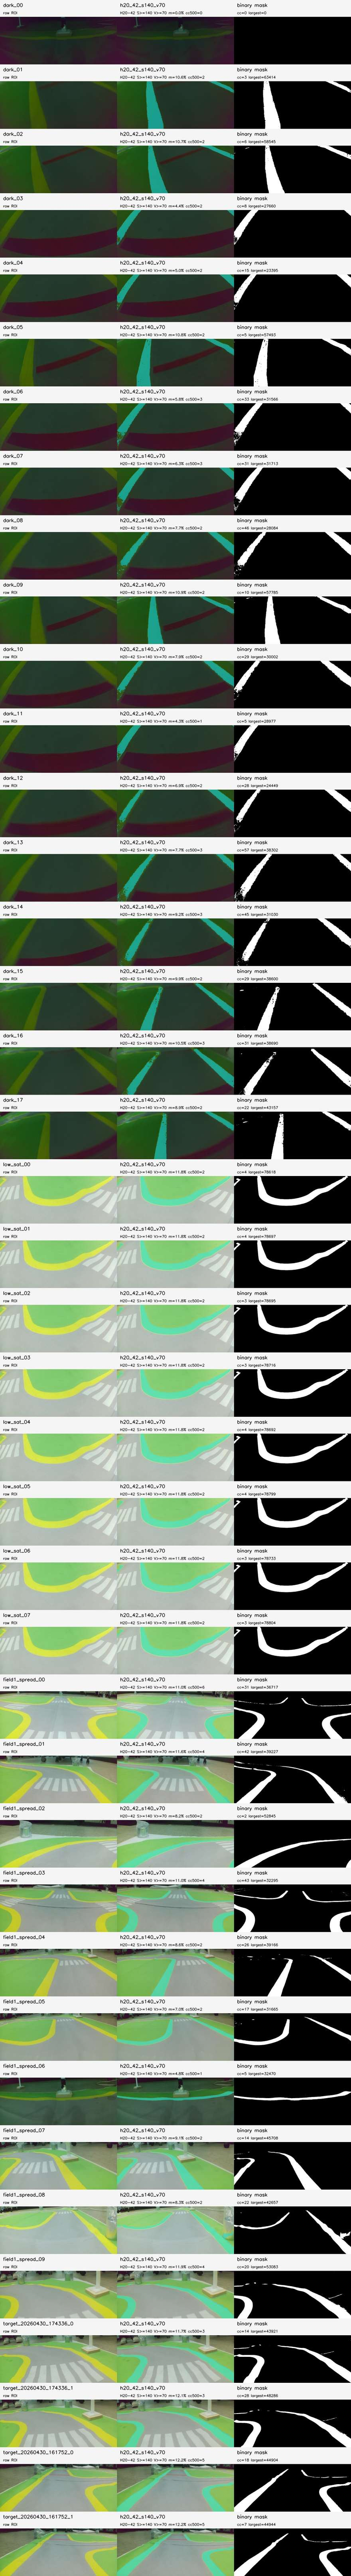

saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\h20_42_s140_v70_validation\h20_42_s140_v70_validation_field2.jpg


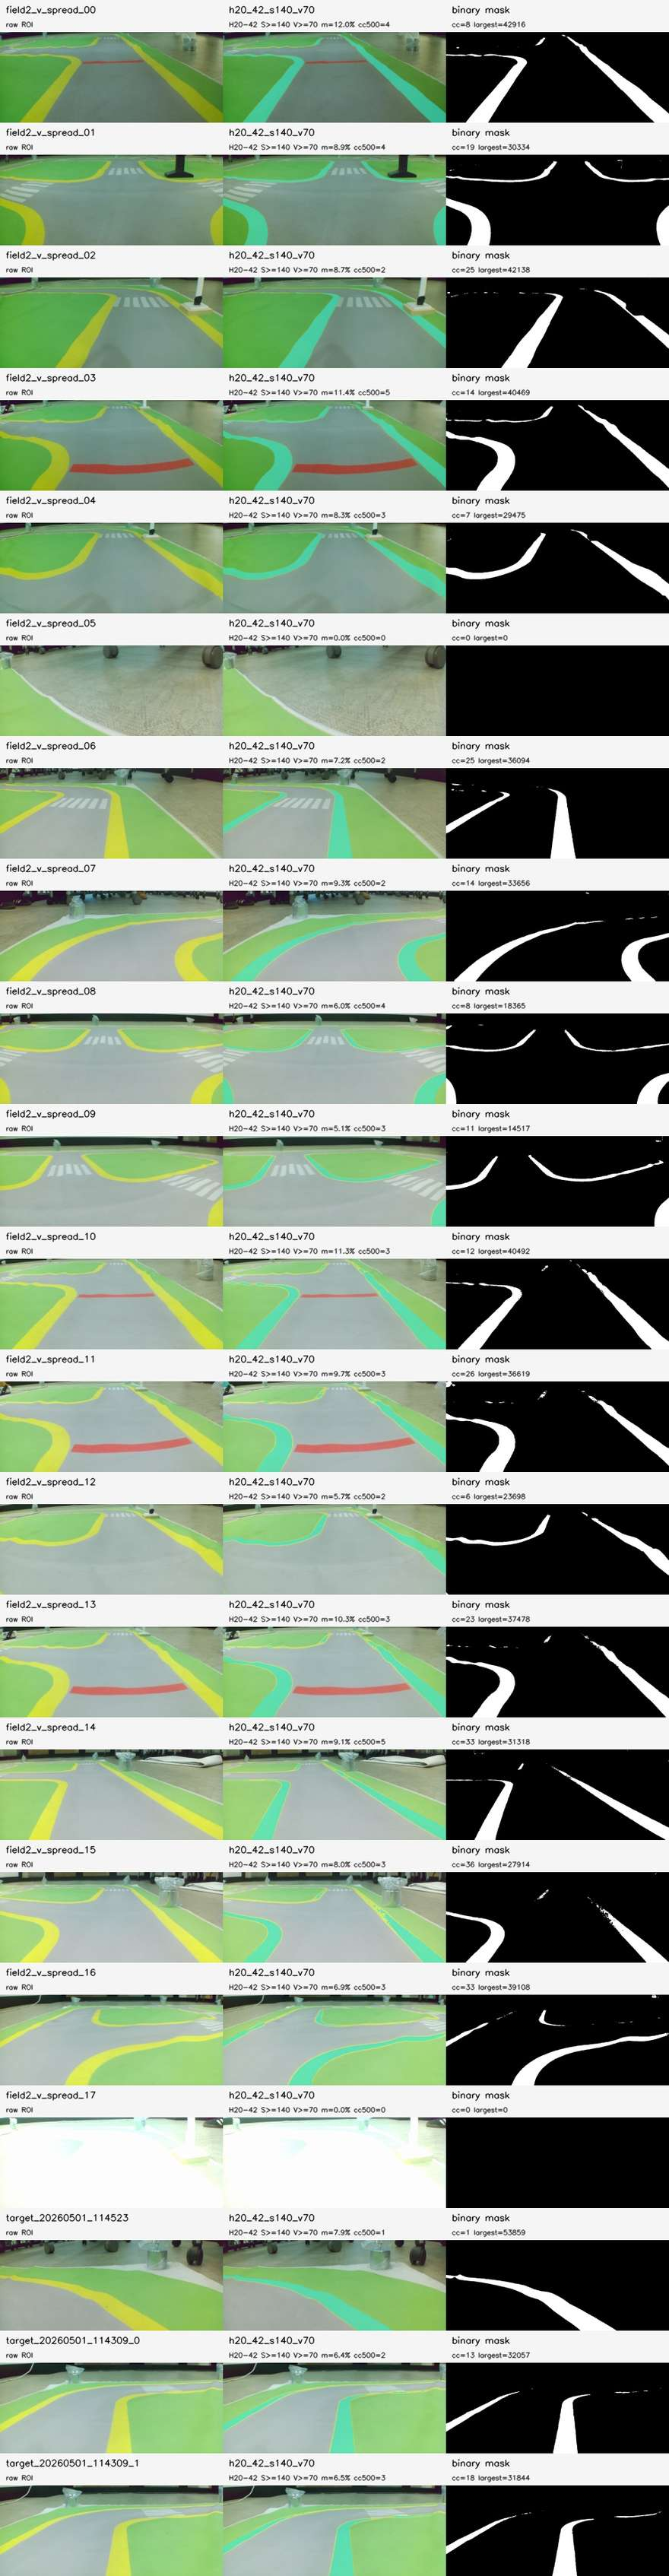

saved sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\h20_42_s140_v70_validation\h20_42_s140_v70_validation_field3.jpg


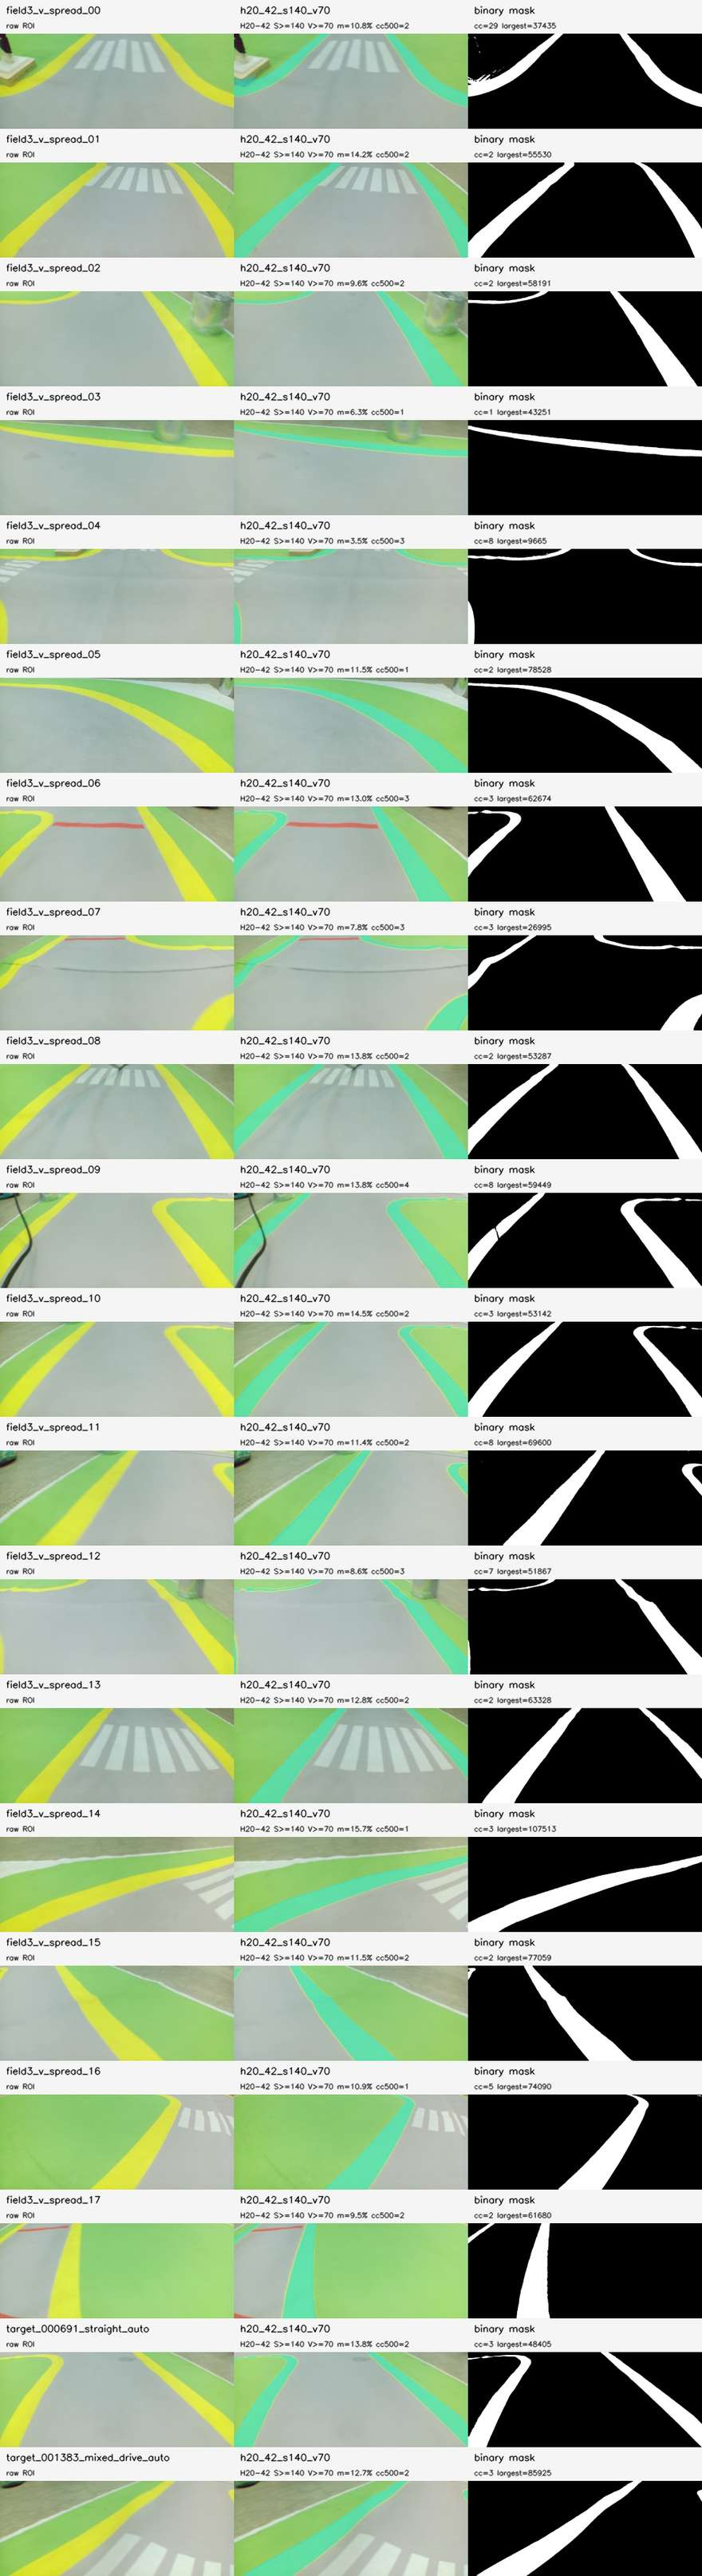

saved metrics: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\h20_42_s140_v70_validation\h20_42_s140_v70_validation_metrics.csv


,sample_count,mean_mask_ratio,median_mask_ratio,min_mask_ratio,max_mask_ratio,mean_cc500,median_cc500,mean_largest_area
group,,,,,,,,
field1,40,0.0930,0.1059,0.0000,0.1221,2.4750,2.0,46762.6000
field2,21,0.0755,0.0799,0.0000,0.1197,2.7143,3.0,30588.1429
field3,20,0.1129,0.1149,0.0348,0.1574,2.1000,2.0,58880.7000


How to read this validation:
- If field1 dark samples keep local yellow lane while background stays mostly black, this HSV is robust.
- If field2/field3 show many separated white islands, S/V or morphology must be tightened later.
- The next morphology cell will use this HSV as the current working candidate if run in sequence.


In [51]:
# 3-7. Validate one promising HSV candidate on many more samples.
# Candidate: H20-42, S>=140, V>=70.

from IPython.display import display, Image
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import json

if 'df' not in globals():
    raise RuntimeError('Run setup cells first so df is available.')
if 'REVIEW_ROOT' not in globals():
    raise RuntimeError('Run previous notebook setup cells first so REVIEW_ROOT is available.')
if 'image_stats_df' not in globals() or image_stats_df is None or len(image_stats_df) == 0:
    image_stats_df = pd.read_csv(REVIEW_ROOT / 'raw_roi_hsv_image_stats.csv')

HSV_VALIDATION_POLICY_NAME = 'h20_42_s140_v70'
HSV_VALIDATION_LOWER = np.array([20, 140, 70], dtype=np.uint8)
HSV_VALIDATION_UPPER = np.array([42, 255, 255], dtype=np.uint8)

# 다음 morphology / local fit 셀이 이 후보를 바로 이어서 쓸 수 있게 current selected 변수도 잡아둔다.
# 아직 최종 결론이라는 뜻은 아니고, 현재 검증 중인 working candidate이다.
SELECTED_HSV_POLICY_NAME = HSV_VALIDATION_POLICY_NAME
SELECTED_HSV_LOWER = HSV_VALIDATION_LOWER.copy()
SELECTED_HSV_UPPER = HSV_VALIDATION_UPPER.copy()

candidate_policy = {
    'name': HSV_VALIDATION_POLICY_NAME,
    'lower': HSV_VALIDATION_LOWER.tolist(),
    'upper': HSV_VALIDATION_UPPER.tolist(),
    'status': 'working_candidate_after_strict_hsv_sweep',
    'note': 'H is wide for recall, S is strict for noise suppression, V is low for dark yellow lane defense.',
}
candidate_path = REVIEW_ROOT / 'candidate_hsv_policy_current.json'
candidate_path.write_text(json.dumps(candidate_policy, ensure_ascii=False, indent=2), encoding='utf-8')
print('current HSV candidate:', candidate_policy)
print('saved current candidate:', candidate_path)

VALIDATION_ROOT = REVIEW_ROOT / 'h20_42_s140_v70_validation'
VALIDATION_ROOT.mkdir(parents=True, exist_ok=True)

stats = image_stats_df.copy()
stats['roi_v_median'] = stats['roi_v_median'].astype(float)
stats['roi_s_median'] = stats['roi_s_median'].astype(float)
raw_df = df[df['split'] == 'raw'].copy().reset_index(drop=True)

sample_rows = []
used_rel = set()

def add_stat_rows(rows, tag_prefix, limit):
    count = 0
    for _, row in rows.iterrows():
        rel = str(row['rel'])
        if rel in used_rel:
            continue
        rr = row.copy()
        rr['sample_tag'] = f'{tag_prefix}_{count:02d}'
        sample_rows.append(rr)
        used_rel.add(rel)
        count += 1
        if count >= limit:
            break

# field1은 어두운 조건 방어가 핵심이므로 많이 본다.
field1 = stats[stats['group'] == 'field1'].copy()
add_stat_rows(field1.sort_values(['roi_v_median', 'roi_s_median']).head(30), 'dark', 18)
add_stat_rows(field1.sort_values(['roi_s_median', 'roi_v_median']).head(20), 'low_sat', 8)
add_stat_rows(field1.iloc[np.linspace(0, len(field1) - 1, min(10, len(field1))).astype(int)] if len(field1) else field1, 'field1_spread', 10)

# field2/field3은 일반 주행 조건에서 노이즈가 늘지 않는지 본다.
for group, limit in [('field2', 18), ('field3', 18)]:
    g = stats[stats['group'] == group].copy()
    if len(g) == 0:
        continue
    # 어두움/보통/밝음이 섞이도록 quantile spread로 선택한다.
    idx = np.linspace(0, len(g.sort_values('roi_v_median')) - 1, min(limit, len(g))).astype(int)
    add_stat_rows(g.sort_values('roi_v_median').iloc[idx], f'{group}_v_spread', limit)

# 이전에 눈으로 보던 문제 샘플은 별도로 보장한다.
TARGET_KEYS = [
    '20260430_174336',
    '000691_straight_auto',
    '001383_mixed_drive_auto',
    '20260430_160157',
    '20260430_161752',
    '20260501_114523',
    '20260501_114309',
    '001729_mixed_drive_auto',
]
for key in TARGET_KEYS:
    hit = raw_df[raw_df['rel'].astype(str).str.contains(key, regex=False)]
    for j, (_, row) in enumerate(hit.head(2).iterrows()):
        rel = str(row['rel'])
        if rel in used_rel:
            continue
        rr = row.copy()
        rr['sample_tag'] = f'target_{key}_{j}' if len(hit) > 1 else f'target_{key}'
        sample_rows.append(rr)
        used_rel.add(rel)

validation_df = pd.DataFrame(sample_rows).reset_index(drop=True)
print('validation samples:', len(validation_df))
display_cols = [c for c in ['group', 'sample_tag', 'rel', 'roi_v_median', 'roi_s_median'] if c in validation_df.columns]
display(validation_df[display_cols].head(80))

# ---- helpers ----
def add_header_local(panel_bgr, title, subtitle='', thumb_w=320):
    scale = thumb_w / panel_bgr.shape[1]
    thumb_h = int(panel_bgr.shape[0] * scale)
    panel = cv2.resize(panel_bgr, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)
    header_h = 46
    canvas = np.full((thumb_h + header_h, thumb_w, 3), 245, dtype=np.uint8)
    canvas[header_h:, :, :] = panel
    cv2.putText(canvas, title[:46], (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.43, (0, 0, 0), 1, cv2.LINE_AA)
    if subtitle:
        cv2.putText(canvas, subtitle[:62], (8, 38), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (50, 50, 50), 1, cv2.LINE_AA)
    return canvas


def hstack_same_height_local(panels):
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for panel in panels:
        if panel.shape[0] < max_h:
            pad = np.full((max_h - panel.shape[0], panel.shape[1], 3), 245, dtype=np.uint8)
            panel = np.vstack([panel, pad])
        padded.append(panel)
    return np.hstack(padded)


def vstack_same_width_local(rows):
    max_w = max(r.shape[1] for r in rows)
    padded = []
    for row in rows:
        if row.shape[1] < max_w:
            pad = np.full((row.shape[0], max_w - row.shape[1], 3), 245, dtype=np.uint8)
            row = np.hstack([row, pad])
        padded.append(row)
    return np.vstack(padded)


def mask_candidate_roi(bgr):
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, HSV_VALIDATION_LOWER, HSV_VALIDATION_UPPER)
    return roi, mask


def component_stats(mask):
    num_labels, labels, stats_cc, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), 8)
    areas = [int(stats_cc[i, cv2.CC_STAT_AREA]) for i in range(1, num_labels)]
    return {
        'component_count': len(areas),
        'component_count_area100': sum(1 for a in areas if a >= 100),
        'component_count_area500': sum(1 for a in areas if a >= 500),
        'largest_component_area': max(areas) if areas else 0,
    }


def make_validation_row(bgr, title):
    roi, mask = mask_candidate_roi(bgr)
    mask_ratio = float((mask > 0).mean())
    comp = component_stats(mask)

    raw_panel = add_header_local(roi, title, 'raw ROI')

    overlay = roi.copy()
    m = mask > 0
    cyan = np.zeros_like(overlay)
    cyan[:, :] = (255, 220, 0)
    overlay[m] = (overlay[m].astype(np.float32) * 0.45 + cyan[m].astype(np.float32) * 0.55).astype(np.uint8)
    overlay_panel = add_header_local(
        overlay,
        HSV_VALIDATION_POLICY_NAME,
        f'H20-42 S>=140 V>=70 m={mask_ratio*100:.1f}% cc500={comp["component_count_area500"]}',
    )

    binary = np.zeros_like(roi)
    binary[m] = (255, 255, 255)
    binary_panel = add_header_local(
        binary,
        'binary mask',
        f'cc={comp["component_count"]} largest={comp["largest_component_area"]}',
    )
    return hstack_same_height_local([raw_panel, overlay_panel, binary_panel]), mask_ratio, comp

metric_rows = []
for group in sorted(validation_df['group'].unique()):
    rows = []
    gdf = validation_df[validation_df['group'] == group]
    for _, row in gdf.iterrows():
        bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        row_img, mask_ratio, comp = make_validation_row(bgr, str(row['sample_tag']))
        rows.append(row_img)
        metric_rows.append({
            'group': row['group'],
            'sample_tag': row['sample_tag'],
            'rel': row['rel'],
            'mask_ratio': mask_ratio,
            **comp,
        })

    if rows:
        sheet = vstack_same_width_local(rows)
        out_path = VALIDATION_ROOT / f'h20_42_s140_v70_validation_{group}.jpg'
        cv2.imwrite(str(out_path), sheet)
        print('saved sheet:', out_path)
        display(Image(filename=str(out_path)))

metrics_df = pd.DataFrame(metric_rows)
metrics_path = VALIDATION_ROOT / 'h20_42_s140_v70_validation_metrics.csv'
metrics_df.to_csv(metrics_path, index=False, encoding='utf-8-sig')
print('saved metrics:', metrics_path)

summary = metrics_df.groupby('group').agg(
    sample_count=('sample_tag', 'count'),
    mean_mask_ratio=('mask_ratio', 'mean'),
    median_mask_ratio=('mask_ratio', 'median'),
    min_mask_ratio=('mask_ratio', 'min'),
    max_mask_ratio=('mask_ratio', 'max'),
    mean_cc500=('component_count_area500', 'mean'),
    median_cc500=('component_count_area500', 'median'),
    mean_largest_area=('largest_component_area', 'mean'),
).round(4)
display(summary)

print('How to read this validation:')
print('- If field1 dark samples keep local yellow lane while background stays mostly black, this HSV is robust.')
print('- If field2/field3 show many separated white islands, S/V or morphology must be tightened later.')
print('- The next morphology cell will use this HSV as the current working candidate if run in sequence.')


### 3-8. Morphology 후보 비교: HSV mask를 얼마나 다듬을 것인가

HSV 후보는 3-7에서 검증 중인 `h20_42_s140_v70`을 현재 working candidate로 둔다. 이제 같은 HSV mask에 morphology를 적용할지 결정한다.

Morphology는 공식 CLRKDNet에는 없는 단계다. 이것도 우리 pseudo-label 생성용 전처리 정책이다.

여기서 보는 것은 다음이다.

- raw HSV mask만으로도 차선 덩어리가 충분히 이어지는가?
- 작은 노이즈를 제거하려면 opening이 필요한가?
- 끊긴 노란선을 이어주려면 closing이 필요한가?
- kernel이 커질수록 차선 주변의 다른 영역과 붙어버리지는 않는가?

이 셀에서는 아직 component를 lane으로 선택하지 않는다. 단지 **마스크 자체를 어떤 형태로 정제할지**만 비교한다.


selected HSV policy: h20_42_s140_v70 [20, 140, 70] [42, 255, 255]
morph candidates: ['raw_mask', 'close3', 'open3_close3', 'open3_close5', 'open5_close5']


,group,sample_tag,roi_v_median,roi_s_median,rel
0,field1,dark_p10,95.0,88.0,field1\signs\left\20260430_172423_signs_left_s...
1,field1,normal_p50,172.0,47.0,field1\signs\straight\20260430_174335_signs_st...
2,field1,bright_p90,190.0,47.0,field1\lane\intersection\20260430_160157_lane_...
3,field2,dark_p10,149.0,66.5,field2\06_sign_capture_drive\left\20260501_121...
4,field2,normal_p50,181.5,46.0,field2\06_sign_capture_drive\left\20260501_121...
5,field2,bright_p90,194.0,70.0,field2\01_lane_drive_capture\intersection_left...
6,field3,dark_p10,184.0,24.0,field3\field_drive\000018_mixed_drive_auto_202...
7,field3,normal_p50,190.0,22.0,field3\field_drive\001067_mixed_drive_auto_202...
8,field3,bright_p90,199.0,19.0,field3\field_drive\000054_mixed_drive_auto_202...
9,field1,target_20260430_174336_0,NaN,NaN,field1\signs\straight\20260430_174336_signs_st...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\morphology_candidate_overlays\morphology_candidate_binary_field1.jpg


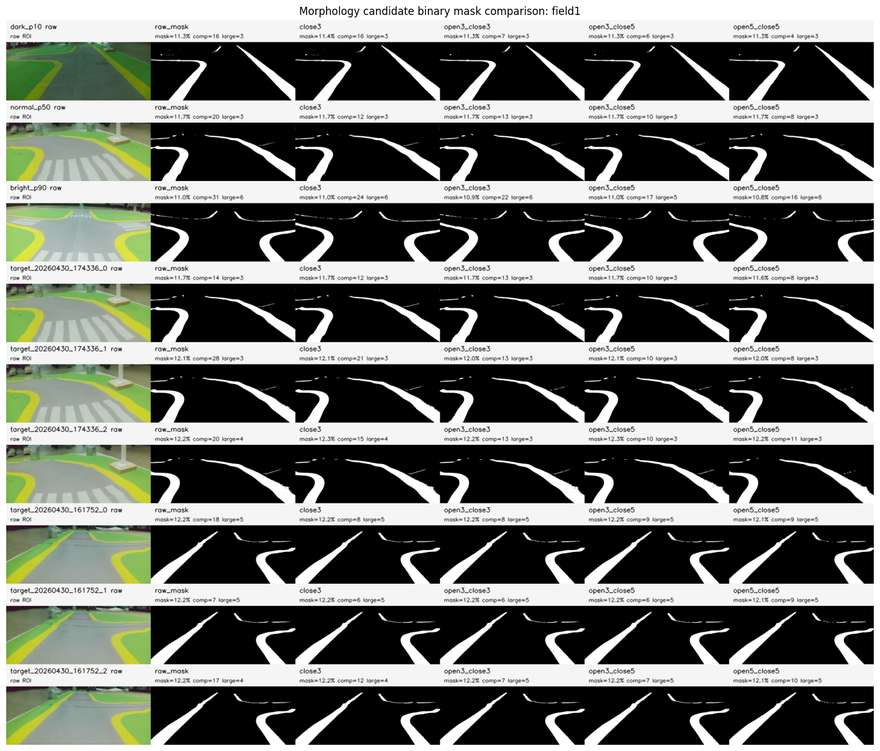

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\morphology_candidate_overlays\morphology_candidate_binary_field2.jpg


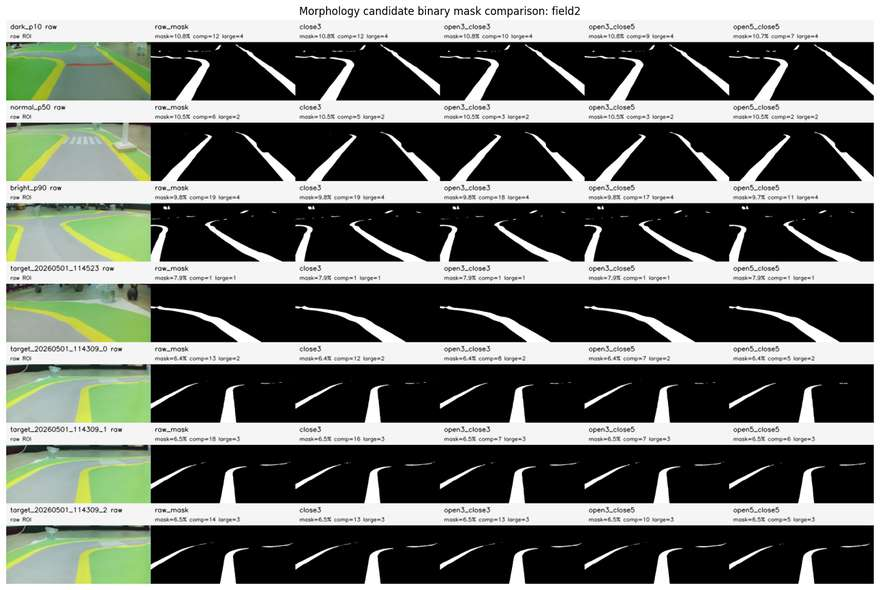

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\morphology_candidate_overlays\morphology_candidate_binary_field3.jpg


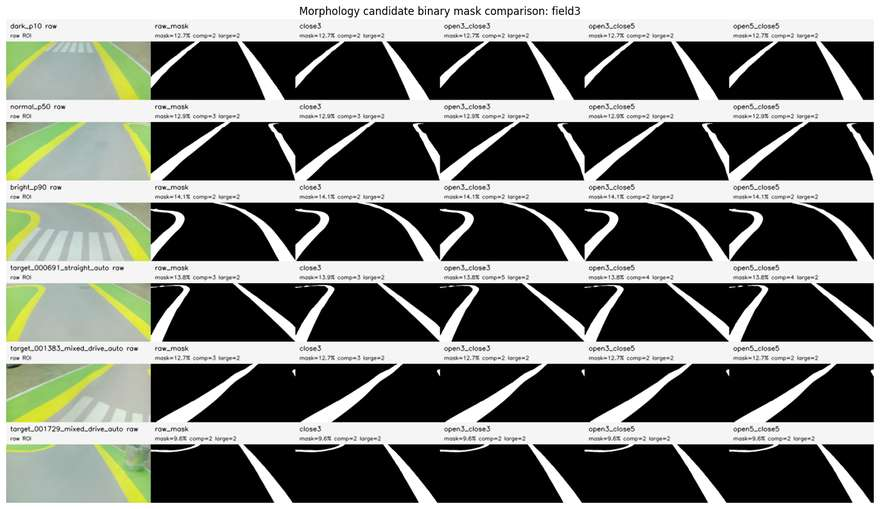

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\morphology_candidate_overlays\morphology_candidate_stats.csv


morph_candidate                        close3  open3_close3  open3_close5  \
group  sample_tag                                                           
field1 bright_p90                        24.0          22.0          17.0   
       dark_p10                          16.0           7.0           6.0   
       normal_p50                        12.0          13.0          10.0   
       target_20260430_161752_0           8.0           8.0           9.0   
       target_20260430_161752_1           6.0           6.0           6.0   
       target_20260430_161752_2          12.0           7.0           7.0   
       target_20260430_174336_0          12.0          13.0          10.0   
       target_20260430_174336_1          21.0          13.0          10.0   
       target_20260430_174336_2          15.0          13.0          10.0   
field2 bright_p90                        19.0          18.0          17.0   
       dark_p10                          12.0          10.0           9.0   
       normal_p50                         5.0           3.0           3.0   
       target_20260501_114309_0          12.0           8.0           7.0   
       target_20260501_114309_1          16.0           7.0           7.0   
       target_20260501_114309_2          13.0          13.0          10.0   
       target_20260501_114523             1.0           1.0           1.0   
field3 bright_p90                         2.0           2.0           2.0   
       dark_p10                           2.0           2.0           2.0   
       normal_p50                         3.0           2.0           2.0   
       target_000691_straight_auto        3.0           5.0           4.0   
       target_001383_mixed_drive_auto     3.0           2.0           2.0   
       target_001729_mixed_drive_auto     2.0           2.0           2.0   

morph_candidate                        open5_close5  raw_mask  
group  sample_tag                                              
field1 bright_p90                              16.0      31.0  
       dark_p10                                 4.0      16.0  
       normal_p50                               8.0      20.0  
       target_20260430_161752_0                 9.0      18.0  
       target_20260430_161752_1                 9.0       7.0  
       target_20260430_161752_2                10.0      17.0  
       target_20260430_174336_0                 8.0      14.0  
       target_20260430_174336_1                 8.0      28.0  
       target_20260430_174336_2                11.0      20.0  
field2 bright_p90                              11.0      19.0  
       dark_p10                                 7.0      12.0  
       normal_p50                               2.0       6.0  
       target_20260501_114309_0                 5.0      13.0  
       target_20260501_114309_1                 6.0      18.0  
       target_20260501_114309_2                 5.0      14.0  
       target_20260501_114523                   1.0       1.0  
field3 bright_p90                               2.0       2.0  
       dark_p10                                 2.0       2.0  
       normal_p50                               2.0       3.0  
       target_000691_straight_auto              4.0       3.0  
       target_001383_mixed_drive_auto           2.0       3.0  
       target_001729_mixed_drive_auto           2.0       2.0

morph_candidate                        close3  open3_close3  open3_close5  \
group  sample_tag                                                           
field1 bright_p90                         6.0           6.0           5.0   
       dark_p10                           3.0           3.0           3.0   
       normal_p50                         3.0           3.0           3.0   
       target_20260430_161752_0           5.0           5.0           5.0   
       target_20260430_161752_1           5.0           5.0           5.0   
       target_20260430_161752_2           4.0           5.0           5.0   
       target_20260430_174336_0           3.0           3.0           3.0   
       target_20260430_174336_1           3.0           3.0           3.0   
       target_20260430_174336_2           4.0           3.0           3.0   
field2 bright_p90                         4.0           4.0           4.0   
       dark_p10                           4.0           4.0           4.0   
       normal_p50                         2.0           2.0           2.0   
       target_20260501_114309_0           2.0           2.0           2.0   
       target_20260501_114309_1           3.0           3.0           3.0   
       target_20260501_114309_2           3.0           3.0           3.0   
       target_20260501_114523             1.0           1.0           1.0   
field3 bright_p90                         2.0           2.0           2.0   
       dark_p10                           2.0           2.0           2.0   
       normal_p50                         2.0           2.0           2.0   
       target_000691_straight_auto        2.0           2.0           2.0   
       target_001383_mixed_drive_auto     2.0           2.0           2.0   
       target_001729_mixed_drive_auto     2.0           2.0           2.0   

morph_candidate                        open5_close5  raw_mask  
group  sample_tag                                              
field1 bright_p90                               6.0       6.0  
       dark_p10                                 3.0       3.0  
       normal_p50                               3.0       3.0  
       target_20260430_161752_0                 5.0       5.0  
       target_20260430_161752_1                 5.0       5.0  
       target_20260430_161752_2                 5.0       4.0  
       target_20260430_174336_0                 3.0       3.0  
       target_20260430_174336_1                 3.0       3.0  
       target_20260430_174336_2                 3.0       4.0  
field2 bright_p90                               4.0       4.0  
       dark_p10                                 4.0       4.0  
       normal_p50                               2.0       2.0  
       target_20260501_114309_0                 2.0       2.0  
       target_20260501_114309_1                 3.0       3.0  
       target_20260501_114309_2                 3.0       3.0  
       target_20260501_114523                   1.0       1.0  
field3 bright_p90                               2.0       2.0  
       dark_p10                                 2.0       2.0  
       normal_p50                               2.0       2.0  
       target_000691_straight_auto              2.0       2.0  
       target_001383_mixed_drive_auto           2.0       2.0  
       target_001729_mixed_drive_auto           2.0       2.0

morph_candidate                        close3  open3_close3  open3_close5  \
group  sample_tag                                                           
field1 bright_p90                      0.1101        0.1094        0.1095   
       dark_p10                        0.1136        0.1133        0.1133   
       normal_p50                      0.1174        0.1169        0.1170   
       target_20260430_161752_0        0.1220        0.1217        0.1218   
       target_20260430_161752_1        0.1223        0.1220        0.1221   
       target_20260430_161752_2        0.1223        0.1219        0.1220   
       target_20260430_174336_0        0.1172        0.1168        0.1169   
       target_20260430_174336_1        0.1209        0.1204        0.1206   
       target_20260430_174336_2        0.1227        0.1223        0.1225   
field2 bright_p90                      0.0982        0.0978        0.0979   
       dark_p10                        0.1079        0.1077        0.1077   
       normal_p50                      0.1051        0.1049        0.1049   
       target_20260501_114309_0        0.0645        0.0642        0.0643   
       target_20260501_114309_1        0.0653        0.0651        0.0652   
       target_20260501_114309_2        0.0654        0.0652        0.0653   
       target_20260501_114523          0.0789        0.0788        0.0789   
field3 bright_p90                      0.1415        0.1413        0.1414   
       dark_p10                        0.1267        0.1266        0.1266   
       normal_p50                      0.1294        0.1293        0.1293   
       target_000691_straight_auto     0.1386        0.1384        0.1384   
       target_001383_mixed_drive_auto  0.1275        0.1274        0.1274   
       target_001729_mixed_drive_auto  0.0960        0.0959        0.0959   

morph_candidate                        open5_close5  raw_mask  
group  sample_tag                                              
field1 bright_p90                            0.1084    0.1099  
       dark_p10                              0.1131    0.1135  
       normal_p50                            0.1165    0.1172  
       target_20260430_161752_0              0.1212    0.1219  
       target_20260430_161752_1              0.1214    0.1221  
       target_20260430_161752_2              0.1213    0.1221  
       target_20260430_174336_0              0.1163    0.1170  
       target_20260430_174336_1              0.1199    0.1208  
       target_20260430_174336_2              0.1216    0.1225  
field2 bright_p90                            0.0971    0.0981  
       dark_p10                              0.1074    0.1079  
       normal_p50                            0.1049    0.1050  
       target_20260501_114309_0              0.0639    0.0644  
       target_20260501_114309_1              0.0647    0.0652  
       target_20260501_114309_2              0.0647    0.0654  
       target_20260501_114523                0.0788    0.0789  
field3 bright_p90                            0.1413    0.1414  
       dark_p10                              0.1266    0.1266  
       normal_p50                            0.1292    0.1293  
       target_000691_straight_auto           0.1382    0.1385  
       target_001383_mixed_drive_auto        0.1273    0.1274  
       target_001729_mixed_drive_auto        0.0959    0.0959

How to read this cell:
- raw_mask shows the selected HSV mask before cleanup.
- open removes small speckles but can erode thin lane parts.
- close fills small gaps and connects nearby lane fragments.
- A good candidate should keep lane shapes continuous without merging too much background noise.


In [52]:
# Compare morphology candidates on the current working HSV mask.
# This is still mask-level policy, before connected-component filtering and polyline extraction.

# Fallbacks so this cell can run independently after prior cells have been executed once.
if 'SELECTED_HSV_LOWER' not in globals() or 'SELECTED_HSV_UPPER' not in globals():
    candidate_hsv_path = REVIEW_ROOT / 'candidate_hsv_policy_current.json'
    selected_hsv_path = REVIEW_ROOT / 'selected_hsv_policy_v1.json'
    if candidate_hsv_path.exists():
        selected_hsv_policy = json.loads(candidate_hsv_path.read_text(encoding='utf-8'))
    else:
        selected_hsv_policy = json.loads(selected_hsv_path.read_text(encoding='utf-8'))
    SELECTED_HSV_POLICY_NAME = selected_hsv_policy['name']
    SELECTED_HSV_LOWER = np.array(selected_hsv_policy['lower'], dtype=np.uint8)
    SELECTED_HSV_UPPER = np.array(selected_hsv_policy['upper'], dtype=np.uint8)

if 'image_stats_df' not in globals() or image_stats_df is None or len(image_stats_df) == 0:
    stats_path = REVIEW_ROOT / 'raw_roi_hsv_image_stats.csv'
    image_stats_df = pd.read_csv(stats_path)

MORPH_ROOT = REVIEW_ROOT / 'morphology_candidate_overlays'
MORPH_ROOT.mkdir(parents=True, exist_ok=True)

# Candidate definitions. Opening removes small noise. Closing fills gaps and joins nearby fragments.
MORPH_CANDIDATES = {
    'raw_mask': [],
    'close3': [('close', 3)],
    'open3_close3': [('open', 3), ('close', 3)],
    'open3_close5': [('open', 3), ('close', 5)],
    'open5_close5': [('open', 5), ('close', 5)],
}


def hsv_medium_mask(bgr):
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    return cv2.inRange(hsv, SELECTED_HSV_LOWER, SELECTED_HSV_UPPER)


def apply_morphology(mask, candidate_name):
    out = mask.copy()
    for op, k in MORPH_CANDIDATES[candidate_name]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        if op == 'open':
            out = cv2.morphologyEx(out, cv2.MORPH_OPEN, kernel)
        elif op == 'close':
            out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, kernel)
        else:
            raise ValueError(op)
    return out


def component_stats(mask):
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats((mask > 0).astype(np.uint8), connectivity=8)
    areas = stats[1:, cv2.CC_STAT_AREA] if n_labels > 1 else np.array([], dtype=np.int32)
    heights = stats[1:, cv2.CC_STAT_HEIGHT] if n_labels > 1 else np.array([], dtype=np.int32)
    widths = stats[1:, cv2.CC_STAT_WIDTH] if n_labels > 1 else np.array([], dtype=np.int32)
    return {
        'component_count': int(len(areas)),
        'large_component_count_area500': int((areas >= 500).sum()) if len(areas) else 0,
        'largest_area': int(areas.max()) if len(areas) else 0,
        'largest_height': int(heights[areas.argmax()]) if len(areas) else 0,
        'largest_width': int(widths[areas.argmax()]) if len(areas) else 0,
        'small_component_count_area_lt100': int((areas < 100).sum()) if len(areas) else 0,
    }

# Reuse selected_df if available; otherwise recreate the same dark/normal/bright sample selection.
if 'selected_df' not in globals() or selected_df is None or len(selected_df) == 0:
    selected_rows = []
    for group in sorted(image_stats_df['group'].unique()):
        gdf = image_stats_df[image_stats_df['group'] == group].copy()
        targets = [
            ('dark_p10', gdf['roi_v_median'].quantile(0.10)),
            ('normal_p50', gdf['roi_v_median'].quantile(0.50)),
            ('bright_p90', gdf['roi_v_median'].quantile(0.90)),
        ]
        used_paths = set()
        for tag, target_v in targets:
            candidates = gdf.assign(_dist=(gdf['roi_v_median'] - target_v).abs()).sort_values('_dist')
            for _, r in candidates.iterrows():
                if r['path'] not in used_paths:
                    rr = r.copy()
                    rr['sample_tag'] = tag
                    selected_rows.append(rr)
                    used_paths.add(r['path'])
                    break
    selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)

print('selected HSV policy:', SELECTED_HSV_POLICY_NAME, SELECTED_HSV_LOWER.tolist(), SELECTED_HSV_UPPER.tolist())
print('morph candidates:', list(MORPH_CANDIDATES.keys()))
display(selected_df[['group', 'sample_tag', 'roi_v_median', 'roi_s_median', 'rel']])


def add_header(panel_bgr, title, subtitle='', thumb_w=300):
    scale = thumb_w / panel_bgr.shape[1]
    thumb_h = int(panel_bgr.shape[0] * scale)
    panel = cv2.resize(panel_bgr, (thumb_w, thumb_h), interpolation=cv2.INTER_AREA)
    header_h = 46
    canvas = np.full((thumb_h + header_h, thumb_w, 3), 245, dtype=np.uint8)
    canvas[header_h:, :, :] = panel
    cv2.putText(canvas, title[:42], (8, 18), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 1, cv2.LINE_AA)
    if subtitle:
        cv2.putText(canvas, subtitle[:52], (8, 37), cv2.FONT_HERSHEY_SIMPLEX, 0.36, (50, 50, 50), 1, cv2.LINE_AA)
    return canvas


def binary_panel(mask, name, ratio, stats, thumb_w=300):
    binary = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    binary[mask > 0] = (255, 255, 255)
    subtitle = f'mask={ratio*100:.1f}% comp={stats["component_count"]} large={stats["large_component_count_area500"]}'
    return add_header(binary, name, subtitle, thumb_w=thumb_w)


def raw_roi_panel(bgr, title, thumb_w=300):
    roi = bgr[CUT_HEIGHT:, :, :]
    return add_header(roi, title, 'raw ROI', thumb_w=thumb_w)


def hstack_same_height(panels):
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        if p.shape[0] < max_h:
            pad = np.full((max_h - p.shape[0], p.shape[1], 3), 245, dtype=np.uint8)
            p = np.vstack([p, pad])
        padded.append(p)
    return np.hstack(padded)


def vstack_same_width(rows):
    max_w = max(r.shape[1] for r in rows)
    padded = []
    for r in rows:
        if r.shape[1] < max_w:
            pad = np.full((r.shape[0], max_w - r.shape[1], 3), 245, dtype=np.uint8)
            r = np.hstack([r, pad])
        padded.append(r)
    return np.vstack(padded)

morph_rows = []
for group in sorted(selected_df['group'].unique()):
    group_rows = []
    gsel = selected_df[selected_df['group'] == group]
    for _, row in gsel.iterrows():
        path = Path(row['path'])
        bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if bgr is None:
            continue
        base_mask = hsv_medium_mask(bgr)
        panels = [raw_roi_panel(bgr, f'{row["sample_tag"]} raw')]
        for name in MORPH_CANDIDATES:
            mask = apply_morphology(base_mask, name)
            ratio = float((mask > 0).mean())
            stats = component_stats(mask)
            morph_rows.append({
                'group': row['group'],
                'sample_tag': row['sample_tag'],
                'rel': row['rel'],
                'morph_candidate': name,
                'mask_ratio': ratio,
                **stats,
            })
            panels.append(binary_panel(mask, name, ratio, stats))
        group_rows.append(hstack_same_height(panels))

    if group_rows:
        sheet = vstack_same_width(group_rows)
        out_path = MORPH_ROOT / f'morphology_candidate_binary_{group}.jpg'
        cv2.imwrite(str(out_path), sheet)
        print('saved:', out_path)
        img_rgb = cv2.cvtColor(sheet, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(18, max(6, len(group_rows) * 2.5)))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f'Morphology candidate binary mask comparison: {group}')
        plt.show()

morph_df = pd.DataFrame(morph_rows)
morph_path = MORPH_ROOT / 'morphology_candidate_stats.csv'
morph_df.to_csv(morph_path, index=False, encoding='utf-8-sig')
print('saved:', morph_path)

display(morph_df.pivot_table(index=['group', 'sample_tag'], columns='morph_candidate', values='component_count').round(1))
display(morph_df.pivot_table(index=['group', 'sample_tag'], columns='morph_candidate', values='large_component_count_area500').round(1))
display(morph_df.pivot_table(index=['group', 'sample_tag'], columns='morph_candidate', values='mask_ratio').round(4))

print('How to read this cell:')
print('- raw_mask shows the selected HSV mask before cleanup.')
print('- open removes small speckles but can erode thin lane parts.')
print('- close fills small gaps and connects nearby lane fragments.')
print('- A good candidate should keep lane shapes continuous without merging too much background noise.')

### 3-9. 결정: Morphology는 약한 `open3_close3`만 적용

Morphology 후보 비교 결과, 우리 데이터에서는 노란선이 이미 굵고 HSV mask도 충분히 이어져 있어 morphology가 핵심 단계는 아니다.

다만 `raw_mask`는 field1/field2 일부 샘플에서 작은 component가 많이 남는다. 이후 component filtering으로 제거할 수는 있지만, 작은 점노이즈를 미리 줄여두면 다음 단계의 component 분석이 더 안정적이다.

따라서 1차 morphology 정책은 가장 약한 정제에 가까운 `open3_close3`로 정한다.

```python
MORPH_POLICY = [("open", 3), ("close", 3)]
```

판단 이유는 다음과 같다.

- `raw_mask`: 차선 형태는 좋지만 작은 component가 많이 남는다.
- `close3`: 끊김을 메우지만 작은 노이즈 제거 효과는 약하다.
- `open3_close3`: mask 비율과 큰 lane component는 거의 유지하면서 작은 component를 줄인다.
- `open3_close5`: 결과는 비슷하지만 close가 더 강해져, 가까운 노이즈와 lane이 붙을 여지가 조금 늘어난다.
- `open5_close5`: 큰 문제는 없어 보이나, 불필요하게 강한 정제라 얇은 부분을 깎거나 형태를 바꿀 수 있다.

즉 morphology는 “좋은 GT를 만드는 핵심”이 아니라, HSV mask를 component 추출에 넘기기 전 아주 약하게 정리하는 보조 단계로 둔다.


In [ ]:
# Decision checkpoint: first morphology policy for selected HSV mask.
SELECTED_MORPH_POLICY_NAME = 'open3_close3'
SELECTED_MORPH_POLICY = [('open', 3), ('close', 3)]

selected_morph_policy = {
    'name': SELECTED_MORPH_POLICY_NAME,
    'operations': [{'op': op, 'kernel': k} for op, k in SELECTED_MORPH_POLICY],
    'decision_reason': (
        'Yellow lane masks are already thick and mostly continuous. Use weak open3_close3 only '
        'to reduce small speckles while preserving large lane components. Stronger kernels are unnecessary.'
    ),
}

selected_morph_path = REVIEW_ROOT / 'selected_morph_policy_v1.json'
selected_morph_path.write_text(json.dumps(selected_morph_policy, ensure_ascii=False, indent=2), encoding='utf-8')

print('selected morphology policy:', selected_morph_policy)
print('saved:', selected_morph_path)

## 4. Local-fit label 정책: 노란 마스크에서 주행용 직선 라벨을 만든다

여기서부터는 3번에서 확정한 노란색 mask를 **CLRKDNet이 학습할 수 있는 `.lines.txt` 좌표**로 바꾸는 단계다. 이 셀의 목적은 최종 dataset을 바로 만드는 것이 아니라, 우리가 어떤 규칙으로 라벨을 만들지 이해하고 검증하는 것이다.

핵심 아이디어는 단순하다.

1. raw 이미지에서 `cut_height=445` 아래 ROI만 본다.
2. 3번에서 정한 HSV/morphology로 노란 차선 mask를 만든다.
3. mask의 connected component를 각각 후보 차선 조각으로 본다.
4. component 전체를 곡선으로 따라가지 않고, **component의 아래쪽 local window**만 사용한다.
5. 그 local window 안에서 y row별 mask 중심 x를 뽑는다.
6. 그 중심점들에 `x = a*y + b` 직선을 fitting한다.
7. fitting된 직선을 `sample_y` row들까지 연장해서 `.lines.txt` 후보 좌표를 만든다.

이렇게 하는 이유는 우리 목표가 “지도 전체 노란선을 완벽히 복원하는 것”이 아니라, **자동차가 당장 따라갈 수 있는 local lane direction을 모델이 배우게 하는 것**이기 때문이다. 그래서 U자 전체, 교차로 가로선 전체를 억지로 하나의 라벨로 만들기보다, 주행에 필요한 가까운 방향성 위주로 라벨을 만든다.

### 이 셀에서 조절하는 기본값

아래 코드셀에는 현재까지 괜찮아 보였던 값을 **예시 default**로 넣어두었다.

| 값 | 현재 default | 의미 |
| --- | ---: | --- |
| `LOCAL_FIT_WINDOW_PX` | 260 | component의 가장 아래쪽에서 위로 몇 px까지 local 방향으로 볼지 |
| `MIN_COMPONENT_AREA` | 500 | 너무 작은 노이즈 component 제거 기준 |
| `MIN_LOCAL_PIXELS` | 180 | local window 안에 fitting할 mask 픽셀이 최소 몇 개 있어야 하는지 |
| `MIN_LOCAL_Y_SPAN` | 45 | `x=f(y)` 형태로 볼 만큼 y 방향 길이가 있는지 |
| `MAX_FIT_RMS_PX` | 55 | 직선 fitting 오차가 이보다 크면 곡선/가로형 component로 보고 reject |
| `ROW_CENTER_Y_STEP` | 4 | 몇 px 단위로 row-wise center를 뽑을지 |
| `MIN_ROW_CENTER_POINTS` | 10 | fitting에 필요한 row-wise center 점 개수 |
| `DUPLICATE_X_GAP_PX` | 150 | 같은 lane을 중복 선택하지 않기 위한 x 거리 기준 |
| `MAX_SELECTED_LANES` | 2 | 한 이미지에서 최대로 선택할 line 수 |

### overlay를 읽는 법

- 초록 tint: HSV/morphology로 잡힌 노란 mask
- 빨간 가로선: `cut_height=445`, 모델이 보는 ROI 시작선
- 회색 얇은 선: 최종 선택 전 상위 후보 preview
- 노랑/분홍 굵은 선: 실제 mask가 뒷받침한 local fitting 구간
- 노랑/분홍 얇은 선: `.lines.txt`로 확장될 직선 방향
- 박스: 선택된 component/local window의 대략적 영역

4번 셀은 대표 샘플에서 동작을 눈으로 확인하고, 4-1 셀은 같은 default 값을 field3 raw 샘플에 넓게 적용해 안정성을 확인한다.


base HSV policy from section 3: h20_42_s140_v70 [20, 140, 70] [42, 255, 255]
base morph policy from section 3: open3_close3 [('open', 3), ('close', 3)]
local-fit experiment policy: h20_42_s140_v70


,parameter,value,meaning
0,mask_hsv_lower,"[20, 140, 70]",HSV lower bound for yellow mask
1,mask_hsv_upper,"[42, 255, 255]",HSV upper bound for yellow mask
2,morph_policy,"[(open, 3), (close, 3)]",small noise remove/open + small gap close
3,local_fit_window_px,260,component bottom에서 위로 보는 local window 높이
4,min_component_area,500,작은 노이즈 component 제거
5,min_local_pixels,180,local window 안 fitting 근거 픽셀 최소 수
6,min_local_y_span,45,x=f(y) 라벨로 쓸 y 방향 최소 길이
7,max_fit_rms_px,55.0,직선 fitting 평균 오차 허용치
8,row_center_y_step,4,row-wise center 추출 y 간격
9,min_row_center_points,10,직선 fitting에 필요한 중심점 최소 개수


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_v1\frame_summary.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_v1\selected_lines.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_v1\reject_sample.csv

Frame summary


,sample_idx,group,rel,component_count,candidate_count,selected_count,duplicate_skipped_count,rejected_count,best_local_pixels,best_fit_rms_px
0,0,field1,field1\lane\intersection\20260430_160157_lane_...,21,4,2,0,17,29226,15.984
1,1,field1,field1\lane\right_curve\20260430_161752_lane_n...,9,3,2,0,6,34249,8.436
2,2,field1,field1\signs\horn\20260430_174402_signs_horn_m...,13,2,2,0,11,25744,10.724
3,3,field1,field1\signs\red\20260430_174821_signs_red_mov...,9,2,2,0,7,35584,1.604
4,4,field1,field1\signs\speed_20\20260430_174658_signs_sp...,18,2,2,0,16,28053,0.817
5,5,field1,field1\signs\straight\20260430_174336_signs_st...,11,2,2,0,9,40184,11.004
6,6,field2,field2\01_lane_drive_capture\failure_cases\202...,1,1,1,0,0,44423,17.760
7,7,field2,field2\01_lane_drive_capture\intersection_righ...,5,2,2,0,3,9731,3.306
8,8,field2,field2\01_lane_drive_capture\off_center_right\...,8,2,2,0,6,27527,0.535
9,9,field2,field2\06_sign_capture_drive\left\20260501_121...,2,2,2,0,0,28303,2.434



Selected local-fit lines


,group,rel,lane_idx,label_id,component_area,local_pixels,local_y_span,row_center_count,fit_rms_px,line_quality,x_at_dup_y,sample_point_count,sample_points_preview
0,field1,field1\lane\intersection\20260430_160157_lane_...,0,20,36709,29226,260,66,15.984,0.942,226.395,27,137.1 971 152.0 951 166.9 931 181.8 911 196.6 ...
1,field1,field1\lane\intersection\20260430_160157_lane_...,1,21,30992,28596,260,66,38.420,0.860,1067.713,27,1091.7 971 1087.7 951 1083.7 931 1079.7 911 10...
2,field1,field1\lane\right_curve\20260430_161752_lane_n...,0,1,44889,34249,260,66,8.436,0.969,164.363,27,32.3 971 54.3 951 76.3 931 98.3 911 120.4 891 ...
3,field1,field1\lane\right_curve\20260430_161752_lane_n...,1,9,34549,27462,260,66,12.927,0.953,1051.431,27,1128.7 971 1115.9 951 1103.0 931 1090.1 911 10...
4,field1,field1\signs\horn\20260430_174402_signs_horn_m...,0,1,37922,25744,260,66,10.724,0.961,1214.933,27,1292.6 971 1279.6 951 1266.7 931 1253.8 911 12...
5,field1,field1\signs\horn\20260430_174402_signs_horn_m...,1,5,43027,33626,260,66,21.781,0.921,307.674,27,143.3 971 170.7 951 198.1 931 225.5 911 252.9 ...
6,field1,field1\signs\red\20260430_174821_signs_red_mov...,0,2,48015,35584,260,66,1.604,0.994,995.509,27,1071.9 971 1059.2 951 1046.4 931 1033.7 911 10...
7,field1,field1\signs\red\20260430_174821_signs_red_mov...,1,5,29249,21970,260,66,8.624,0.969,127.833,27,6.3 971 26.6 951 46.8 931 67.1 911 87.3 891 10...
8,field1,field1\signs\speed_20\20260430_174658_signs_sp...,0,10,37596,28053,260,66,0.817,0.997,393.866,27,325.6 971 337.0 951 348.4 931 359.8 911 371.1 ...
9,field1,field1\signs\speed_20\20260430_174658_signs_sp...,1,8,25435,21200,260,66,13.303,0.943,1290.570,21,1290.6 851 1266.1 831 1241.7 811 1217.3 791 11...



Target frames


,sample_idx,group,rel,component_count,candidate_count,selected_count,duplicate_skipped_count,rejected_count,best_local_pixels,best_fit_rms_px
0,0,field1,field1\lane\intersection\20260430_160157_lane_...,21,4,2,0,17,29226,15.984
1,1,field1,field1\lane\right_curve\20260430_161752_lane_n...,9,3,2,0,6,34249,8.436
5,5,field1,field1\signs\straight\20260430_174336_signs_st...,11,2,2,0,9,40184,11.004
6,6,field2,field2\01_lane_drive_capture\failure_cases\202...,1,1,1,0,0,44423,17.760
8,8,field2,field2\01_lane_drive_capture\off_center_right\...,8,2,2,0,6,27527,0.535
14,14,field3,field3\field_drive\000691_straight_auto_202605...,4,2,2,0,2,29123,3.845
17,17,field3,field3\field_drive\001729_mixed_drive_auto_202...,2,2,2,0,0,37044,1.090
18,18,field1,field1\lane\right_curve\20260430_161752_lane_n...,7,3,2,0,4,34260,8.448
19,19,field1,field1\lane\right_curve\20260430_161752_lane_n...,7,3,2,0,4,34275,8.446
20,20,field1,field1\lane\right_curve\20260430_161752_lane_n...,8,3,2,0,5,34235,8.442


,group,rel,lane_idx,label_id,local_pixels,local_y_span,row_center_count,fit_rms_px,line_quality,x_at_dup_y,sample_point_count,sample_points_preview
0,field1,field1\lane\intersection\20260430_160157_lane_...,0,20,29226,260,66,15.984,0.942,226.395,27,137.1 971 152.0 951 166.9 931 181.8 911 196.6 ...
1,field1,field1\lane\intersection\20260430_160157_lane_...,1,21,28596,260,66,38.420,0.860,1067.713,27,1091.7 971 1087.7 951 1083.7 931 1079.7 911 10...
2,field1,field1\lane\right_curve\20260430_161752_lane_n...,0,1,34249,260,66,8.436,0.969,164.363,27,32.3 971 54.3 951 76.3 931 98.3 911 120.4 891 ...
3,field1,field1\lane\right_curve\20260430_161752_lane_n...,1,9,27462,260,66,12.927,0.953,1051.431,27,1128.7 971 1115.9 951 1103.0 931 1090.1 911 10...
10,field1,field1\signs\straight\20260430_174336_signs_st...,0,4,40184,260,66,11.004,0.960,1096.103,27,1261.1 971 1233.6 951 1206.1 931 1178.6 911 11...
11,field1,field1\signs\straight\20260430_174336_signs_st...,1,9,25706,255,64,34.879,0.866,128.558,27,137.4 971 136.0 951 134.5 931 133.0 911 131.5 ...
12,field2,field2\01_lane_drive_capture\failure_cases\202...,0,1,44423,260,66,17.760,0.935,693.019,26,905.4 971 870.0 951 834.6 931 799.2 911 763.8 ...
15,field2,field2\01_lane_drive_capture\off_center_right\...,0,8,27527,260,66,0.535,0.998,694.509,27,689.6 971 690.5 951 691.3 931 692.1 911 692.9 ...
16,field2,field2\01_lane_drive_capture\off_center_right\...,1,6,10826,220,56,13.399,0.869,-46.351,19,25.1 811 60.8 791 96.5 771 132.2 751 168.0 731...
27,field3,field3\field_drive\000691_straight_auto_202605...,0,2,29123,260,66,3.845,0.986,97.419,27,39.7 971 49.3 951 58.9 931 68.5 911 78.2 891 8...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_v1\params.json
saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_v1\overlay.jpg


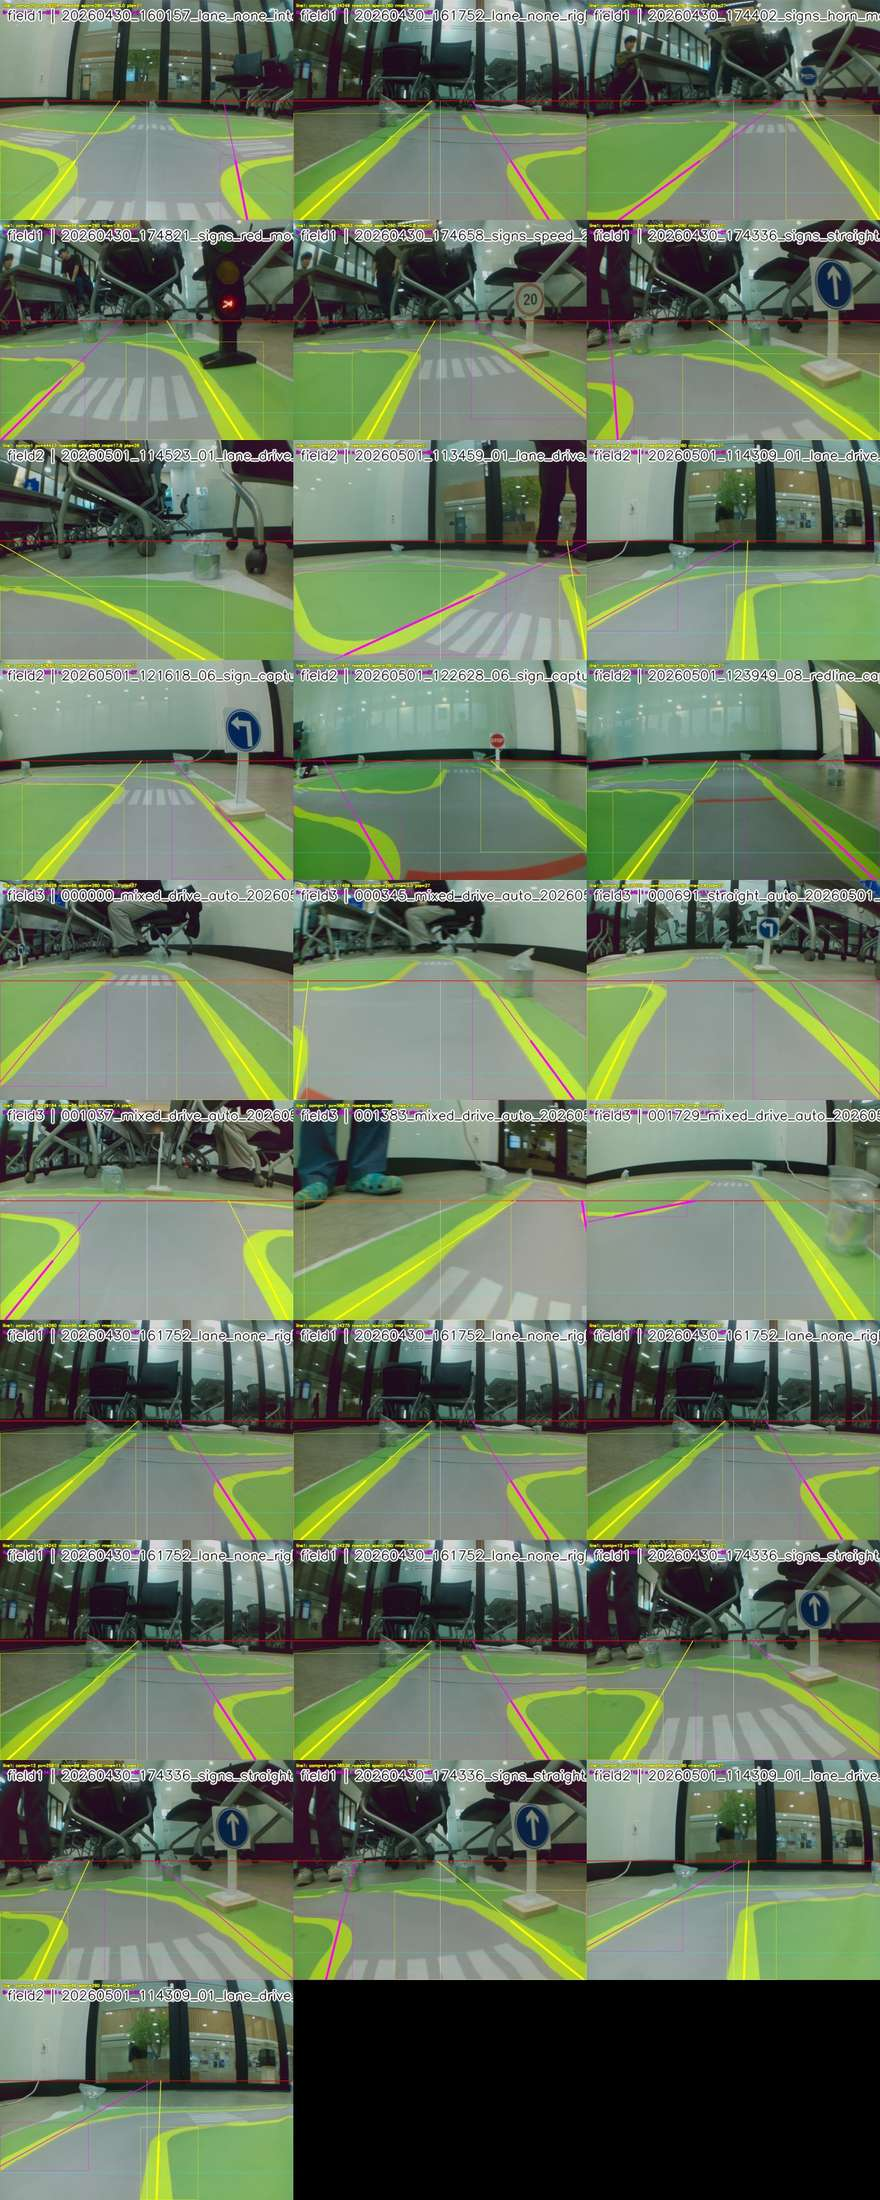

In [60]:
# 4. Local mask line fitting.
# 목적: yellow mask의 local component pixels에서 x = a*y + b 직선을 직접 fitting하고,
#       그 직선을 sample_y까지 연장해서 .lines.txt 후보를 만든다.

from IPython.display import display, Image
from pathlib import Path
import json
import math
import cv2
import numpy as np
import pandas as pd

if 'df' not in globals():
    raise RuntimeError('Run the setup/data-index cells first so df is available.')

# ---- Selected mask policy fallbacks ----
if 'SELECTED_HSV_LOWER' not in globals() or 'SELECTED_HSV_UPPER' not in globals():
    selected_hsv_path = REVIEW_ROOT / 'selected_hsv_policy_v1.json'
    selected_hsv_policy = json.loads(selected_hsv_path.read_text(encoding='utf-8'))
    SELECTED_HSV_POLICY_NAME = selected_hsv_policy['name']
    SELECTED_HSV_LOWER = np.array(selected_hsv_policy['lower'], dtype=np.uint8)
    SELECTED_HSV_UPPER = np.array(selected_hsv_policy['upper'], dtype=np.uint8)

if 'SELECTED_MORPH_POLICY' not in globals():
    selected_morph_path = REVIEW_ROOT / 'selected_morph_policy_v1.json'
    selected_morph_policy = json.loads(selected_morph_path.read_text(encoding='utf-8'))
    SELECTED_MORPH_POLICY_NAME = selected_morph_policy['name']
    SELECTED_MORPH_POLICY = [(op['op'], int(op['kernel'])) for op in selected_morph_policy['operations']]

if 'apply_morph_policy' not in globals():
    def apply_morph_policy(mask: np.ndarray, policy):
        out = mask.copy()
        for op, k in policy:
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (int(k), int(k)))
            if op == 'open':
                out = cv2.morphologyEx(out, cv2.MORPH_OPEN, kernel)
            elif op == 'close':
                out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, kernel)
            else:
                raise ValueError(f'unknown morph op: {op}')
        return out

if 'make_yellow_mask_full' not in globals():
    def make_yellow_mask_full(bgr: np.ndarray):
        mask = np.zeros(bgr.shape[:2], dtype=np.uint8)
        roi = bgr[CUT_HEIGHT:, :, :]
        hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
        roi_mask = cv2.inRange(hsv, SELECTED_HSV_LOWER, SELECTED_HSV_UPPER)
        roi_mask = apply_morph_policy(roi_mask, SELECTED_MORPH_POLICY)
        mask[CUT_HEIGHT:, :] = roi_mask
        return mask

# ---- Local-fit label policy experiment v1 ----
# 여기부터가 직접 조절할 수 있는 local-fit 라벨 정책의 default 값이다.
# 이 값들은 최종 확정값이 아니라, field3 raw에서 넓게 검증하기 위한 현재 기준점이다.

FIT_ROOT = REVIEW_ROOT / 'local_fit_v1'
FIT_ROOT.mkdir(parents=True, exist_ok=True)

# 3번에서 현재 가장 괜찮아 보였던 mask 정책.
# H는 넓게, S는 엄격하게, V는 낮게 둬서 어두운 노란선 방어와 노이즈 억제를 같이 노린다.
LOCAL_FIT_MASK_POLICY_NAME = 'h20_42_s140_v70'
LOCAL_FIT_HSV_LOWER = np.array([20, 140, 70], dtype=np.uint8)
LOCAL_FIT_HSV_UPPER = np.array([42, 255, 255], dtype=np.uint8)
LOCAL_FIT_MORPH_POLICY = [('open', 3), ('close', 3)]

# Local-fit extraction default parameters.
# 값을 바꿔 실험하려면 이 dict만 먼저 수정하고 셀을 다시 실행하면 된다.
LOCAL_FIT_DEFAULTS = {
    'local_fit_window_px': 260,      # component bottom에서 위로 볼 local window 높이
    'min_component_area': 500,       # 전체 component 노이즈 제거 기준
    'min_local_pixels': 180,         # local window 안 mask pixel 최소 개수
    'min_local_y_span': 45,          # y 방향 길이가 너무 짧으면 x=f(y) 라벨로 부적합
    'max_fit_rms_px': 55.0,          # 직선 fitting RMS가 크면 곡선/가로형 component로 reject
    'max_selected_lanes': 2,         # 한 이미지에서 최대 선택 line 수
    'duplicate_x_gap_px': 150,       # 같은 lane 중복 제거 기준
    'dup_compare_y_offset_from_bottom': 120,
    'row_center_y_step': 4,          # row-wise center 추출 간격
    'min_row_center_points': 10,     # fitting에 필요한 row-wise center 최소 개수
    'line_width_for_overlay': 7,
}

LOCAL_FIT_WINDOW_PX = int(LOCAL_FIT_DEFAULTS['local_fit_window_px'])
MIN_COMPONENT_AREA = int(LOCAL_FIT_DEFAULTS['min_component_area'])
MIN_LOCAL_PIXELS = int(LOCAL_FIT_DEFAULTS['min_local_pixels'])
MIN_LOCAL_Y_SPAN = int(LOCAL_FIT_DEFAULTS['min_local_y_span'])
MAX_FIT_RMS_PX = float(LOCAL_FIT_DEFAULTS['max_fit_rms_px'])
MAX_SELECTED_LANES = int(LOCAL_FIT_DEFAULTS['max_selected_lanes'])
DUPLICATE_X_GAP_PX = int(LOCAL_FIT_DEFAULTS['duplicate_x_gap_px'])
DUP_COMPARE_Y = RAW_H - 1 - int(LOCAL_FIT_DEFAULTS['dup_compare_y_offset_from_bottom'])
ROW_CENTER_Y_STEP = int(LOCAL_FIT_DEFAULTS['row_center_y_step'])
MIN_ROW_CENTER_POINTS = int(LOCAL_FIT_DEFAULTS['min_row_center_points'])
LINE_WIDTH_FOR_OVERLAY = int(LOCAL_FIT_DEFAULTS['line_width_for_overlay'])
FIT_RANKING_POLICY = 'line_quality_first_then_rms_span_pixels_bottom'

raw_df = df[df['split'] == 'raw'].copy().sort_values(['group', 'rel']).reset_index(drop=True)
SAMPLE_Y_LIST = list(range(RAW_H - 1, CUT_HEIGHT - 1, -20))


def make_local_fit_yellow_mask_full(bgr: np.ndarray):
    mask = np.zeros(bgr.shape[:2], dtype=np.uint8)
    roi = bgr[CUT_HEIGHT:, :, :]
    hsv = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    roi_mask = cv2.inRange(hsv, LOCAL_FIT_HSV_LOWER, LOCAL_FIT_HSV_UPPER)
    roi_mask = apply_morph_policy(roi_mask, LOCAL_FIT_MORPH_POLICY)
    mask[CUT_HEIGHT:, :] = roi_mask
    return mask

param_rows = [
    ('mask_hsv_lower', LOCAL_FIT_HSV_LOWER.tolist(), 'HSV lower bound for yellow mask'),
    ('mask_hsv_upper', LOCAL_FIT_HSV_UPPER.tolist(), 'HSV upper bound for yellow mask'),
    ('morph_policy', LOCAL_FIT_MORPH_POLICY, 'small noise remove/open + small gap close'),
    ('local_fit_window_px', LOCAL_FIT_WINDOW_PX, 'component bottom에서 위로 보는 local window 높이'),
    ('min_component_area', MIN_COMPONENT_AREA, '작은 노이즈 component 제거'),
    ('min_local_pixels', MIN_LOCAL_PIXELS, 'local window 안 fitting 근거 픽셀 최소 수'),
    ('min_local_y_span', MIN_LOCAL_Y_SPAN, 'x=f(y) 라벨로 쓸 y 방향 최소 길이'),
    ('max_fit_rms_px', MAX_FIT_RMS_PX, '직선 fitting 평균 오차 허용치'),
    ('row_center_y_step', ROW_CENTER_Y_STEP, 'row-wise center 추출 y 간격'),
    ('min_row_center_points', MIN_ROW_CENTER_POINTS, '직선 fitting에 필요한 중심점 최소 개수'),
    ('duplicate_x_gap_px', DUPLICATE_X_GAP_PX, '동일 lane 중복 제거 기준'),
    ('dup_compare_y', DUP_COMPARE_Y, '중복 판단용 y row'),
    ('max_selected_lanes', MAX_SELECTED_LANES, '이미지당 최대 선택 line 수'),
]
param_df = pd.DataFrame(param_rows, columns=['parameter', 'value', 'meaning'])
print('base HSV policy from section 3:', SELECTED_HSV_POLICY_NAME, SELECTED_HSV_LOWER.tolist(), SELECTED_HSV_UPPER.tolist())
print('base morph policy from section 3:', SELECTED_MORPH_POLICY_NAME, SELECTED_MORPH_POLICY)
print('local-fit experiment policy:', LOCAL_FIT_MASK_POLICY_NAME)
display(param_df)


def fit_line_x_as_function_of_y(xs: np.ndarray, ys: np.ndarray):
    # x = a*y + b. CLRKDNet/CULane label도 y row마다 x를 갖는 구조라 이 형태가 맞다.
    y = ys.astype(np.float32)
    x = xs.astype(np.float32)
    if len(x) < 2 or float(y.max() - y.min()) < 1e-6:
        return None
    a, b = np.polyfit(y, x, deg=1)
    pred = a * y + b
    rms = float(np.sqrt(np.mean((x - pred) ** 2)))
    return float(a), float(b), rms



def rowwise_center_points(xs: np.ndarray, ys: np.ndarray, y_step=4):
    # component local mask의 모든 픽셀을 fitting하지 않고,
    # y row별 mask x 중심점만 뽑아 중심선 후보를 만든다.
    if len(xs) == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    rows = []
    for y0 in range(int(ys.min()), int(ys.max()) + 1, int(y_step)):
        y1 = y0 + int(y_step)
        sel = (ys >= y0) & (ys < y1)
        if not np.any(sel):
            continue
        x_vals = xs[sel].astype(np.float32)
        y_vals = ys[sel].astype(np.float32)
        # 평균보다 median이 component 경계/두꺼운 mask에 덜 흔들린다.
        rows.append((float(np.median(x_vals)), float(np.median(y_vals))))
    if not rows:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    cx = np.array([r[0] for r in rows], dtype=np.float32)
    cy = np.array([r[1] for r in rows], dtype=np.float32)
    return cx, cy

def x_at_y(line, y):
    return line['a'] * float(y) + line['b']


def visible_segment_for_line(line, y_min=CUT_HEIGHT, y_max=RAW_H - 1):
    ys = np.arange(int(y_min), int(y_max) + 1, dtype=np.float32)
    xs = line['a'] * ys + line['b']
    inside = (xs >= 0) & (xs < RAW_W)
    if inside.sum() < 2:
        return None
    ys_inside = ys[inside]
    y0 = float(ys_inside.min())
    y1 = float(ys_inside.max())
    return (float(x_at_y(line, y0)), y0), (float(x_at_y(line, y1)), y1)


def sample_y_points_for_line(line):
    pts = []
    for y in SAMPLE_Y_LIST:
        x = x_at_y(line, y)
        if 0 <= x < RAW_W:
            pts.append((float(x), float(y)))
    return pts


def local_component_candidates(mask: np.ndarray):
    binary = (mask > 0).astype(np.uint8)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    candidates = []
    rejected = []

    for label_id in range(1, n_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        if area < MIN_COMPONENT_AREA:
            rejected.append({'label_id': label_id, 'reason': 'small_component_area', 'component_area': area})
            continue

        ys, xs = np.where(labels == label_id)
        y_min = int(ys.min())
        y_max = int(ys.max())
        x_min = int(xs.min())
        x_max = int(xs.max())

        local_y_min = max(CUT_HEIGHT, y_max - LOCAL_FIT_WINDOW_PX)
        local_mask = ys >= local_y_min
        local_xs = xs[local_mask]
        local_ys = ys[local_mask]
        local_pixels = int(len(local_xs))
        if local_pixels < MIN_LOCAL_PIXELS:
            rejected.append({
                'label_id': label_id,
                'reason': 'few_local_pixels',
                'component_area': area,
                'local_pixels': local_pixels,
                'bbox': (x_min, y_min, x_max, y_max),
            })
            continue

        local_y_span = int(local_ys.max() - local_ys.min())
        if local_y_span < MIN_LOCAL_Y_SPAN:
            rejected.append({
                'label_id': label_id,
                'reason': 'short_local_y_span',
                'component_area': area,
                'local_pixels': local_pixels,
                'local_y_span': local_y_span,
                'bbox': (x_min, y_min, x_max, y_max),
            })
            continue

        center_xs, center_ys = rowwise_center_points(local_xs, local_ys, y_step=ROW_CENTER_Y_STEP)
        row_center_count = int(len(center_xs))
        if row_center_count < MIN_ROW_CENTER_POINTS:
            rejected.append({
                'label_id': label_id,
                'reason': 'few_row_center_points',
                'component_area': area,
                'local_pixels': local_pixels,
                'local_y_span': local_y_span,
                'row_center_count': row_center_count,
                'bbox': (x_min, y_min, x_max, y_max),
            })
            continue

        fit = fit_line_x_as_function_of_y(center_xs, center_ys)
        if fit is None:
            rejected.append({'label_id': label_id, 'reason': 'fit_failed', 'component_area': area})
            continue
        a, b, rms = fit
        if rms > MAX_FIT_RMS_PX:
            rejected.append({
                'label_id': label_id,
                'reason': 'high_fit_rms',
                'component_area': area,
                'local_pixels': local_pixels,
                'local_y_span': local_y_span,
                'row_center_count': row_center_count,
                'fit_rms_px': rms,
                'bbox': (x_min, y_min, x_max, y_max),
            })
            continue

        line = {
            'label_id': label_id,
            'a': a,
            'b': b,
            'fit_rms_px': rms,
            'component_area': area,
            'local_pixels': local_pixels,
            'local_y_span': local_y_span,
            'row_center_count': row_center_count,
            'fit_input': 'rowwise_median_center_points',
            'x_min': x_min,
            'x_max': x_max,
            'y_min': y_min,
            'y_max': y_max,
            'local_y_min': int(local_y_min),
            'local_y_max': int(local_ys.max()),
            'local_centroid_x': float(local_xs.mean()),
            'local_centroid_y': float(local_ys.mean()),
            'x_at_dup_y': float(a * DUP_COMPARE_Y + b),
            'sample_point_count': 0,
            'sample_points_preview': '',
        }
        pts = sample_y_points_for_line(line)
        line['sample_point_count'] = len(pts)
        line['sample_points_preview'] = ' '.join(f'{x:.1f} {y:.0f}' for x, y in pts[:8])
        # line_quality는 선택 순위 확인용이다. 값이 클수록 직선 fitting이 깨끗하고,
        # local y-span/pixel 수가 충분하며, 아래쪽 주행 영역에도 닿아 있다.
        line['line_quality'] = float(
            (line['local_y_span'] / max(1.0, LOCAL_FIT_WINDOW_PX)) * 0.35
            + min(1.0, line['row_center_count'] / 60.0) * 0.25
            + min(1.0, line['local_pixels'] / 1200.0) * 0.15
            + max(0.0, 1.0 - line['fit_rms_px'] / max(1.0, MAX_FIT_RMS_PX)) * 0.20
            + min(1.0, max(0.0, line['y_max'] - CUT_HEIGHT) / max(1.0, RAW_H - 1 - CUT_HEIGHT)) * 0.05
        )
        if len(pts) < 4:
            rejected.append({
                'label_id': label_id,
                'reason': 'too_few_sample_y_points_after_extension',
                'component_area': area,
                'local_pixels': local_pixels,
                'fit_rms_px': rms,
                'sample_point_count': len(pts),
                'bbox': (x_min, y_min, x_max, y_max),
            })
            continue
        candidates.append(line)

    return candidates, rejected, labels, n_labels


def candidate_duplicate(candidate, selected):
    cx = candidate['x_at_dup_y']
    if not np.isfinite(cx) or cx < -RAW_W or cx > RAW_W * 2:
        cx = candidate['local_centroid_x']
    for prev in selected:
        px = prev['x_at_dup_y']
        if not np.isfinite(px) or px < -RAW_W or px > RAW_W * 2:
            px = prev['local_centroid_x']
        if abs(cx - px) < DUPLICATE_X_GAP_PX:
            return True
    return False


def select_local_lines(candidates):
    # 이전 버전은 y_max가 큰 component, 즉 가장 아래쪽에 닿은 component를 먼저 골랐다.
    # 그 방식은 바닥 근처의 이상한 노란 조각이 먼저 선택될 수 있었다.
    # 이번 버전은 line_quality를 우선한다.
    # 정렬 우선순위:
    # 1. line_quality 높음: fit RMS가 낮고, local y-span/pixels가 충분한 후보
    # 2. fit_rms_px 낮음: 직선 하나로 잘 설명되는 후보
    # 3. local_y_span 큼: x=f(y) 라벨로 쓸 세로 정보가 충분한 후보
    # 4. local_pixels 많음: 마스크 근거가 많은 후보
    # 5. y_max 큼: 마지막 tie-breaker로만 아래쪽 근접성을 사용
    ordered = sorted(
        candidates,
        key=lambda c: (
            c.get('line_quality', 0.0),
            -c['fit_rms_px'],
            c['local_y_span'],
            c['local_pixels'],
            c['y_max'],
        ),
        reverse=True,
    )
    selected = []
    duplicate_skipped = []
    for cand in ordered:
        if candidate_duplicate(cand, selected):
            duplicate_skipped.append(cand)
            continue
        selected.append(cand)
        if len(selected) >= MAX_SELECTED_LANES:
            break
    return selected, ordered, duplicate_skipped


def draw_local_fit_overlay(bgr, mask, selected, ordered, rejected_count):
    out = bgr.copy()
    tint = np.zeros_like(out)
    tint[:, :, 1] = (mask > 0).astype(np.uint8) * 180
    out = cv2.addWeighted(out, 0.84, tint, 0.16, 0)
    cv2.line(out, (0, CUT_HEIGHT), (RAW_W - 1, CUT_HEIGHT), (0, 0, 255), 2)
    cv2.line(out, (RAW_W // 2, CUT_HEIGHT), (RAW_W // 2, RAW_H - 1), (255, 255, 255), 1)
    cv2.line(out, (0, DUP_COMPARE_Y), (RAW_W - 1, DUP_COMPARE_Y), (255, 255, 0), 1)

    # 상위 후보 몇 개는 회색 얇은 선으로 보여준다.
    for cand in ordered[:6]:
        seg = visible_segment_for_line(cand)
        if seg is None:
            continue
        (x0, y0), (x1, y1) = seg
        cv2.line(out, (int(round(x0)), int(round(y0))), (int(round(x1)), int(round(y1))), (120, 120, 120), 1, cv2.LINE_AA)

    colors = [(0, 255, 255), (255, 0, 255)]
    for i, cand in enumerate(selected):
        color = colors[i % len(colors)]
        # local fit 구간은 굵게, 연장선은 얇게 그린다.
        y0 = cand['local_y_min']
        y1 = cand['local_y_max']
        x0 = x_at_y(cand, y0)
        x1 = x_at_y(cand, y1)
        if 0 <= x0 < RAW_W and 0 <= x1 < RAW_W:
            cv2.line(out, (int(round(x0)), int(round(y0))), (int(round(x1)), int(round(y1))), color, LINE_WIDTH_FOR_OVERLAY, cv2.LINE_AA)
        seg = visible_segment_for_line(cand)
        if seg is not None:
            (ex0, ey0), (ex1, ey1) = seg
            cv2.line(out, (int(round(ex0)), int(round(ey0))), (int(round(ex1)), int(round(ey1))), color, 2, cv2.LINE_AA)
        cv2.rectangle(out, (cand['x_min'], cand['y_min']), (cand['x_max'], cand['y_max']), color, 1)
        label = f"line{i+1}: comp={cand['label_id']} px={cand['local_pixels']} rows={cand.get('row_center_count', 0)} span={cand['local_y_span']} rms={cand['fit_rms_px']:.1f} pts={cand['sample_point_count']}"
        y_text = 30 + i * 30
        cv2.putText(out, label, (12, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(out, label, (12, y_text), cv2.FONT_HERSHEY_SIMPLEX, 0.58, color, 2, cv2.LINE_AA)

    if not selected:
        label = f"none: candidates={len(ordered)} rejected={rejected_count}"
        cv2.putText(out, label, (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.66, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(out, label, (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.66, (80, 80, 255), 2, cv2.LINE_AA)
    return out


def make_review_sheet(images, labels, out_path: Path, max_cols=3, thumb_w=420):
    thumbs = []
    for img, label in zip(images, labels):
        scale = thumb_w / img.shape[1]
        thumb = cv2.resize(img, (thumb_w, int(img.shape[0] * scale)), interpolation=cv2.INTER_AREA)
        cv2.putText(thumb, label[:52], (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (255, 255, 255), 3, cv2.LINE_AA)
        cv2.putText(thumb, label[:52], (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (0, 0, 0), 1, cv2.LINE_AA)
        thumbs.append(thumb)
    rows = []
    target_w = thumb_w * max_cols
    for i in range(0, len(thumbs), max_cols):
        row = thumbs[i:i + max_cols]
        max_h = max(t.shape[0] for t in row)
        padded = []
        for t in row:
            if t.shape[0] < max_h:
                pad = np.zeros((max_h - t.shape[0], t.shape[1], 3), dtype=np.uint8)
                t = np.vstack([t, pad])
            padded.append(t)
        row_img = np.hstack(padded)
        if row_img.shape[1] < target_w:
            pad = np.zeros((row_img.shape[0], target_w - row_img.shape[1], 3), dtype=np.uint8)
            row_img = np.hstack([row_img, pad])
        rows.append(row_img)
    sheet = np.vstack(rows)
    cv2.imwrite(str(out_path), sheet)
    return out_path


def select_even_rows(df_in: pd.DataFrame, per_group=6):
    rows = []
    for group in sorted(df_in['group'].unique()):
        gdf = df_in[df_in['group'] == group].sort_values('rel').reset_index(drop=True)
        if len(gdf) == 0:
            continue
        idxs = np.linspace(0, len(gdf) - 1, num=min(per_group, len(gdf)), dtype=int)
        rows.extend(gdf.iloc[idxs].to_dict('records'))
    return rows

review_rows = select_even_rows(raw_df, per_group=6)
TARGET_KEYS = [
    '20260430_174336',
    '000691_straight_auto',
    '20260430_160157',
    '20260430_161752',
    '20260501_114523',
    '20260501_114309',
    '001729_mixed_drive_auto',
]
seen = {r['rel'] for r in review_rows}
for _, row in raw_df.iterrows():
    rel = str(row['rel'])
    if any(key in rel for key in TARGET_KEYS) and rel not in seen:
        review_rows.append(row.to_dict())
        seen.add(rel)

frame_records = []
line_records = []
reject_records = []
overlays = []
overlay_labels = []

for sample_idx, row in enumerate(review_rows):
    bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
    if bgr is None:
        continue
    mask = make_local_fit_yellow_mask_full(bgr)
    candidates, rejected, labels_img, n_labels = local_component_candidates(mask)
    selected, ordered, duplicate_skipped = select_local_lines(candidates)

    frame_records.append({
        'sample_idx': sample_idx,
        'group': row['group'],
        'rel': row['rel'],
        'component_count': int(n_labels - 1),
        'candidate_count': len(candidates),
        'selected_count': len(selected),
        'duplicate_skipped_count': len(duplicate_skipped),
        'rejected_count': len(rejected),
        'best_local_pixels': ordered[0]['local_pixels'] if ordered else np.nan,
        'best_fit_rms_px': ordered[0]['fit_rms_px'] if ordered else np.nan,
    })

    for lane_idx, cand in enumerate(selected):
        rec = dict(cand)
        rec.update({
            'sample_idx': sample_idx,
            'group': row['group'],
            'rel': row['rel'],
            'lane_idx': lane_idx,
        })
        line_records.append(rec)

    for item in rejected[:30]:
        r = dict(item)
        r.update({'sample_idx': sample_idx, 'group': row['group'], 'rel': row['rel']})
        reject_records.append(r)

    overlay = draw_local_fit_overlay(bgr, mask, selected, ordered, len(rejected))
    overlays.append(overlay)
    overlay_labels.append(f"{row['group']} | {Path(row['rel']).name}")

frame_df = pd.DataFrame(frame_records)
line_df = pd.DataFrame(line_records)
reject_df = pd.DataFrame(reject_records)

frame_csv = FIT_ROOT / 'frame_summary.csv'
line_csv = FIT_ROOT / 'selected_lines.csv'
reject_csv = FIT_ROOT / 'reject_sample.csv'
frame_df.to_csv(frame_csv, index=False, encoding='utf-8-sig')
line_df.to_csv(line_csv, index=False, encoding='utf-8-sig')
reject_df.to_csv(reject_csv, index=False, encoding='utf-8-sig')
print('saved:', frame_csv)
print('saved:', line_csv)
print('saved:', reject_csv)

print('\nFrame summary')
display(frame_df.round(3))

print('\nSelected local-fit lines')
if len(line_df):
    show_cols = [
        'group', 'rel', 'lane_idx', 'label_id', 'component_area', 'local_pixels', 'local_y_span', 'row_center_count',
        'fit_rms_px', 'line_quality', 'x_at_dup_y', 'sample_point_count', 'sample_points_preview'
    ]
    display(line_df[show_cols].round(3))
else:
    print('No selected lines in this review sample.')

print('\nTarget frames')
target_frame_df = frame_df[frame_df['rel'].astype(str).apply(lambda s: any(key in s for key in TARGET_KEYS))]
display(target_frame_df.round(3))
if len(line_df):
    target_line_df = line_df[line_df['rel'].astype(str).apply(lambda s: any(key in s for key in TARGET_KEYS))]
    display(target_line_df[[
        'group', 'rel', 'lane_idx', 'label_id', 'local_pixels', 'local_y_span', 'row_center_count', 'fit_rms_px', 'line_quality',
        'x_at_dup_y', 'sample_point_count', 'sample_points_preview'
    ]].round(3))

params = {
    'method': 'local_mask_line_fit_v1',
    'base_hsv_policy_from_section3': {'name': SELECTED_HSV_POLICY_NAME, 'lower': SELECTED_HSV_LOWER.tolist(), 'upper': SELECTED_HSV_UPPER.tolist()},
    'base_morph_policy_from_section3': {'name': SELECTED_MORPH_POLICY_NAME, 'operations': [{'op': op, 'kernel': int(k)} for op, k in SELECTED_MORPH_POLICY]},
    'local_fit_hsv_policy': {'name': LOCAL_FIT_MASK_POLICY_NAME, 'lower': LOCAL_FIT_HSV_LOWER.tolist(), 'upper': LOCAL_FIT_HSV_UPPER.tolist()},
    'local_fit_morph_policy': {'operations': [{'op': op, 'kernel': int(k)} for op, k in LOCAL_FIT_MORPH_POLICY]},
    'geometry': {
        'raw_width': RAW_W,
        'raw_height': RAW_H,
        'cut_height': CUT_HEIGHT,
        'sample_y': SAMPLE_Y_LIST,
    },
    'parameters': {
        'local_fit_window_px': LOCAL_FIT_WINDOW_PX,
        'min_component_area': MIN_COMPONENT_AREA,
        'min_local_pixels': MIN_LOCAL_PIXELS,
        'min_local_y_span': MIN_LOCAL_Y_SPAN,
        'max_fit_rms_px': MAX_FIT_RMS_PX,
        'max_selected_lanes': MAX_SELECTED_LANES,
        'row_center_y_step': ROW_CENTER_Y_STEP,
        'min_row_center_points': MIN_ROW_CENTER_POINTS,
        'duplicate_x_gap_px': DUPLICATE_X_GAP_PX,
        'dup_compare_y': DUP_COMPARE_Y,
    },
    'status': 'review_only_not_final_policy',
}
params_path = FIT_ROOT / 'params.json'
params_path.write_text(json.dumps(params, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', params_path)

if overlays:
    overlay_path = FIT_ROOT / 'overlay.jpg'
    make_review_sheet(overlays, overlay_labels, overlay_path, max_cols=3, thumb_w=420)
    print('saved overlay:', overlay_path)
    display(Image(filename=str(overlay_path)))


### 4-1. Local-fit 정책 실험: window 길이와 row 대표 x 선택 방식을 비교한다

4번 본 셀은 local-fit 라벨러의 기본 구조를 정의했다. 여기서는 그 구조를 고정한 채, 실제로 어떤 정책이 우리 주행 목적에 더 맞는지 비교한다.

비교할 축은 두 가지다.

1. **local window 길이**
   - `120`, `160`, `200`, `260` px를 비교한다.
   - 짧은 window는 곡선에서 접선 방향을 더 잘 잡을 수 있지만, 너무 짧으면 sample_y로 연장했을 때 불안정할 수 있다.
   - 긴 window는 직선 구간에서 안정적이지만, 곡선/가로형 component에서는 fitting RMS가 커질 수 있다.

2. **row-wise x 대표값 선택 방식**
   - `center`: 각 y row에서 mask x의 중앙값을 사용한다. 기존 방식이다.
   - `inner_edge`: 화면 중앙 쪽 edge를 사용한다. 왼쪽 component는 오른쪽 edge, 오른쪽 component는 왼쪽 edge를 쓴다.
   - `outer_edge`: 화면 바깥쪽 edge를 사용한다. 비교용이다.

edge는 노이즈에 민감한 `min/max` 대신 `10%/90% quantile`을 쓴다. 즉 완전한 경계 픽셀이 아니라, 안정적인 내부 edge를 보는 방식이다.

이 셀의 목표는 최종 dataset을 만들기 전, **곡선 주행에서 어떤 local 직선 근사가 가장 자연스러운지** 눈으로 판단하는 것이다. 결과는 `local_fit_policy_experiment_v1/`에 저장된다.


policy experiment knobs: {'window_options_px': [120, 160, 200, 260], 'row_rep_modes': ['center', 'inner_edge', 'outer_edge'], 'display_policy_names': ['center_w260', 'center_w160', 'inner_edge_w160', 'inner_edge_w120', 'outer_edge_w160'], 'min_component_area': 500, 'min_local_pixels': 180, 'min_local_y_span': 45, 'max_fit_rms_px': 55.0}


,name,row_mode,window_px
0,center_w120,center,120
1,center_w160,center,160
2,center_w200,center,200
3,center_w260,center,260
4,inner_edge_w120,inner_edge,120
5,inner_edge_w160,inner_edge,160
6,inner_edge_w200,inner_edge,200
7,inner_edge_w260,inner_edge,260
8,outer_edge_w120,outer_edge,120
9,outer_edge_w160,outer_edge,160


field3 raw total: 1730
experiment samples: 75


,sample_tag,rel
0,field3_order_00,field3\field_drive\000000_mixed_drive_auto_202...
1,field3_order_01,field3\field_drive\000036_mixed_drive_auto_202...
2,field3_order_02,field3\field_drive\000073_mixed_drive_auto_202...
3,field3_order_03,field3\field_drive\000110_mixed_drive_auto_202...
4,field3_order_04,field3\field_drive\000147_mixed_drive_auto_202...
...,...,...
70,target_001328_mixed_drive_00,field3\field_drive\001328_mixed_drive_auto_202...
71,target_001047_mixed_drive_00,field3\field_drive\001047_mixed_drive_auto_202...
72,target_001501_mixed_drive_00,field3\field_drive\001501_mixed_drive_auto_202...
73,target_001383_mixed_drive_00,field3\field_drive\001383_mixed_drive_auto_202...


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\policy_summary.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\policy_selected_lines.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\policy_reject_sample.csv

Policy score table


,policy,row_mode,window_px,frames,selected0,selected1,selected2,mean_selected,median_best_rms,p90_best_rms,median_best_span,median_best_quality,zero_rate
4,inner_edge_w120,inner_edge,120,75,1,18,56,1.733,0.931,14.192,120.0,0.876,0.013
0,center_w120,center,120,75,3,20,52,1.653,1.153,6.246,120.0,0.875,0.040
5,inner_edge_w160,inner_edge,160,75,3,16,56,1.707,1.214,12.751,160.0,0.916,0.040
6,inner_edge_w200,inner_edge,200,75,3,17,55,1.693,1.651,13.931,200.0,0.956,0.040
1,center_w160,center,160,75,3,21,51,1.640,2.136,12.138,160.0,0.913,0.040
7,inner_edge_w260,inner_edge,260,75,3,17,55,1.693,2.507,27.544,260.0,0.991,0.040
9,outer_edge_w160,outer_edge,160,75,3,24,48,1.600,3.085,20.449,160.0,0.910,0.040
8,outer_edge_w120,outer_edge,120,75,4,24,47,1.573,1.427,11.807,120.0,0.874,0.053
2,center_w200,center,200,75,4,22,49,1.600,3.002,17.033,200.0,0.950,0.053
3,center_w260,center,260,75,4,22,49,1.600,3.879,23.908,260.0,0.986,0.053



Weak selected lines by policy


,policy,row_mode,window_px,weak_line_count
1,center_w160,center,160,13
9,outer_edge_w160,outer_edge,160,13
3,center_w260,center,260,12
0,center_w120,center,120,11
2,center_w200,center,200,11
7,inner_edge_w260,inner_edge,260,11
10,outer_edge_w200,outer_edge,200,11
11,outer_edge_w260,outer_edge,260,11
8,outer_edge_w120,outer_edge,120,9
5,inner_edge_w160,inner_edge,160,7


,policy,sample_tag,rel,lane_idx,local_y_span,fit_rms_px,line_quality,sample_point_count,sample_points_preview
1264,center_w120,field3_random_15,field3\field_drive\000346_mixed_drive_auto_202...,1,62,29.567,0.496,4,53.3 511 168.4 491 283.6 471 398.7 451
947,center_w120,field3_order_47,field3\field_drive\001729_mixed_drive_auto_202...,1,70,37.441,0.500,5,40.5 531 142.2 511 244.0 491 345.8 471 447.5 451
417,center_w120,field3_order_20,field3\field_drive\000735_left_curve_auto_2026...,1,51,2.177,0.516,6,0.8 551 5.1 531 9.5 511 13.8 491 18.2 471 22.5...
301,center_w120,field3_order_14,field3\field_drive\000515_straight_auto_202605...,1,95,45.299,0.571,7,28.5 571 107.9 551 187.4 531 266.9 511 346.3 4...
1421,center_w120,target_001383_mixed_drive_00,field3\field_drive\001383_mixed_drive_auto_202...,1,63,2.943,0.586,7,1293.9 571 1290.9 551 1287.9 531 1284.8 511 12...
...,...,...,...,...,...,...,...,...,...
251,outer_edge_w260,field3_order_11,field3\field_drive\000404_mixed_drive_auto_202...,1,140,34.389,0.577,7,52.7 571 109.2 551 165.7 531 222.2 511 278.7 4...
227,outer_edge_w260,field3_order_10,field3\field_drive\000367_mixed_drive_auto_202...,1,140,34.333,0.577,7,52.3 571 109.1 551 165.8 531 222.5 511 279.3 4...
844,outer_edge_w260,field3_order_41,field3\field_drive\001508_mixed_drive_auto_202...,0,105,7.843,0.585,5,3.9 531 29.6 511 55.3 491 80.9 471 106.6 451
799,outer_edge_w260,field3_order_39,field3\field_drive\001434_mixed_drive_auto_202...,1,120,8.923,0.620,5,18.9 531 42.7 511 66.5 491 90.3 471 114.1 451


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w260_000_023.jpg


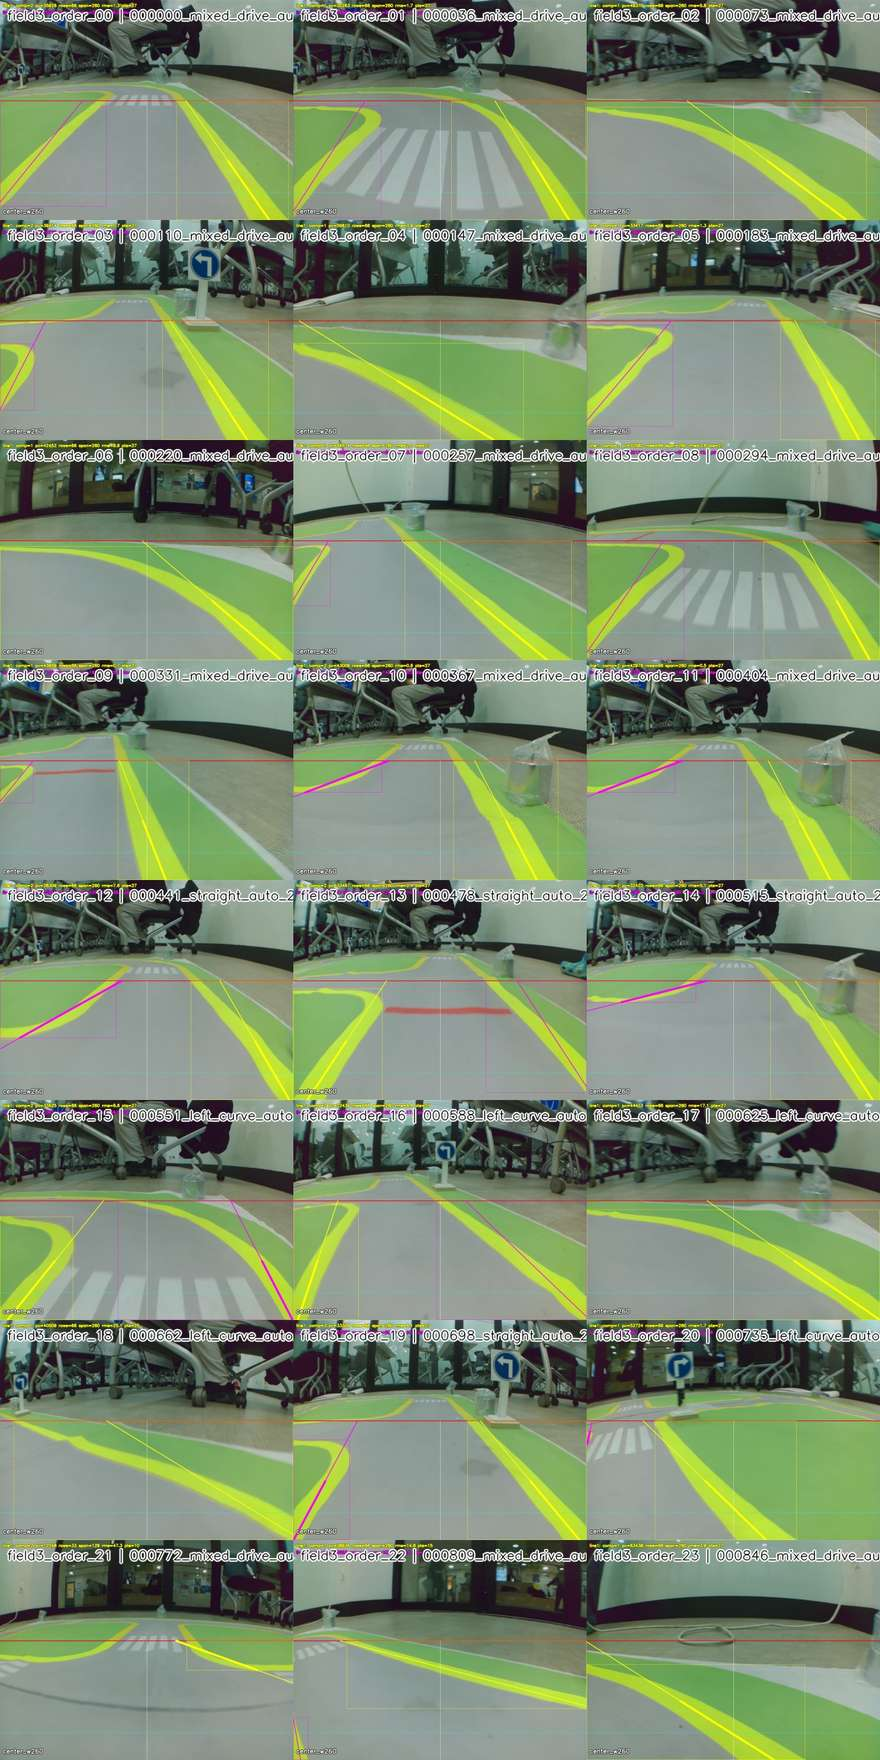

saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w260_024_047.jpg


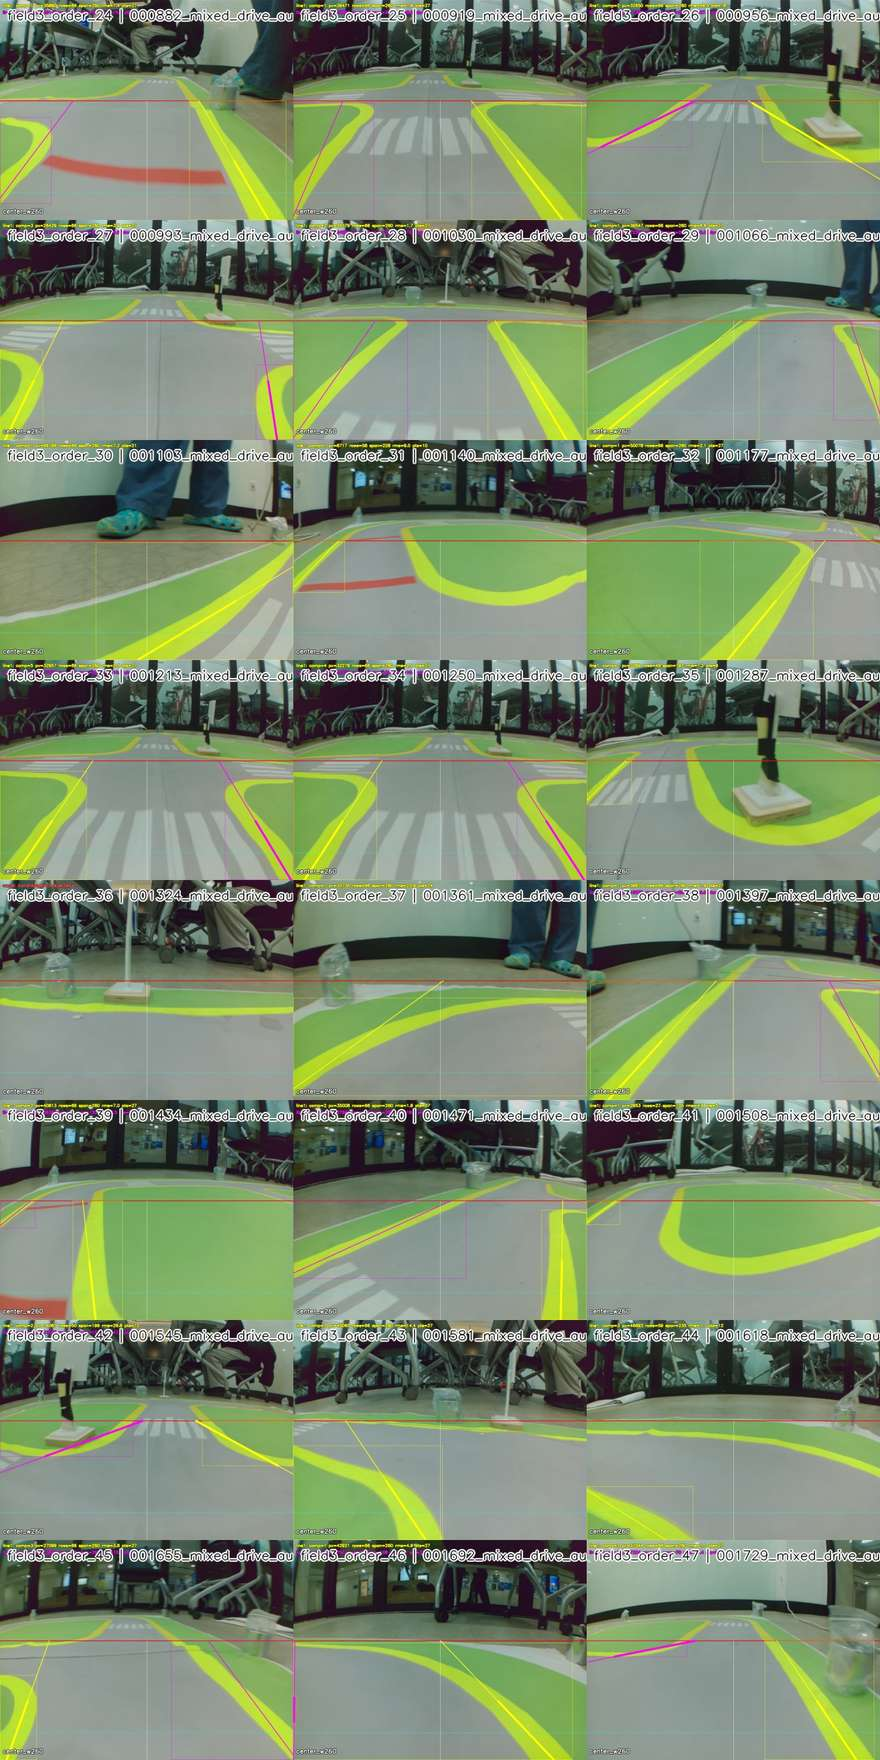

saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w260_048_071.jpg


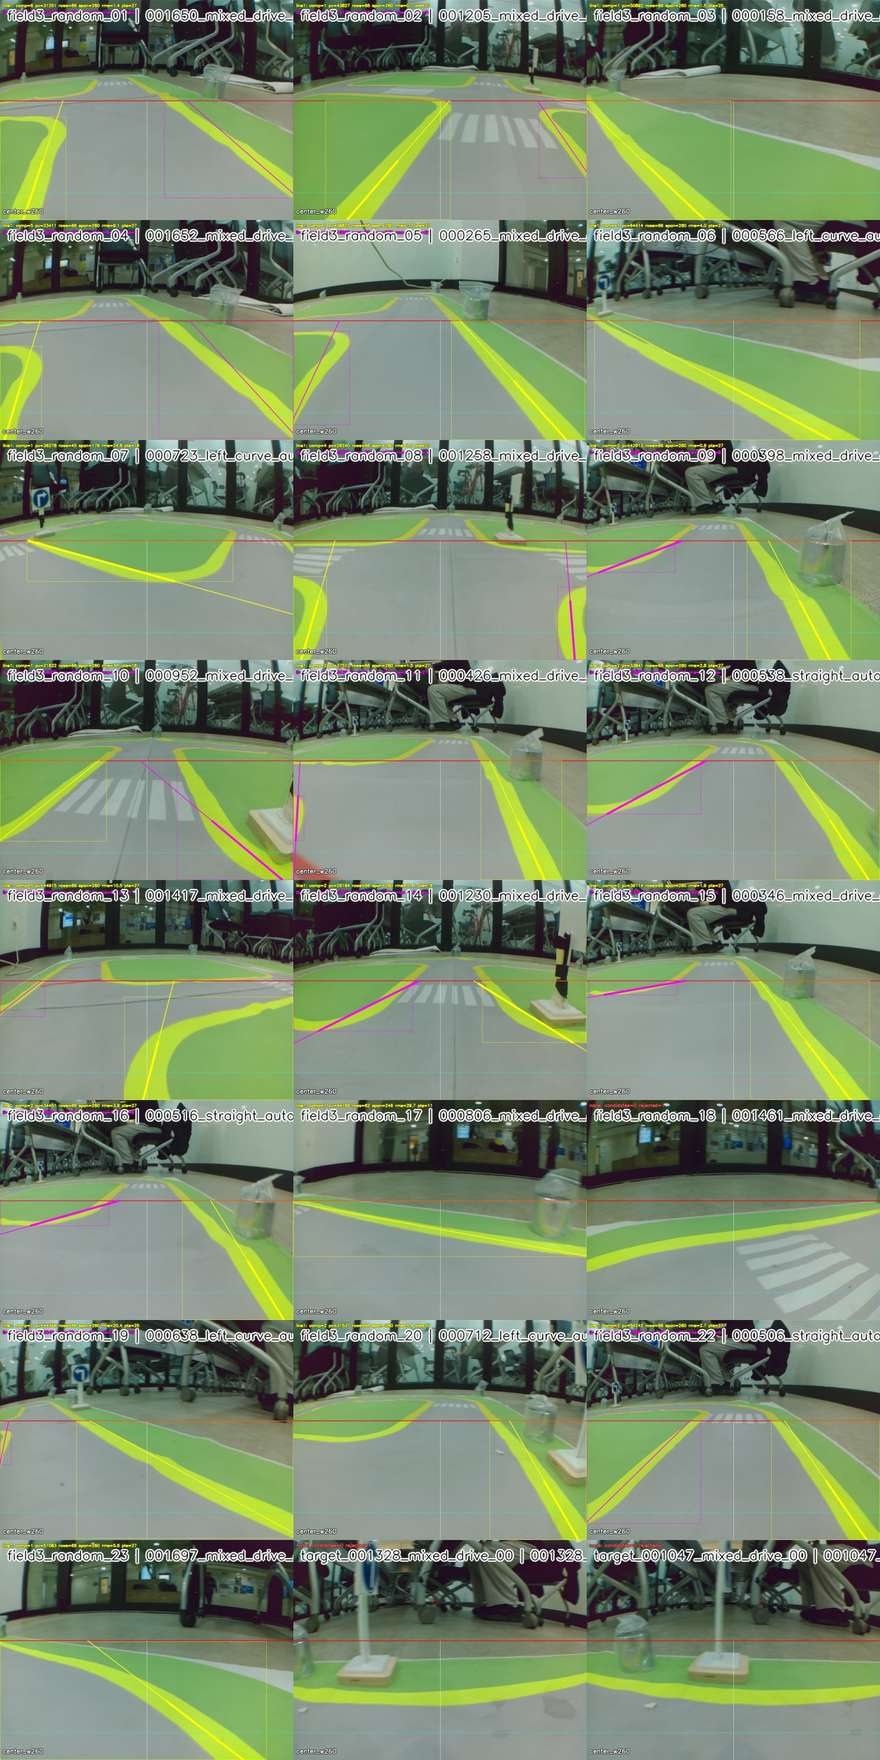

saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w260_072_074.jpg


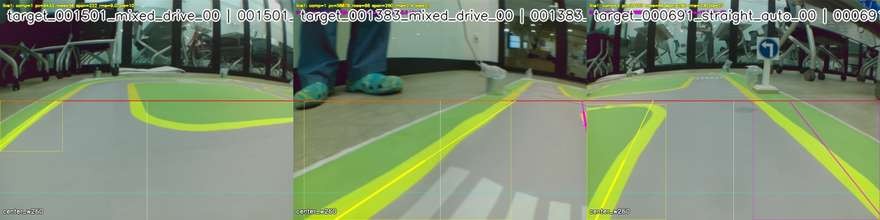

saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w160_000_023.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w160_024_047.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w160_048_071.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_center_w160_072_074.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_inner_edge_w160_000_023.jpg


...

saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_outer_edge_w160_000_023.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_outer_edge_w160_024_047.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_outer_edge_w160_048_071.jpg


saved overlay: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\overlay_outer_edge_w160_072_074.jpg


saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_policy_experiment_v1\policy_experiment_params.json


In [61]:
# 4-1. Local-fit policy experiment: window length x row representative mode.
# 이 셀은 기존 4번 local-fit 구조를 재사용하되, window 길이와 row 대표 x 선택 방식을 비교한다.

from IPython.display import display, Image
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import json

required_names = [
    'make_local_fit_yellow_mask_full',
    'fit_line_x_as_function_of_y',
    'sample_y_points_for_line',
    'visible_segment_for_line',
    'x_at_y',
    'draw_local_fit_overlay',
    'make_review_sheet',
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f'Run section 4 main code cell first. Missing: {missing}')

POLICY_EXP_ROOT = REVIEW_ROOT / 'local_fit_policy_experiment_v1'
POLICY_EXP_ROOT.mkdir(parents=True, exist_ok=True)

# ---- Experiment knobs ----
# 여기만 바꾸면 비교할 정책을 바꿀 수 있다.
WINDOW_OPTIONS_PX = [120, 160, 200, 260]
ROW_REP_MODES = ['center', 'inner_edge', 'outer_edge']
DISPLAY_POLICY_NAMES = ['center_w260', 'center_w160', 'inner_edge_w160', 'inner_edge_w120', 'outer_edge_w160']

POLICY_MIN_COMPONENT_AREA = MIN_COMPONENT_AREA
POLICY_MIN_LOCAL_PIXELS = MIN_LOCAL_PIXELS
POLICY_MIN_LOCAL_Y_SPAN = MIN_LOCAL_Y_SPAN
POLICY_MAX_FIT_RMS_PX = MAX_FIT_RMS_PX
POLICY_MIN_ROW_CENTER_POINTS = MIN_ROW_CENTER_POINTS
POLICY_MAX_SELECTED_LANES = MAX_SELECTED_LANES
POLICY_DUPLICATE_X_GAP_PX = DUPLICATE_X_GAP_PX
POLICY_ROW_CENTER_Y_STEP = ROW_CENTER_Y_STEP
POLICY_MIN_SAMPLE_POINTS = 4

FIELD3_SAMPLE_COUNT = 48
RANDOM_SAMPLE_COUNT = 24
rng = np.random.default_rng(4211)

print('policy experiment knobs:', {
    'window_options_px': WINDOW_OPTIONS_PX,
    'row_rep_modes': ROW_REP_MODES,
    'display_policy_names': DISPLAY_POLICY_NAMES,
    'min_component_area': POLICY_MIN_COMPONENT_AREA,
    'min_local_pixels': POLICY_MIN_LOCAL_PIXELS,
    'min_local_y_span': POLICY_MIN_LOCAL_Y_SPAN,
    'max_fit_rms_px': POLICY_MAX_FIT_RMS_PX,
})


def make_policy_name(row_mode, window_px):
    return f'{row_mode}_w{int(window_px)}'


POLICIES = [
    {'name': make_policy_name(mode, window_px), 'row_mode': mode, 'window_px': int(window_px)}
    for mode in ROW_REP_MODES
    for window_px in WINDOW_OPTIONS_PX
]
policy_df = pd.DataFrame(POLICIES)
display(policy_df)


# ---- Sample selection ----
raw_df = df[df['split'] == 'raw'].copy().reset_index(drop=True)
field3_raw_df = raw_df[raw_df['group'] == 'field3'].copy().sort_values('rel').reset_index(drop=True)
if len(field3_raw_df) == 0:
    raise RuntimeError('No field3 raw rows found. Run indexing cells first.')

sample_rows = []
used_rel = set()

def add_row(row, tag):
    rel = str(row['rel'])
    if rel in used_rel:
        return False
    rr = row.copy()
    rr['sample_tag'] = tag
    sample_rows.append(rr)
    used_rel.add(rel)
    return True

# 시간 순서 spread: 자동 캡처 데이터이므로 띄엄띄엄 보는 것이 중요하다.
idxs = np.linspace(0, len(field3_raw_df) - 1, num=min(FIELD3_SAMPLE_COUNT, len(field3_raw_df)), dtype=int)
for j, idx in enumerate(idxs):
    add_row(field3_raw_df.iloc[int(idx)], f'field3_order_{j:02d}')

# 랜덤 샘플.
if len(field3_raw_df):
    ridxs = rng.choice(len(field3_raw_df), size=min(RANDOM_SAMPLE_COUNT, len(field3_raw_df)), replace=False)
    for j, idx in enumerate(ridxs):
        add_row(field3_raw_df.iloc[int(idx)], f'field3_random_{j:02d}')

# 곡선/가로형 문제 샘플은 반드시 포함한다.
TARGET_KEYS = [
    '001508_mixed_drive',
    '001328_mixed_drive',
    '001047_mixed_drive',
    '001461_mixed_drive',
    '001501_mixed_drive',
    '001383_mixed_drive',
    '000691_straight_auto',
]
for key in TARGET_KEYS:
    hit = field3_raw_df[field3_raw_df['rel'].astype(str).str.contains(key, regex=False)]
    for j, (_, row) in enumerate(hit.head(4).iterrows()):
        add_row(row, f'target_{key}_{j:02d}')

exp_df = pd.DataFrame(sample_rows).reset_index(drop=True)
print('field3 raw total:', len(field3_raw_df))
print('experiment samples:', len(exp_df))
display(exp_df[['sample_tag', 'rel']].head(120))


# ---- Row representative and candidate generation ----
def row_representative_points(xs: np.ndarray, ys: np.ndarray, row_mode: str, y_step: int = 4):
    """Return representative x for each y band.

    center: row median x.
    inner_edge: component가 화면 왼쪽이면 q90, 오른쪽이면 q10. 즉 화면 중앙 쪽 edge.
    outer_edge: inner_edge의 반대쪽.
    """
    if len(xs) == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)

    component_center_x = float(np.median(xs))
    is_left_component = component_center_x < (RAW_W / 2)
    rows = []
    for y0 in range(int(ys.min()), int(ys.max()) + 1, int(y_step)):
        y1 = y0 + int(y_step)
        sel = (ys >= y0) & (ys < y1)
        if not np.any(sel):
            continue
        x_vals = xs[sel].astype(np.float32)
        y_vals = ys[sel].astype(np.float32)

        if row_mode == 'center':
            x_rep = float(np.quantile(x_vals, 0.50))
        elif row_mode == 'inner_edge':
            q = 0.90 if is_left_component else 0.10
            x_rep = float(np.quantile(x_vals, q))
        elif row_mode == 'outer_edge':
            q = 0.10 if is_left_component else 0.90
            x_rep = float(np.quantile(x_vals, q))
        else:
            raise ValueError(f'unknown row_mode: {row_mode}')
        rows.append((x_rep, float(np.median(y_vals))))

    if not rows:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    cx = np.array([r[0] for r in rows], dtype=np.float32)
    cy = np.array([r[1] for r in rows], dtype=np.float32)
    return cx, cy


def line_quality_for_policy(line, window_px):
    return float(
        (line['local_y_span'] / max(1.0, float(window_px))) * 0.35
        + min(1.0, line['row_center_count'] / 60.0) * 0.25
        + min(1.0, line['local_pixels'] / 1200.0) * 0.15
        + max(0.0, 1.0 - line['fit_rms_px'] / max(1.0, POLICY_MAX_FIT_RMS_PX)) * 0.20
        + min(1.0, max(0.0, line['y_max'] - CUT_HEIGHT) / max(1.0, RAW_H - 1 - CUT_HEIGHT)) * 0.05
    )


def policy_component_candidates(mask: np.ndarray, policy: dict):
    row_mode = policy['row_mode']
    window_px = int(policy['window_px'])
    policy_name = policy['name']

    binary = (mask > 0).astype(np.uint8)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)
    candidates = []
    rejected = []

    for label_id in range(1, n_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        if area < POLICY_MIN_COMPONENT_AREA:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'small_component_area', 'component_area': area})
            continue

        ys, xs = np.where(labels == label_id)
        y_min = int(ys.min())
        y_max = int(ys.max())
        x_min = int(xs.min())
        x_max = int(xs.max())

        local_y_min = max(CUT_HEIGHT, y_max - window_px)
        local_mask = ys >= local_y_min
        local_xs = xs[local_mask].astype(np.float32)
        local_ys = ys[local_mask].astype(np.float32)
        local_pixels = int(len(local_xs))
        if local_pixels < POLICY_MIN_LOCAL_PIXELS:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'few_local_pixels', 'component_area': area, 'local_pixels': local_pixels})
            continue

        local_y_span = int(local_ys.max() - local_ys.min())
        if local_y_span < POLICY_MIN_LOCAL_Y_SPAN:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'short_local_y_span', 'component_area': area, 'local_pixels': local_pixels, 'local_y_span': local_y_span})
            continue

        center_xs, center_ys = row_representative_points(local_xs, local_ys, row_mode=row_mode, y_step=POLICY_ROW_CENTER_Y_STEP)
        row_center_count = int(len(center_xs))
        if row_center_count < POLICY_MIN_ROW_CENTER_POINTS:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'few_row_rep_points', 'component_area': area, 'local_y_span': local_y_span, 'row_center_count': row_center_count})
            continue

        fit = fit_line_x_as_function_of_y(center_xs, center_ys)
        if fit is None:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'fit_failed', 'component_area': area})
            continue
        a, b, rms = fit
        if rms > POLICY_MAX_FIT_RMS_PX:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'high_fit_rms', 'component_area': area, 'local_pixels': local_pixels, 'local_y_span': local_y_span, 'row_center_count': row_center_count, 'fit_rms_px': rms})
            continue

        line = {
            'label_id': label_id,
            'policy': policy_name,
            'row_mode': row_mode,
            'window_px': int(window_px),
            'a': float(a),
            'b': float(b),
            'fit_rms_px': float(rms),
            'component_area': int(area),
            'local_pixels': int(local_pixels),
            'local_y_span': int(local_y_span),
            'row_center_count': int(row_center_count),
            'fit_input': f'{row_mode}_quantile_row_rep',
            'x_min': int(x_min),
            'x_max': int(x_max),
            'y_min': int(y_min),
            'y_max': int(y_max),
            'local_y_min': int(local_ys.min()),
            'local_y_max': int(local_ys.max()),
            'local_centroid_x': float(local_xs.mean()),
            'local_centroid_y': float(local_ys.mean()),
            'x_at_dup_y': float(a * DUP_COMPARE_Y + b),
            'sample_point_count': 0,
            'sample_points_preview': '',
        }
        pts = sample_y_points_for_line(line)
        line['sample_point_count'] = len(pts)
        line['sample_points_preview'] = ' '.join(f'{x:.1f} {y:.0f}' for x, y in pts[:8])
        line['line_quality'] = line_quality_for_policy(line, window_px)
        if len(pts) < POLICY_MIN_SAMPLE_POINTS:
            rejected.append({'label_id': label_id, 'policy': policy_name, 'reason': 'too_few_sample_y_points_after_extension', 'component_area': area, 'sample_point_count': len(pts), 'fit_rms_px': rms})
            continue
        candidates.append(line)

    return candidates, rejected, labels, n_labels


def policy_candidate_duplicate(candidate, selected):
    cx = candidate['x_at_dup_y']
    if not np.isfinite(cx) or cx < -RAW_W or cx > RAW_W * 2:
        cx = candidate['local_centroid_x']
    for prev in selected:
        px = prev['x_at_dup_y']
        if not np.isfinite(px) or px < -RAW_W or px > RAW_W * 2:
            px = prev['local_centroid_x']
        if abs(cx - px) < POLICY_DUPLICATE_X_GAP_PX:
            return True
    return False


def select_policy_lines(candidates):
    ordered = sorted(
        candidates,
        key=lambda c: (
            c.get('line_quality', 0.0),
            -c['fit_rms_px'],
            c['local_y_span'],
            c['local_pixels'],
            c['y_max'],
        ),
        reverse=True,
    )
    selected = []
    duplicate_skipped = []
    for cand in ordered:
        if policy_candidate_duplicate(cand, selected):
            duplicate_skipped.append(cand)
            continue
        selected.append(cand)
        if len(selected) >= POLICY_MAX_SELECTED_LANES:
            break
    return selected, ordered, duplicate_skipped


# ---- Run experiment ----
summary_records = []
line_records = []
reject_records = []
policy_overlays = {p['name']: [] for p in POLICIES if p['name'] in DISPLAY_POLICY_NAMES}
policy_labels = {p['name']: [] for p in POLICIES if p['name'] in DISPLAY_POLICY_NAMES}

for sample_idx, row in exp_df.iterrows():
    bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
    if bgr is None:
        continue
    mask = make_local_fit_yellow_mask_full(bgr)

    for policy in POLICIES:
        candidates, rejected, labels_img, n_labels = policy_component_candidates(mask, policy)
        selected, ordered, duplicate_skipped = select_policy_lines(candidates)
        best = ordered[0] if ordered else {}

        summary_records.append({
            'sample_idx': sample_idx,
            'sample_tag': row['sample_tag'],
            'rel': row['rel'],
            'policy': policy['name'],
            'row_mode': policy['row_mode'],
            'window_px': policy['window_px'],
            'component_count': int(n_labels - 1),
            'candidate_count': len(candidates),
            'selected_count': len(selected),
            'duplicate_skipped_count': len(duplicate_skipped),
            'rejected_count': len(rejected),
            'best_local_pixels': best.get('local_pixels', np.nan),
            'best_local_y_span': best.get('local_y_span', np.nan),
            'best_fit_rms_px': best.get('fit_rms_px', np.nan),
            'best_line_quality': best.get('line_quality', np.nan),
        })

        for lane_idx, cand in enumerate(selected):
            rec = dict(cand)
            rec.update({
                'sample_idx': sample_idx,
                'sample_tag': row['sample_tag'],
                'rel': row['rel'],
                'lane_idx': lane_idx,
            })
            line_records.append(rec)

        for item in rejected[:20]:
            rr = dict(item)
            rr.update({'sample_idx': sample_idx, 'sample_tag': row['sample_tag'], 'rel': row['rel']})
            reject_records.append(rr)

        if policy['name'] in DISPLAY_POLICY_NAMES:
            overlay = draw_local_fit_overlay(bgr, mask, selected, ordered, len(rejected))
            cv2.putText(overlay, policy['name'], (12, RAW_H - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 5, cv2.LINE_AA)
            cv2.putText(overlay, policy['name'], (12, RAW_H - 30), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2, cv2.LINE_AA)
            policy_overlays[policy['name']].append(overlay)
            policy_labels[policy['name']].append(f"{row['sample_tag']} | {Path(str(row['rel'])).name}")

summary_df = pd.DataFrame(summary_records)
line_df = pd.DataFrame(line_records)
reject_df = pd.DataFrame(reject_records)

summary_csv = POLICY_EXP_ROOT / 'policy_summary.csv'
line_csv = POLICY_EXP_ROOT / 'policy_selected_lines.csv'
reject_csv = POLICY_EXP_ROOT / 'policy_reject_sample.csv'
summary_df.to_csv(summary_csv, index=False, encoding='utf-8-sig')
line_df.to_csv(line_csv, index=False, encoding='utf-8-sig')
reject_df.to_csv(reject_csv, index=False, encoding='utf-8-sig')
print('saved:', summary_csv)
print('saved:', line_csv)
print('saved:', reject_csv)

print('\nPolicy score table')
policy_score = summary_df.groupby(['policy', 'row_mode', 'window_px']).agg(
    frames=('rel', 'count'),
    selected0=('selected_count', lambda s: int((s == 0).sum())),
    selected1=('selected_count', lambda s: int((s == 1).sum())),
    selected2=('selected_count', lambda s: int((s == 2).sum())),
    mean_selected=('selected_count', 'mean'),
    median_best_rms=('best_fit_rms_px', 'median'),
    p90_best_rms=('best_fit_rms_px', lambda s: s.dropna().quantile(0.90) if len(s.dropna()) else np.nan),
    median_best_span=('best_local_y_span', 'median'),
    median_best_quality=('best_line_quality', 'median'),
).reset_index()
policy_score['zero_rate'] = policy_score['selected0'] / policy_score['frames']
policy_score = policy_score.sort_values(['selected0', 'median_best_rms', 'median_best_quality'], ascending=[True, True, False]).round(3)
display(policy_score)

print('\nWeak selected lines by policy')
if len(line_df):
    weak = line_df[(line_df['line_quality'] < 0.45) | (line_df['fit_rms_px'] > 40) | (line_df['sample_point_count'] < 8)].copy()
    weak_summary = weak.groupby(['policy', 'row_mode', 'window_px']).size().reset_index(name='weak_line_count').sort_values('weak_line_count', ascending=False)
    display(weak_summary)
    weak_cols = ['policy', 'sample_tag', 'rel', 'lane_idx', 'local_y_span', 'fit_rms_px', 'line_quality', 'sample_point_count', 'sample_points_preview']
    display(weak[weak_cols].sort_values(['policy', 'line_quality', 'fit_rms_px']).head(120).round(3))

# Save overlay sheets for selected policies.
for policy_name in DISPLAY_POLICY_NAMES:
    images = policy_overlays.get(policy_name, [])
    labels = policy_labels.get(policy_name, [])
    if not images:
        continue
    for start in range(0, len(images), 24):
        end = min(start + 24, len(images))
        out_path = POLICY_EXP_ROOT / f'overlay_{policy_name}_{start:03d}_{end - 1:03d}.jpg'
        make_review_sheet(images[start:end], labels[start:end], out_path, max_cols=3, thumb_w=420)
        print('saved overlay:', out_path)
        display(Image(filename=str(out_path)))

params = {
    'method': 'local_fit_policy_experiment_v1',
    'mask_policy': {
        'name': LOCAL_FIT_MASK_POLICY_NAME,
        'lower': LOCAL_FIT_HSV_LOWER.tolist(),
        'upper': LOCAL_FIT_HSV_UPPER.tolist(),
        'morph': [{'op': op, 'kernel': int(k)} for op, k in LOCAL_FIT_MORPH_POLICY],
    },
    'window_options_px': WINDOW_OPTIONS_PX,
    'row_rep_modes': ROW_REP_MODES,
    'display_policy_names': DISPLAY_POLICY_NAMES,
    'thresholds': {
        'min_component_area': POLICY_MIN_COMPONENT_AREA,
        'min_local_pixels': POLICY_MIN_LOCAL_PIXELS,
        'min_local_y_span': POLICY_MIN_LOCAL_Y_SPAN,
        'max_fit_rms_px': POLICY_MAX_FIT_RMS_PX,
        'min_row_center_points': POLICY_MIN_ROW_CENTER_POINTS,
        'max_selected_lanes': POLICY_MAX_SELECTED_LANES,
        'duplicate_x_gap_px': POLICY_DUPLICATE_X_GAP_PX,
        'row_center_y_step': POLICY_ROW_CENTER_Y_STEP,
        'min_sample_points': POLICY_MIN_SAMPLE_POINTS,
    },
    'sample_count': int(len(exp_df)),
    'target_keys': TARGET_KEYS,
}
params_path = POLICY_EXP_ROOT / 'policy_experiment_params.json'
params_path.write_text(json.dumps(params, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', params_path)


### 4-2. Field3 전체 주행 데이터를 시간순 overlay 영상으로 검수한다

4-1 실험 결과, 실제 주행용 local label 후보로는 `inner_edge_w120`이 가장 좋아 보였다. 이제 이 정책을 field3 raw 주행 데이터 전체에 적용하고, 시간순 overlay 영상으로 확인한다.

이 셀의 목적은 파라미터를 더 sweep하는 것이 아니라, **현재 후보 정책이 실제 연속 주행 프레임에서 어떻게 흔들리는지** 보는 것이다.

확인할 질문은 다음이다.

1. 직선 구간에서 line이 프레임마다 안정적으로 이어지는가?
2. 모퉁이 곡선에서 주행 방향을 따라가도록 line이 서서히 회전하는가?
3. 노란선이 있는데 `selected_count=0`으로 빠지는 프레임이 어디인가?
4. 이상한 먼 component나 배경 노이즈를 line으로 잡는 프레임이 있는가?
5. `selected_count=1`인 상황이 실제로 한쪽 lane만 보이는 상황인지, 아니면 누락인지 구분 가능한가?

저장물은 `local_fit_field3_video_inner_edge_w120/` 폴더에 생성된다.

- `field3_inner_edge_w120_overlay.mp4`: 전체 overlay 영상
- `field3_video_summary.csv`: 프레임별 선택 개수와 품질 지표
- `field3_video_selected_lines.csv`: 선택된 line 좌표/품질 정보
- `field3_issue_frames.csv`: 검토가 필요한 프레임 목록
- `issue_frames/`: 문제 후보 프레임 overlay 이미지


field3 frames: 1730
video policy: {'name': 'inner_edge_w120', 'row_mode': 'inner_edge', 'window_px': 120}
output: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_field3_video_inner_edge_w120
processed 250/1730
processed 500/1730
processed 750/1730
processed 1000/1730
processed 1250/1730
processed 1500/1730
saved video: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_field3_video_inner_edge_w120\field3_inner_edge_w120_overlay.mp4
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_field3_video_inner_edge_w120\field3_video_summary.csv
saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebu

selected_count,0,1,2
policy,,,
inner_edge_w120,10,336,1384



Issue reason counts


,reason,count
0,selected1,336
1,weak_line,102
2,many_candidates,72
3,has_high_fit_rms_reject,13
4,selected0,10


,frame_idx,rel,issue_reasons,selected_count,candidate_count,rejected_count,weak_line_count,best_fit_rms_px,best_line_quality
0,70,field3\field_drive\000070_mixed_drive_auto_202...,selected1,1,1,1,0,1.063645,0.875299
1,71,field3\field_drive\000071_mixed_drive_auto_202...,selected1,1,1,0,0,0.810372,0.876220
2,72,field3\field_drive\000072_mixed_drive_auto_202...,selected1,1,1,0,0,1.160818,0.874946
3,73,field3\field_drive\000073_mixed_drive_auto_202...,selected1,1,1,0,0,2.811686,0.868942
4,74,field3\field_drive\000074_mixed_drive_auto_202...,selected1,1,1,0,0,3.745045,0.865548
...,...,...,...,...,...,...,...,...,...
75,242,field3\field_drive\000242_mixed_drive_auto_202...,selected1,1,1,0,0,0.738912,0.876480
76,243,field3\field_drive\000243_mixed_drive_auto_202...,selected1,1,1,0,0,0.956309,0.875689
77,244,field3\field_drive\000244_mixed_drive_auto_202...,selected1,1,1,0,0,2.091926,0.871560
78,245,field3\field_drive\000245_mixed_drive_auto_202...,selected1,1,1,0,0,2.706591,0.869325



Quality summary


,frames,mean_selected,selected0,selected1,selected2,weak_line_frames,median_best_rms,p90_best_rms,median_best_quality
0,1730,1.794,10,336,1384,102,0.831,4.309,0.876


saved sample sheet: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_field3_video_inner_edge_w120\field3_periodic_sample_sheet.jpg


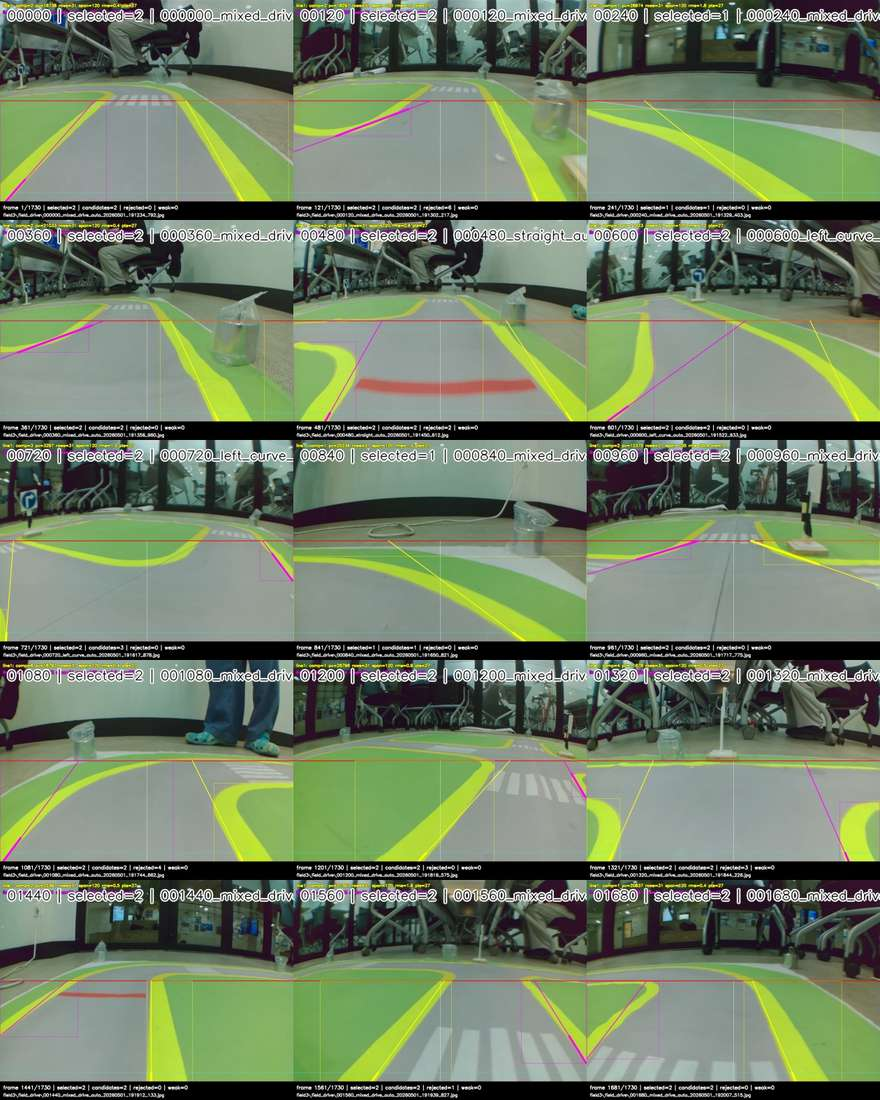

saved: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\12_clrkdnet_supervised_rebuild\review_outputs\02_label_policy_rebuild\local_fit_field3_video_inner_edge_w120\field3_video_review_params.json


In [62]:
# 4-2. Build a time-ordered field3 overlay video using the selected driving-local policy.
# Policy under review: inner_edge_w120.

from IPython.display import display, Video, Image
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import json

required_names = [
    'make_local_fit_yellow_mask_full',
    'policy_component_candidates',
    'select_policy_lines',
    'draw_local_fit_overlay',
    'make_review_sheet',
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise RuntimeError(f'Run section 4 and 4-1 cells first. Missing: {missing}')

VIDEO_POLICY = {'name': 'inner_edge_w120', 'row_mode': 'inner_edge', 'window_px': 120}
VIDEO_ROOT = REVIEW_ROOT / 'local_fit_field3_video_inner_edge_w120'
ISSUE_ROOT = VIDEO_ROOT / 'issue_frames'
SAMPLE_ROOT = VIDEO_ROOT / 'sample_frames'
VIDEO_ROOT.mkdir(parents=True, exist_ok=True)
ISSUE_ROOT.mkdir(parents=True, exist_ok=True)
SAMPLE_ROOT.mkdir(parents=True, exist_ok=True)

# Video/output options.
VIDEO_FPS = 12
VIDEO_WIDTH = 960
SAVE_ISSUE_FRAMES = True
SAVE_PERIODIC_SAMPLE_FRAMES = True
PERIODIC_SAMPLE_EVERY = 120
MAX_ISSUE_FRAMES_TO_SAVE = 240

# Weak-line thresholds for review. These do not reject labels yet; they only mark frames for inspection.
WEAK_LINE_QUALITY_TH = 0.45
WEAK_FIT_RMS_TH = 40.0
WEAK_SAMPLE_POINTS_TH = 8

raw_df = df[df['split'] == 'raw'].copy().reset_index(drop=True)
field3_all_df = raw_df[raw_df['group'] == 'field3'].copy().sort_values('rel').reset_index(drop=True)
if len(field3_all_df) == 0:
    raise RuntimeError('No field3 raw rows found. Run indexing cells first.')

print('field3 frames:', len(field3_all_df))
print('video policy:', VIDEO_POLICY)
print('output:', VIDEO_ROOT)


def resize_for_video(bgr, width=960):
    scale = width / bgr.shape[1]
    h = int(round(bgr.shape[0] * scale))
    return cv2.resize(bgr, (width, h), interpolation=cv2.INTER_AREA)


def annotate_frame_status(overlay, idx, total, row, selected, ordered, rejected):
    out = overlay.copy()
    weak_count = 0
    for cand in selected:
        if (
            cand.get('line_quality', 1.0) < WEAK_LINE_QUALITY_TH
            or cand.get('fit_rms_px', 0.0) > WEAK_FIT_RMS_TH
            or cand.get('sample_point_count', 99) < WEAK_SAMPLE_POINTS_TH
        ):
            weak_count += 1
    status = f"frame {idx+1}/{total} | selected={len(selected)} | candidates={len(ordered)} | rejected={len(rejected)} | weak={weak_count}"
    rel_text = str(row['rel'])[-88:]
    cv2.rectangle(out, (0, RAW_H - 82), (RAW_W - 1, RAW_H - 1), (0, 0, 0), -1)
    cv2.putText(out, status, (14, RAW_H - 48), cv2.FONT_HERSHEY_SIMPLEX, 0.72, (255, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(out, rel_text, (14, RAW_H - 16), cv2.FONT_HERSHEY_SIMPLEX, 0.62, (220, 220, 220), 2, cv2.LINE_AA)
    return out, weak_count


def frame_issue_reason(selected, ordered, rejected, weak_count):
    reasons = []
    if len(selected) == 0:
        reasons.append('selected0')
    elif len(selected) == 1:
        reasons.append('selected1')
    if weak_count > 0:
        reasons.append('weak_line')
    if any(r.get('reason') == 'high_fit_rms' for r in rejected):
        reasons.append('has_high_fit_rms_reject')
    if len(ordered) >= 3:
        reasons.append('many_candidates')
    return reasons


summary_records = []
line_records = []
issue_records = []
sample_images = []
sample_labels = []
issue_saved_count = 0
video_writer = None
video_path = VIDEO_ROOT / 'field3_inner_edge_w120_overlay.mp4'

try:
    for idx, row in field3_all_df.iterrows():
        bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
        if bgr is None:
            summary_records.append({'frame_idx': idx, 'rel': row['rel'], 'status': 'read_failed'})
            continue

        mask = make_local_fit_yellow_mask_full(bgr)
        candidates, rejected, labels_img, n_labels = policy_component_candidates(mask, VIDEO_POLICY)
        selected, ordered, duplicate_skipped = select_policy_lines(candidates)
        overlay = draw_local_fit_overlay(bgr, mask, selected, ordered, len(rejected))
        overlay, weak_count = annotate_frame_status(overlay, idx, len(field3_all_df), row, selected, ordered, rejected)

        best = ordered[0] if ordered else {}
        reasons = frame_issue_reason(selected, ordered, rejected, weak_count)
        summary_records.append({
            'frame_idx': idx,
            'group': row['group'],
            'rel': row['rel'],
            'policy': VIDEO_POLICY['name'],
            'component_count': int(n_labels - 1),
            'candidate_count': len(candidates),
            'selected_count': len(selected),
            'duplicate_skipped_count': len(duplicate_skipped),
            'rejected_count': len(rejected),
            'weak_line_count': weak_count,
            'issue_reasons': ','.join(reasons),
            'best_local_pixels': best.get('local_pixels', np.nan),
            'best_local_y_span': best.get('local_y_span', np.nan),
            'best_fit_rms_px': best.get('fit_rms_px', np.nan),
            'best_line_quality': best.get('line_quality', np.nan),
            'status': 'ok',
        })

        for lane_idx, cand in enumerate(selected):
            rec = dict(cand)
            rec.update({
                'frame_idx': idx,
                'group': row['group'],
                'rel': row['rel'],
                'lane_idx': lane_idx,
            })
            line_records.append(rec)

        if reasons:
            issue_records.append({
                'frame_idx': idx,
                'rel': row['rel'],
                'issue_reasons': ','.join(reasons),
                'selected_count': len(selected),
                'candidate_count': len(candidates),
                'rejected_count': len(rejected),
                'weak_line_count': weak_count,
                'best_fit_rms_px': best.get('fit_rms_px', np.nan),
                'best_line_quality': best.get('line_quality', np.nan),
            })
            if SAVE_ISSUE_FRAMES and issue_saved_count < MAX_ISSUE_FRAMES_TO_SAVE:
                out_name = f"issue_{idx:05d}_{'_'.join(reasons)}.jpg"
                cv2.imwrite(str(ISSUE_ROOT / out_name), overlay)
                issue_saved_count += 1

        if SAVE_PERIODIC_SAMPLE_FRAMES and (idx % PERIODIC_SAMPLE_EVERY == 0):
            out_name = f'sample_{idx:05d}.jpg'
            cv2.imwrite(str(SAMPLE_ROOT / out_name), overlay)
            sample_images.append(overlay)
            sample_labels.append(f"{idx:05d} | selected={len(selected)} | {Path(str(row['rel'])).name}")

        video_frame = resize_for_video(overlay, VIDEO_WIDTH)
        if video_writer is None:
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            video_writer = cv2.VideoWriter(str(video_path), fourcc, VIDEO_FPS, (video_frame.shape[1], video_frame.shape[0]))
            if not video_writer.isOpened():
                raise RuntimeError(f'Could not open VideoWriter for {video_path}')
        video_writer.write(video_frame)

        if (idx + 1) % 250 == 0:
            print(f'processed {idx + 1}/{len(field3_all_df)}')
finally:
    if video_writer is not None:
        video_writer.release()

summary_df = pd.DataFrame(summary_records)
line_df = pd.DataFrame(line_records)
issue_df = pd.DataFrame(issue_records)

summary_csv = VIDEO_ROOT / 'field3_video_summary.csv'
line_csv = VIDEO_ROOT / 'field3_video_selected_lines.csv'
issue_csv = VIDEO_ROOT / 'field3_issue_frames.csv'
summary_df.to_csv(summary_csv, index=False, encoding='utf-8-sig')
line_df.to_csv(line_csv, index=False, encoding='utf-8-sig')
issue_df.to_csv(issue_csv, index=False, encoding='utf-8-sig')

print('saved video:', video_path)
print('saved:', summary_csv)
print('saved:', line_csv)
print('saved:', issue_csv)
print('saved issue frames:', issue_saved_count, '->', ISSUE_ROOT)

print('\nSelected-count summary')
display(summary_df[summary_df['status'] == 'ok'].pivot_table(index='policy', columns='selected_count', values='rel', aggfunc='count', fill_value=0))

print('\nIssue reason counts')
if len(issue_df):
    reason_counts = issue_df['issue_reasons'].str.get_dummies(sep=',').sum().sort_values(ascending=False).reset_index()
    reason_counts.columns = ['reason', 'count']
    display(reason_counts)
    display(issue_df.head(80))
else:
    print('No issue frames by current review rules.')

print('\nQuality summary')
ok = summary_df[summary_df['status'] == 'ok'].copy()
quality_summary = pd.DataFrame([{
    'frames': int(len(ok)),
    'mean_selected': ok['selected_count'].mean(),
    'selected0': int((ok['selected_count'] == 0).sum()),
    'selected1': int((ok['selected_count'] == 1).sum()),
    'selected2': int((ok['selected_count'] == 2).sum()),
    'weak_line_frames': int((ok['weak_line_count'] > 0).sum()),
    'median_best_rms': ok['best_fit_rms_px'].median(),
    'p90_best_rms': ok['best_fit_rms_px'].dropna().quantile(0.90) if len(ok['best_fit_rms_px'].dropna()) else np.nan,
    'median_best_quality': ok['best_line_quality'].median(),
}]).round(3)
display(quality_summary)

if sample_images:
    sample_sheet = VIDEO_ROOT / 'field3_periodic_sample_sheet.jpg'
    make_review_sheet(sample_images, sample_labels, sample_sheet, max_cols=3, thumb_w=420)
    print('saved sample sheet:', sample_sheet)
    display(Image(filename=str(sample_sheet)))

params = {
    'method': 'field3_full_video_review_inner_edge_w120',
    'policy': VIDEO_POLICY,
    'mask_policy': {
        'name': LOCAL_FIT_MASK_POLICY_NAME,
        'lower': LOCAL_FIT_HSV_LOWER.tolist(),
        'upper': LOCAL_FIT_HSV_UPPER.tolist(),
        'morph': [{'op': op, 'kernel': int(k)} for op, k in LOCAL_FIT_MORPH_POLICY],
    },
    'review_thresholds': {
        'weak_line_quality_th': WEAK_LINE_QUALITY_TH,
        'weak_fit_rms_th': WEAK_FIT_RMS_TH,
        'weak_sample_points_th': WEAK_SAMPLE_POINTS_TH,
    },
    'video': {
        'path': str(video_path),
        'fps': VIDEO_FPS,
        'width': VIDEO_WIDTH,
    },
    'field3_frame_count': int(len(field3_all_df)),
}
params_path = VIDEO_ROOT / 'field3_video_review_params.json'
params_path.write_text(json.dumps(params, ensure_ascii=False, indent=2), encoding='utf-8')
print('saved:', params_path)

# Notebook inline video preview. If the file is large, open it from the output folder instead.
display(Video(str(video_path), embed=False, width=960))


## 5. 품질 게이트와 검수 정책: hard case와 불량 라벨을 구분하기

이 단계는 모델 성능에 매우 중요하다. 어려운 곡선/교차로를 무작정 reject하면 모델이 그 상황을 배울 수 없고, 반대로 잘못된 라벨을 넣으면 모델이 엉뚱한 선을 배운다.

정해야 할 질문이다.

- 정말 확실한 불량 라벨은 어떤 규칙으로 자동 reject할 것인가?
- 곡선, 교차로, 한쪽 선만 보이는 장면은 hard case로 train에 남길 것인가?
- 자동 reject와 수동 blacklist를 어떻게 기록할 것인가?
- review overlay는 몇 장을 보고, 어떤 기준으로 pass/fail을 판단할 것인가?

이전 정리에서 지적된 문제는 “자동 reject 후 사람이 다시 살린 기준이 문서/노트북에 충분히 남지 않았다”는 점이다. 이번에는 reject/recover 기준을 코드와 마크다운에 같이 남기는 것을 목표로 한다.

## 6. CULane 형식으로 저장하기: 공식 dataloader가 읽을 수 있는가

GT 정책이 정해지면, 결과를 공식 CULane 구조로 저장해야 한다.

필요한 산출물은 다음과 같다.

| 산출물 | 역할 |
|---|---|
| 이미지 파일 | 학습 입력 원본 |
| `.lines.txt` | 핵심 lane GT. 한 줄이 한 lane polyline |
| mask png | segmentation auxiliary loss용 label |
| `list/train_gt.txt` | train 이미지, mask, lane 존재 여부 목록 |
| `list/val.txt` | validation 이미지 목록 |
| `list/test.txt` | test/eval 이미지 목록 |
| `list/test_split/*.txt` | CULane metric 코드가 기대하는 split 파일 |
| build summary | 입력 수, usable/reject 수, 정책 파라미터 기록 |
| validation summary | 파일 존재, 라벨 형식, 좌표 범위 검사 결과 |

여기서 형식 검증과 의미 검증은 다르다. 파일이 다 있어도, lane 좌표가 실제 노란선을 잘 따라가지 않으면 학습 품질은 낮다.

## 7. 학습 config에서 공식과 다르게 바꿀 수 있는 것

데이터셋이 준비된 뒤에는 공식 `ResNet18_CULane.py`를 최소한으로 patch한다.

거의 공식 그대로 둘 것:

- model 구조: ResNet18 backbone, Aggregator, CLRHead
- `num_points=72`
- `max_lanes=4`
- loss 종류와 기본 가중치
- 공식 augmentation 흐름
- 공식 `get_lanes()` 후처리 구조

우리 도메인 때문에 바꿀 수 있는 것:

- `ori_img_w`, `ori_img_h`
- `cut_height`, `sample_y`
- `dataset_path`
- `batch_size`, `epochs`, `lr`
- augmentation 강도
- `conf_threshold`, `nms_thres`, `nms_topk`
- pretrained 출발점: `ResNet18_CULane.pth`, 이전 best, 또는 scratch 여부

Teacher/KD는 바로 넣지 않는다. 먼저 supervised fine-tuning이 학습/추론 분포 일치 상태에서 제대로 작동하는지 확인한 뒤 판단한다.

## 8. 평가와 runtime 검증: 학습 성공과 실제 주행 가능성을 분리해서 보기

마지막으로 평가도 층을 나눠야 한다.

| 평가 | 목적 |
|---|---|
| CULane metric | pseudo-GT 기준으로 학습이 되었는지 확인 |
| holdout overlay | metric이 놓치는 시각적 품질 확인 |
| 공식 `get_lanes()` 재현 | PyTorch inference가 공식 후처리를 그대로 쓰는지 확인 |
| ONNX parity | PyTorch raw output과 ONNX raw output이 같은지 확인 |
| preprocessing parity | 학습 입력과 runtime 입력의 BGR/scale/crop/resize가 같은지 확인 |
| Pi latency | 실제 보드에서 주기적으로 돌릴 수 있는지 확인 |
| sequence replay | 연속 프레임에서 lane이 흔들리지 않는지 확인 |

이전 실험에서 가장 큰 교훈은, parity check가 “PyTorch와 ONNX 수치가 같다”만 보면 부족하다는 것이다. 반드시 **학습 dataloader가 모델에 넣는 텐서와 runtime이 모델에 넣는 텐서가 같은 분포인지** 확인해야 한다.

## 9. 이 노트북에서 바로 이어서 채울 순서

이제 다음 코드셀은 아래 순서로 추가한다.

1. `y >= cut_height` ROI 안에서 노란 픽셀의 HSV 분포를 본다.
2. HSV 범위 후보를 한 번에 확정하지 않고, 샘플 이미지에 마스크 overlay를 그려 비교한다.
3. 마스크에서 component를 뽑되, component의 면적/높이/y-span/x-span 통계를 먼저 본다.
4. component를 lane polyline으로 바꿔 `.lines.txt` 형태의 좌표를 시각화한다.
5. 그 결과를 보고 reject rule과 hard-case 유지 기준을 정한다.

각 단계마다 “값을 왜 그렇게 정했는지”를 마크다운으로 남긴다. 이 노트북의 목적은 빠르게 끝내는 게 아니라, 나중에 봤을 때 GT 생성 정책을 다시 설명할 수 있게 만드는 것이다.